# SISTEM PAKAR UNTUK DIAGNOSIS BERAT BADAN LAHIR RENDAH MENGGUNAKAN INTERVAL TYPE 2 FUZZY DAN DEMPSTER SHAFER
**Nama  : Afif Imam Rahadi**  
**Nim   : L0122006**

Dosen Pembimbing 1 : Prof. Dr. Wiharto, S.T., M.Kom.  
Dosen Pembimbing 2 : Dr. Umi Salamah, S.Si., M.Kom.

## TAHAP 1: Preprocessing

### 1.1 Import Library

In [1]:
import os
import pandas as pd
import numpy as np
import re
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from IPython.display import display
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text, _tree
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split 
from sklearn.metrics import (classification_report, confusion_matrix, 
                            ConfusionMatrixDisplay, roc_auc_score)
import math
from matplotlib.lines import Line2D
from collections import Counter

### 1.2 Import File

In [2]:
# Import File awal yang akan  masuk ke tahapan preprocessing
nama_file = 'D:\\Skirpsi\\dataset\\03OtakatikGabunganRill.xlsx' 

df = pd.read_excel(nama_file)

#  Lihat data awal
display(df.head())

,BB Lahir,ibu_Nama,ibu_Sumber Pembiayaan,ibu_Usia Ibu,ibu_Kehamilan Ke-,ibu_Jarak Kehamilan,ibu_HPHT,ibu_BB,ibu_TB,ibu_LILA,...,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tanggalmelahirkan,lahir hidup/mati
0,2.5,Endang,JKN,26,2,0 Tahun 18 Bulan,2024-12-23 00:00:00,72.0,158.0,KEK (),...,NaT,NaT,2025-07-15,2025-08-05,NaT,NaT,NaT,NaT,2025-08-31 00:00:00,Hidup
1,2.5,Saniri,-,42,3,20 Tahun 6 Bulan,2025-06-30 00:00:00,52.0,150.0,KEK (),...,NaT,NaT,NaT,NaT,NaT,NaT,2025-11-08,NaT,NaN,-
2,3.0,RASTIKA,-,24,2,3 Tahun 0 Bulan,2025-02-16 00:00:00,54.0,155.0,Normal (27),...,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaN,-
3,2.8,ESTI KOMALASARI,JKN,38,3,5 Tahun 3 Bulan,2024-05-08 00:00:00,63.0,152.0,Normal (28),...,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2025-03-02 00:00:00,Hidup
4,3.0,WIWIN,-,29,2,3 Tahun 4 Bulan,2024-11-15 00:00:00,56.0,153.0,Normal (24),...,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2025-08-22 00:00:00,Hidup


### 1.3 Proses Kunjungan ANC  
Memproses kunjungan ANC dari yang datanya yang kunjungan perbulan menjadi total kunjungan sehingga membentuk fitur baru 'kunjungan_anc_total 

In [3]:
# Kolom bulan dalam dataset yang berisi kunjungan ANC 
month_cols = ["Januari","Februari","Maret","April","Mei","Juni","Juli",
              "Agustus","September","Oktober","November","Desember"]

def count_visits(cell):
    """
    Hitung jumlah kunjungan dalam 1 sel bulan:
    - datetime/Timestamp -> 1
    - angka (serial excel) -> 1
    - string berisi beberapa tanggal -> dihitung jumlah tanggalnya
    - string non-empty tanpa pola tanggal jelas -> dianggap 1
    - kosong/NaN -> 0
    """
    # 1. Mengecek apakah cell nya kosong
    if pd.isna(cell):
        return 0

    # 2. Mengecek apakah terdapat isi berupa timestamp/datetime
    if isinstance(cell, (pd.Timestamp, dt.datetime, dt.date)):
        return 1

    # 3. Mengecek apakah terdapat isi angka numerik (misal serial date excel)
    if isinstance(cell, (int, float, np.integer, np.floating)) and not pd.isna(cell):
        return 1

    # 4. Mengecek apakah terdapat isi berupa tulisan 'kosong' atau '-)
    s = str(cell).strip()
    if s == "" or s.lower() in {"nan","none","null","-"}:
        return 0

    # 5. Merapihkan separator atau karakter pemisah
    s_norm = s.replace("\n"," ").replace(";", " ").replace(",", " ").replace("|"," ")

    # 6. Mencari pola tanggal umum yang lengkap: yyyy-mm-dd, dd/mm/yyyy, dd-mm-yyyy, dd.mm.yyyy
    pattern = r"(\d{4}[-/\.]\d{1,2}[-/\.]\d{1,2}|\d{1,2}[-/\.]\d{1,2}[-/\.]\d{2,4})"
    matches = re.findall(pattern, s_norm)
    if matches:
        return len(matches)

    # 7. Mencari kemungkinan pola tanggal hanya angka hari (mis: "5 12 20") -> hitung token hari
    day_tokens = re.findall(r"\b([0-3]?\d)\b", s_norm)
    if len(day_tokens) >= 2:
        return len(day_tokens)

    # 8. Fallback: ada isi berarti minimal 1 kunjungan
    return 1

# Menerapkan fungsi ke seluruh kolom bulan dan menyimpannya di variabel sementara
counts = pd.DataFrame({m: df[m].apply(count_visits) for m in month_cols})

# Menduplikasi data untuk keamanan sebelum dimodifikasi
df_out = df.copy()

# Menyisipkan kolom rincian kunjungan per bulan
for m in month_cols:
    df_out[f"kunj_{m}"] = counts[m]

# Menghitung TOTAL kunjungan ANC
df_out["kunjungan_anc_total"] = counts.sum(axis=1)

# Menimpa kembali ke variabel 'df' agar siap digunakan oleh blok selanjutnya
df = df_out.copy()

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4990 entries, 0 to 4989
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   BB Lahir               4990 non-null   float64       
 1   ibu_Nama               4988 non-null   str           
 2   ibu_Sumber Pembiayaan  4990 non-null   str           
 3   ibu_Usia Ibu           4990 non-null   int64         
 4   ibu_Kehamilan Ke-      4990 non-null   int64         
 5   ibu_Jarak Kehamilan    4990 non-null   str           
 6   ibu_HPHT               4988 non-null   object        
 7   ibu_BB                 4715 non-null   float64       
 8   ibu_TB                 4714 non-null   float64       
 9   ibu_LILA               4990 non-null   str           
 10  ibu_IMT                4990 non-null   str           
 11  ibu_statusImunisasi    4990 non-null   str           
 12  ibu_tanggalImunisasi   4717 non-null   datetime64[us]
 13  ibu_Hb        

In [4]:
# Menampilkan contoh 5 baris data khusus kolom nama dan rincian kunjungan baru
cols_to_show = ["ibu_Nama", "kunjungan_anc_total"] + [f"kunj_{m}" for m in month_cols[:3]] # mengambil contoh pada bulan Jan-Mar
display(df[cols_to_show].head())

,ibu_Nama,kunjungan_anc_total,kunj_Januari,kunj_Februari,kunj_Maret
0,Endang,3,0,0,1
1,Saniri,1,0,0,0
2,RASTIKA,1,0,0,1
3,ESTI KOMALASARI,1,1,0,0
4,WIWIN,1,0,1,0


### 1.4 Pembersihan dan Transformasi Fitur

#### 1.4.1 Memproses Kolom IMT

In [5]:
# ==========================================
# PEMBERSIHAN KOLOM IMT
# ==========================================

# 1. Cek kondisi awal sebelum dibersihkan
print("=== Kondisi Awal Kolom ibu_IMT ===")
print(df['ibu_IMT'].value_counts(dropna=False))
print(f"Total baris awal: {len(df)}\n")

# 2. Proses eksekusi: Membuang baris dengan tanda strip ('-')
df = df[df['ibu_IMT'] != '-']

# 3. Verifikasi hasil pembersihan
print("=== Kondisi Setelah Dibersihkan ===")
print(df['ibu_IMT'].value_counts(dropna=False))
print(f"Total baris sekarang: {len(df)}")

=== Kondisi Awal Kolom ibu_IMT ===
ibu_IMT
BB Normal    1602
BB Lebih     1597
Obesitas     1274
-             383
BB Kurang     134
Name: count, dtype: int64
Total baris awal: 4990

=== Kondisi Setelah Dibersihkan ===
ibu_IMT
BB Normal    1602
BB Lebih     1597
Obesitas     1274
BB Kurang     134
Name: count, dtype: int64
Total baris sekarang: 4607


#### 1.4.2 Memproses Kolom Imunisasi  
Melakukan penyaringan baris untuk membuang data yang tidak valid pada kolom `ibu_statusImunisasi`, yaitu entri yang berisi tanda strip (`-`) dan keterangan `Tidak dilakukan skrinning TT`.

In [6]:
# ==========================================
# PEMBERSIHAN KOLOM STATUS IMUNISASI
# ==========================================

# 1. Menghitung statistik awal data kotor
jumlah_kosong = (df['ibu_statusImunisasi'] == '-').sum()
total_data_awal = len(df)
persentase = (jumlah_kosong / total_data_awal) * 100

print("=== Statistik Data Kotor ===")
print(f"Jumlah baris bernilai '-': {jumlah_kosong}")
print(f"Persentase dari total data: {persentase:.2f}%\n")

# 2. Menampilkan kondisi awal distribusi data
print("=== Kondisi Sebelum Dihapus ===")
print(df['ibu_statusImunisasi'].value_counts(dropna=False))
print(f"Total baris sebelum: {total_data_awal}\n")

# 3. Proses eksekusi: Menghapus dua jenis data kotor sekaligus
df = df[~df['ibu_statusImunisasi'].isin(['Tidak dilakukan skrinning TT', '-'])]

# 4. Verifikasi hasil pembersihan
print("=== Kondisi Setelah Dihapus ===")
print(df['ibu_statusImunisasi'].value_counts(dropna=False))
print(f"Total baris sekarang: {len(df)}")

=== Statistik Data Kotor ===
Jumlah baris bernilai '-': 47
Persentase dari total data: 1.02%

=== Kondisi Sebelum Dihapus ===
ibu_statusImunisasi
Tidak dilakukan skrinning TT    2470
TT 2                             832
TT 3                             483
TT 1                             420
TT 4                             151
TT 5                             118
TT 0                              86
-                                 47
Name: count, dtype: int64
Total baris sebelum: 4607

=== Kondisi Setelah Dihapus ===
ibu_statusImunisasi
TT 2    832
TT 3    483
TT 1    420
TT 4    151
TT 5    118
TT 0     86
Name: count, dtype: int64
Total baris sekarang: 2090


#### 1.4.3 Memproses Kolom Protein Urin  

Melakukan penyaringan baris untuk membuang entri data pemeriksaan laboratorium yang tidak valid pada kolom `ibu_proteinUrin`, yaitu pencatatan dengan tanda strip (`-`) dan keterangan `Tidak Diperiksa`.

In [7]:
# ==========================================
# PEMBERSIHAN KOLOM PROTEIN URIN
# ==========================================

# 1. Menampilkan kondisi awal distribusi data
print("=== Kondisi Sebelum Dihapus ===")
print(df['ibu_proteinUrin'].value_counts(dropna=False))
print(f"Total baris sebelum: {len(df)}\n")

# 2. Proses eksekusi: Menghapus nilai '-' dan 'Tidak Diperiksa' sekaligus
df = df[~df['ibu_proteinUrin'].isin(['Tidak Diperiksa', '-'])]

# 3. Verifikasi hasil pembersihan
print("=== Kondisi Setelah Dihapus ===")
print(df['ibu_proteinUrin'].value_counts(dropna=False))
print(f"Total baris sekarang: {len(df)}")
print("-" * 50)

=== Kondisi Sebelum Dihapus ===
ibu_proteinUrin
Tidak Diperiksa    1194
Negatif             876
Positif              19
-                     1
Name: count, dtype: int64
Total baris sebelum: 2090

=== Kondisi Setelah Dihapus ===
ibu_proteinUrin
Negatif    876
Positif     19
Name: count, dtype: int64
Total baris sekarang: 895
--------------------------------------------------


#### 1.4.4 Memproses Kolom Gula Darah  
Melakukan penyaringan baris untuk membuang entri data pemeriksaan laboratorium yang tidak valid pada kolom `ibu_gulaDarah`, yaitu pencatatan dengan tanda strip (`-`) dan keterangan `Tidak Diperiksa`.

In [8]:
# ==========================================
# PEMBERSIHAN KOLOM GULA DARAH
# ==========================================

# 1. Menampilkan kondisi awal distribusi data
print("=== Kondisi Sebelum Dihapus ===")
print(df['ibu_gulaDarah'].value_counts(dropna=False))
print(f"Total baris sebelum: {len(df)}\n")

# 2. Proses eksekusi: Menghapus nilai '-' dan 'Tidak Diperiksa' sekaligus
df = df[~df['ibu_gulaDarah'].isin(['Tidak Diperiksa', '-'])]

# 3. Verifikasi hasil pembersihan
print("=== Kondisi Setelah Dihapus ===")
print(df['ibu_gulaDarah'].value_counts(dropna=False))
print(f"Total baris sekarang: {len(df)}")
print("-" * 50)

=== Kondisi Sebelum Dihapus ===
ibu_gulaDarah
Tidak Diperiksa    569
Normal < 200       321
-                    4
Tinggi >= 200        1
Name: count, dtype: int64
Total baris sebelum: 895

=== Kondisi Setelah Dihapus ===
ibu_gulaDarah
Normal < 200     321
Tinggi >= 200      1
Name: count, dtype: int64
Total baris sekarang: 322
--------------------------------------------------


#### 1.4.5 Memproses Kolom Hemoglobin  
Melakukan penyaringan baris untuk membuang entri data pemeriksaan laboratorium yang tidak valid pada kolom `ibu_Hb`, yaitu pencatatan dengan tanda strip (`-`) dan keterangan `Tidak diperiksa Hb`.

In [9]:
# ==========================================
# PEMBERSIHAN KOLOM HEMOGLOBIN (Hb)
# ==========================================

# 1. Menampilkan kondisi awal distribusi data
print("=== Kondisi Sebelum Dihapus ===")
print(df['ibu_Hb'].value_counts(dropna=False))
print(f"Total baris sebelum: {len(df)}\n")

# 2. Proses eksekusi: Menghapus nilai '-' dan 'Tidak diperiksa Hb' sekaligus
df = df[~df['ibu_Hb'].isin(['Tidak diperiksa Hb', '-'])]

# 3. Verifikasi hasil pembersihan
print("=== Kondisi Setelah Dihapus ===")
print(df['ibu_Hb'].value_counts(dropna=False))
print(f"Total baris sekarang: {len(df)}")
print("-" * 50)

=== Kondisi Sebelum Dihapus ===
ibu_Hb
Tidak Anemia (>=11)        263
Anemia Ringan (10-10,9)     38
Tidak diperiksa Hb          18
Anemia Sedang (7-9,9)        3
Name: count, dtype: int64
Total baris sebelum: 322

=== Kondisi Setelah Dihapus ===
ibu_Hb
Tidak Anemia (>=11)        263
Anemia Ringan (10-10,9)     38
Anemia Sedang (7-9,9)        3
Name: count, dtype: int64
Total baris sekarang: 304
--------------------------------------------------


#### 1.4.6 Memproses Kolom LiLA

=== LAPORAN AWAL KERUSAKAN DATA LiLA ===
Jumlah KEK kosong/0    : 119 baris
Jumlah Normal kosong/0 : 0 baris



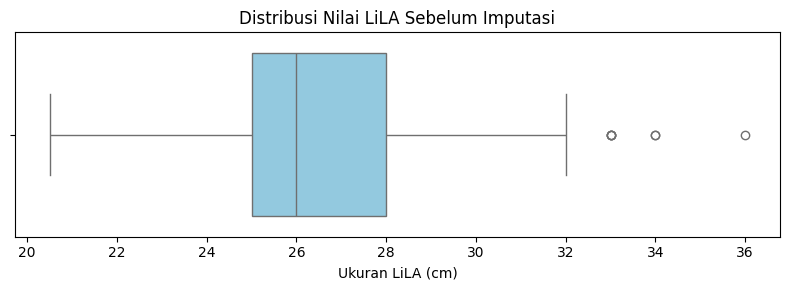

In [10]:
# ==============================================================================
# 1. EKSTRAKSI & KOREKSI DATA LiLA
# ==============================================================================
df['LILA_status'] = df['ibu_LILA'].apply(lambda x: 'KEK' if 'KEK' in str(x).upper() else 'Normal')

def ambil_angka(teks):
    if pd.isna(teks):
        return np.nan
    cocok = re.search(r'\((\d+\.?\d*)\)', str(teks))
    if cocok:
        return float(cocok.group(1))
    return np.nan

df['LILA_angka'] = df['ibu_LILA'].apply(ambil_angka)

# Koreksi Typo & Logika Medis sekaligus di awal
df['LILA_angka'] = df['LILA_angka'].apply(lambda x: x / 10 if x > 150 else x)
df['LILA_angka'] = df['LILA_angka'].replace(0, np.nan)

# Laporan Kerusakan Awal
kosong_kek = len(df[(df['LILA_status'] == 'KEK') & (df['LILA_angka'].isna())])
kosong_norm = len(df[(df['LILA_status'] == 'Normal') & (df['LILA_angka'].isna())])
print("=== LAPORAN AWAL KERUSAKAN DATA LiLA ===")
print(f"Jumlah KEK kosong/0    : {kosong_kek} baris")
print(f"Jumlah Normal kosong/0 : {kosong_norm} baris\n")

# Visualisasi
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['LILA_angka'], color='skyblue')
plt.title('Distribusi Nilai LiLA Sebelum Imputasi')
plt.xlabel('Ukuran LiLA (cm)')
plt.tight_layout()
plt.show()

In [11]:
# ==============================================================================
# 2. PERHITUNGAN MEDIAN & IMPUTASI
# ==============================================================================
median_kek = df[df['LILA_status'] == 'KEK']['LILA_angka'].median()
median_normal = df[df['LILA_status'] == 'Normal']['LILA_angka'].median()

print("=== PROSES PENGISIAN DATA ===")
print(f"Median KEK untuk imputasi    : {median_kek} cm")
print(f"Median Normal untuk imputasi : {median_normal} cm")

# Eksekusi pengisian
df['LILA_angka'] = df.apply(
    lambda row: median_kek if (row['LILA_status'] == 'KEK' and pd.isna(row['LILA_angka']))
    else (median_normal if (row['LILA_status'] == 'Normal' and pd.isna(row['LILA_angka']))
    else row['LILA_angka']),
    axis=1
)

=== PROSES PENGISIAN DATA ===
Median KEK untuk imputasi    : 22.0 cm
Median Normal untuk imputasi : 26.0 cm


In [12]:
# ==============================================================================
# 3. VERIFIKASI HASIL AKHIR
# ==============================================================================
print("=== LAPORAN FINAL SESUDAH IMPUTASI ===")
print(f"Jumlah data LiLA yang masih kosong : {df['LILA_angka'].isna().sum()}")
print(f"Jumlah data LiLA bernilai 0        : {(df['LILA_angka'] == 0).sum()}\n")

print("--- Statistik Distribusi Akhir (Normal) ---")
print(df[df['LILA_status'] == 'Normal']['LILA_angka'].describe().loc[['count', 'mean', 'std', 'min', '50%', 'max']])

print("\n--- Statistik Distribusi Akhir (KEK) ---")
print(df[df['LILA_status'] == 'KEK']['LILA_angka'].describe().loc[['count', 'mean', 'std', 'min', '50%', 'max']])
print("-" * 80)

=== LAPORAN FINAL SESUDAH IMPUTASI ===
Jumlah data LiLA yang masih kosong : 0
Jumlah data LiLA bernilai 0        : 0

--- Statistik Distribusi Akhir (Normal) ---
count    172.000000
mean      26.793023
std        2.436794
min       24.000000
50%       26.000000
max       36.000000
Name: LILA_angka, dtype: float64

--- Statistik Distribusi Akhir (KEK) ---
count    132.000000
mean      22.000000
std        0.222752
min       20.500000
50%       22.000000
max       23.000000
Name: LILA_angka, dtype: float64
--------------------------------------------------------------------------------


#### 1.4.7 Memproses Kolom Jarak Kehamilan  
Pencatatan riwayat `ibu_Jarak Kehamilan` aslinya berbentuk teks dinamis (contoh: "2 Tahun 3 Bulan" atau "0 Tahun 18 Bulan"). Bagian ini menggunakan *Regular Expression* (Regex) untuk mengekstraksi nilai numerik tahun dan bulan, mengonversinya menjadi satuan akumulasi total bulan pada fitur baru `jarak_kehamilan_bulan`, serta membuang kolom teks aslinya.

In [13]:
# ==============================================================================
# 1. MELIHAT KONDISI AWAL JARAK KEHAMILAN
# ==============================================================================
print("=== Kondisi Awal Pencatatan Teks ===")
display(df[['ibu_Kehamilan Ke-', 'ibu_Jarak Kehamilan']].head())

=== Kondisi Awal Pencatatan Teks ===


,ibu_Kehamilan Ke-,ibu_Jarak Kehamilan
3,3,5 Tahun 3 Bulan
13,3,10 Tahun 0 Bulan
24,1,Tahun 0 Bulan
30,2,0 Tahun 0 Bulan
43,2,Tahun 0 Bulan


In [14]:
# ==============================================================================
# 2. KONVERSI TEKS KE TOTAL BULAN & VERIFIKASI
# ==============================================================================

def konversi_ke_bulan(teks):
    if pd.isna(teks):
        return np.nan

    # Mencari pola angka sebelum kata "Tahun" dan "Bulan"
    match_tahun = re.search(r'(\d+)\s*Tahun', str(teks), re.IGNORECASE)
    match_bulan = re.search(r'(\d+)\s*Bulan', str(teks), re.IGNORECASE)

    # Ekstrak angkanya, jika tidak ada, jadikan 0
    tahun = int(match_tahun.group(1)) if match_tahun else 0
    bulan = int(match_bulan.group(1)) if match_bulan else 0

    # Hitung total bulan
    return (tahun * 12) + bulan

# Menerapkan fungsi ke kolom baru
df['jarak_kehamilan_bulan'] = df['ibu_Jarak Kehamilan'].apply(konversi_ke_bulan)

# Menghapus kolom teks aslinya
df = df.drop(columns=['ibu_Jarak Kehamilan'])

# Verifikasi Hasilnya
print("=== Statistik Jarak Kehamilan (Bulan) ===")
print(df['jarak_kehamilan_bulan'].describe().loc[['count', 'mean', 'std', 'min', '50%', 'max']])

print("\n--- 10 Data Teratas Hasil Konversi ---")
display(df[['ibu_Kehamilan Ke-', 'jarak_kehamilan_bulan']].head(10))
print("-" * 80)

=== Statistik Jarak Kehamilan (Bulan) ===


count    304.000000
mean      34.088816
std       44.938264
min        0.000000
50%        9.000000
max      240.000000
Name: jarak_kehamilan_bulan, dtype: float64

--- 10 Data Teratas Hasil Konversi ---


,ibu_Kehamilan Ke-,jarak_kehamilan_bulan
3,3,63
13,3,120
24,1,0
30,2,0
43,2,0
48,1,0
51,2,36
66,1,0
67,1,0
82,2,60


--------------------------------------------------------------------------------


#### 1.4.8 Memproses Kolom Berat Badan Lahir  
Pencatatan target `BB Lahir` memiliki satuan yang sangat bervariasi (gram, kilogram, atau *shorthand* puluhan). Bagian ini menstandarkan seluruh nilai ke dalam satuan **Gram**, membuang data yang tidak masuk akal secara medis ($< 500$ gram/kategori abortus), dan melakukan *encoding* menjadi kelas target akhir `Label_BBLR` (Rendah/Normal).

In [15]:
# ==============================================================================
# 1. MELIHAT KONDISI AWAL PENCATATAN BERAT BAYI
# ==============================================================================
print("=== Kondisi Awal Kolom BB Lahir ===")
display(df['BB Lahir'].head(10))

=== Kondisi Awal Kolom BB Lahir ===


3        2.8
13       3.0
24       3.0
30       3.5
43       2.3
48       3.0
51       3.0
66       3.5
67    3300.0
82       2.3
Name: BB Lahir, dtype: float64

In [16]:
# ==============================================================================
# 2. STANDARISASI GRAM, KOREKSI MEDIS, & ENCODING TARGET
# ==============================================================================

# 1. Menghapus data yang beratnya dicatat 0
df = df[df['BB Lahir'] != 0]

# 2. Fungsi membersihkan typo dan standarisasi satuan ke Gram
def bersihkan_bb_final(bb):
    if pd.isna(bb):
        return np.nan

    # Kasus 1: Kelebihan Nol (Misal 10000 -> 1000, 25000 -> 2500)
    if bb >= 10000:
        return bb / 10

    # Kasus 2: Shorthand Puluhan (Misal 22.6 -> 2260, 32 -> 3200, 60 -> 6000)
    elif 15 <= bb <= 60:
        return bb * 100

    # Kasus 3: Satuan Kilogram (Misal 2.5 -> 2500, 4.8 -> 4800)
    elif bb < 15:
        return bb * 1000
    return bb

# Menerapkan fungsi ke kolom baru
df['BB Lahir (Gram)'] = df['BB Lahir'].apply(bersihkan_bb_final)

# 3. KOREKSI MEDIS: Menghapus berat bayi < 500 Gram (Kategori Abortus)
df = df[df['BB Lahir (Gram)'] >= 500]

# 4. ENCODING TARGET AKHIR: 'Rendah' (< 2500g) dan 'Normal' (>= 2500g)
df['Label_BBLR'] = df['BB Lahir (Gram)'].apply(lambda x: 'Rendah' if x < 2500 else 'Normal')

# Menghapus kolom asli agar memori tetap bersih
df = df.drop(columns=['BB Lahir'])

# 5. VERIFIKASI HASIL FINAL TARGET PREDIKSI
print("=== Distribusi Kelas Target (Label_BBLR) ===")
print(df['Label_BBLR'].value_counts())
print(f"Total sampel bersih siap pakai: {len(df)} baris\n")

print("=== Statistik Akhir BB Lahir (Gram) ===")
print(df['BB Lahir (Gram)'].describe().loc[['count', 'mean', 'std', 'min', '50%', 'max']])
print("-" * 80)

=== Distribusi Kelas Target (Label_BBLR) ===
Label_BBLR
Normal    285
Rendah     19
Name: count, dtype: int64
Total sampel bersih siap pakai: 304 baris

=== Statistik Akhir BB Lahir (Gram) ===
count     304.000000
mean     3034.756579
std       382.427111
min      1600.000000
50%      3000.000000
max      4400.000000
Name: BB Lahir (Gram), dtype: float64
--------------------------------------------------------------------------------


### 1.5 Memproses Encoding Beberapa Kolom  
Melakukan koreksi anomali pencatatan fisik ibu (Usia, Berat Badan, Tinggi Badan) serta memetakan data kategorikal klinis (IMT, Imunisasi, Hb, Protein Urin, Gula Darah) menjadi representasi numerik ordinal (*Encoding*) yang siap dipelajari oleh algoritma *Machine Learning*.

In [17]:
# ==============================================================================
# 1. PEMBERSIHAN ANOMALI FISIK (USIA, BB, TB)
# ==============================================================================

# A. Perbaikan Usia Ibu (Koreksi tahun lahir & batasan universal 10 - 60 tahun)
def perbaiki_usia(umur):
    if pd.isna(umur): return np.nan
    if 1950 <= umur <= 2015:
        return 2026 - umur
    return umur

df['ibu_Usia Ibu'] = df['ibu_Usia Ibu'].apply(perbaiki_usia)
df = df[(df['ibu_Usia Ibu'] >= 10) & (df['ibu_Usia Ibu'] <= 60)]

# B. Batasan logis jumlah kehamilan
df = df[df['ibu_Kehamilan Ke-'] <= 10]

# C. Perbaikan BB Ibu (Koreksi typo desimal & batas minimal 30 Kg)
# df['ibu_BB'] = df['ibu_BB'].apply(lambda x: x / 10 if x > 150 else x)
# df = df[df['ibu_BB'] >= 30]

# COBA BARU
# C. Perbaikan BB Ibu (Koreksi typo desimal & batas minimal 30 Kg)
# Batas diubah ke 250 untuk memastikan obesitas ekstrem (misal 160kg) tidak rusak menjadi 16kg
df['ibu_BB'] = df['ibu_BB'].apply(lambda x: x / 10 if x > 250 else x)

# Jika ternyata masih ada data di atas 150 setelah dikoreksi desimalnya, kita biarkan saja (karena itu obesitas valid).
df = df[df['ibu_BB'] >= 30]

# D. Perbaikan TB Ibu (Koreksi satuan mm ke cm & batas minimal 100 cm)
df['ibu_TB'] = df['ibu_TB'].apply(lambda x: x / 10 if x > 300 else x)
df = df.dropna(subset=['ibu_TB'])
df = df[df['ibu_TB'] >= 100]

# E. BARU: Batasan Logis Jarak Kehamilan (Maksimal 240 bulan / 20 Tahun)
df = df[df['jarak_kehamilan_bulan'] <= 240]

# ==============================================================================
# 2. PROSES ENCODING ORDINAL (TEKS -> ANGKA)
# ==============================================================================

df['ibu_IMT_encoded'] = df['ibu_IMT'].map({'BB Kurang': 0, 'BB Normal': 1, 'BB Lebih': 2, 'Obesitas': 3})
df['ibu_statusImunisasi_encoded'] = df['ibu_statusImunisasi'].map({'TT 0': 0, 'TT 1': 1, 'TT 2': 2, 'TT 3': 3, 'TT 4': 4, 'TT 5': 5})
df['ibu_Hb_encoded'] = df['ibu_Hb'].map({'Tidak Anemia (>=11)': 0, 'Anemia Ringan (10-10,9)': 1, 'Anemia Sedang (7-9,9)': 2, 'Anemia Berat (<7)': 3})
df['ibu_proteinUrin_encoded'] = df['ibu_proteinUrin'].map({'Negatif': 0, 'Positif': 1})
df['ibu_gulaDarah_encoded'] = df['ibu_gulaDarah'].map({'Normal < 200': 0, 'Tinggi >= 200': 1})

# Sanity Check: Memastikan tidak ada data yang gagal ter-encode (harus bernilai 0)
kolom_encode = ['ibu_IMT_encoded', 'ibu_statusImunisasi_encoded', 'ibu_Hb_encoded', 'ibu_proteinUrin_encoded', 'ibu_gulaDarah_encoded']
print("=== Pengecekan Data Gagal Encode (Semua harus 0) ===")
print(df[kolom_encode].isna().sum())

=== Pengecekan Data Gagal Encode (Semua harus 0) ===
ibu_IMT_encoded                0
ibu_statusImunisasi_encoded    0
ibu_Hb_encoded                 0
ibu_proteinUrin_encoded        0
ibu_gulaDarah_encoded          0
dtype: int64


In [18]:
# ==============================================================================
# 3. FINALIZATION: MEMBUANG KOLOM REDUDAN & LAPORAN AKHIR
# ==============================================================================

kolom_buang = ['ibu_Nama', 'ibu_tanggalImunisasi', 'ibu_Sumber Pembiayaan', 'Tanggalmelahirkan',
               'ibu_IMT', 'ibu_statusImunisasi', 'ibu_Hb', 'ibu_proteinUrin', 'ibu_gulaDarah']

# LANGSUNG TIMPA KE VARIABEL UTAMA 'df'
df = df.drop(columns=kolom_buang, errors='ignore')

print("=== LAPORAN STATISTIK FINAL (MURNI 100%) ===")
print(df[['ibu_Usia Ibu', 'ibu_BB', 'ibu_TB', 'jarak_kehamilan_bulan']].describe().loc[['count', 'mean', 'std', 'min', 'max']])
print(f"\nTotal baris data super murni yang siap dilatih: {len(df)} baris\n")

print("=== Distribusi Kelas Target Akhir (Label_BBLR) ===")
print(df['Label_BBLR'].value_counts())
print("-" * 80)

# Menampilkan info memori dan tipe data akhir
df.info()

=== LAPORAN STATISTIK FINAL (MURNI 100%) ===
       ibu_Usia Ibu      ibu_BB      ibu_TB  jarak_kehamilan_bulan
count    298.000000  298.000000  298.000000             298.000000
mean      29.587248   62.718456  154.097315              34.614094
std        6.990670   13.252709    4.833134              45.191945
min       15.000000   38.000000  140.000000               0.000000
max       45.000000  150.000000  170.000000             240.000000

Total baris data super murni yang siap dilatih: 298 baris

=== Distribusi Kelas Target Akhir (Label_BBLR) ===
Label_BBLR
Normal    279
Rendah     19
Name: count, dtype: int64
--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
Index: 298 entries, 3 to 4895
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ibu_Usia Ibu                 298 non-null    int64         
 1   ibu_Ke

### 1.6 Finalisasi Pembersihan  
Membersihkan memori secara menyeluruh (*memory sweep*) dengan membuang seluruh kolom tanggal, rincian bulan tunggal, dan teks asli. Data akhir yang tersisa di dalam memori adalah **100% fitur numerik/ordinal murni** yang siap diproses oleh algoritma *Decision Tree*.

In [19]:
# ==============================================================================
# FINALIZATION: PEMBERSIHAN MEMORI MENYELURUH (100% NUMERIK)
# ==============================================================================

# Daftar seluruh kolom mentah, tanggal, dan rincian yang harus disapu bersih
kolom_buang = [
    'ibu_Nama', 'ibu_Sumber Pembiayaan', 'Tanggalmelahirkan', 'lahir hidup/mati',
    'BB Lahir (Gram)', 'ibu_HPHT', 'ibu_tanggalImunisasi',
    'Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni',
    'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember',
    'ibu_LILA', 'LILA_status', 'ibu_IMT', 'ibu_statusImunisasi',
    'ibu_Hb', 'ibu_proteinUrin', 'ibu_gulaDarah',
    'kunj_Januari', 'kunj_Februari', 'kunj_Maret', 'kunj_April',
    'kunj_Mei', 'kunj_Juni', 'kunj_Juli', 'kunj_Agustus',
    'kunj_September', 'kunj_Oktober', 'kunj_November', 'kunj_Desember'
]

# LANGSUNG TIMPA KE VARIABEL UTAMA 'df' (Menghindari Konflik Variabel)
df = df.drop(columns=kolom_buang, errors='ignore')

# Verifikasi Hasil Akhir
print("=== PROSES PEMBERSIHAN FINAL SELESAI ===")
print(f"Total baris sampel bersih       : {len(df)} pasien")
print(f"Total kolom siap untuk ML (X/y) : {len(df.columns)} kolom murni\n")

print("--- Sekilas 5 Data Pertama (100% Angka/Murni) ---")
display(df.head())
print("-" * 80)

# Menampilkan struktur tipe data akhir (Semua harus int/float/object untuk target)
df.info()

=== PROSES PEMBERSIHAN FINAL SELESAI ===
Total baris sampel bersih       : 298 pasien
Total kolom siap untuk ML (X/y) : 13 kolom murni

--- Sekilas 5 Data Pertama (100% Angka/Murni) ---


,ibu_Usia Ibu,ibu_Kehamilan Ke-,ibu_BB,ibu_TB,kunjungan_anc_total,LILA_angka,jarak_kehamilan_bulan,Label_BBLR,ibu_IMT_encoded,ibu_statusImunisasi_encoded,ibu_Hb_encoded,ibu_proteinUrin_encoded,ibu_gulaDarah_encoded
3,38,3,63.0,152.0,1,28.0,63,Normal,2,1,0,0,0
13,34,3,50.0,160.0,1,22.0,120,Normal,1,4,0,0,0
24,33,1,43.0,150.0,1,22.0,0,Normal,1,1,0,0,0
43,29,2,52.0,152.0,1,22.0,0,Rendah,1,3,0,0,0
48,26,1,57.2,155.0,1,22.0,0,Normal,1,0,0,0,0


--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
Index: 298 entries, 3 to 4895
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ibu_Usia Ibu                 298 non-null    int64  
 1   ibu_Kehamilan Ke-            298 non-null    int64  
 2   ibu_BB                       298 non-null    float64
 3   ibu_TB                       298 non-null    float64
 4   kunjungan_anc_total          298 non-null    int64  
 5   LILA_angka                   298 non-null    float64
 6   jarak_kehamilan_bulan        298 non-null    int64  
 7   Label_BBLR                   298 non-null    str    
 8   ibu_IMT_encoded              298 non-null    int64  
 9   ibu_statusImunisasi_encoded  298 non-null    int64  
 10  ibu_Hb_encoded               298 non-null    int64  
 11  ibu_proteinUrin_encoded      298 non-null    int64  
 12  ibu_gulaDara

PENYIMPANAN FILE KE EXCEL

In [20]:
# Menyimpan dataset akhir yang sudah 100% bersih ke Excel
df.to_excel('D:\\Skirpsi\\excel\\Data_Ibu_Hamil_BBLR_CLEAN_FINAL.xlsx', index=False)
print("Data bersih berhasil disimpan secara permanen!")

Data bersih berhasil disimpan secara permanen!


## Tahap 2: Pembentukan Aturan Menggunakan Decision Tree

### 2.1 Penyiapan Input, Mapping Target, & Optimasi Pruning
Pada tahap ini, terdpat proses memisahkan kolom input (indikator klinis) ke dalam variabel `X` dan kolom target diagnosa ke dalam variabel `y`.

=== DISTRIBUSI TARGET ===
Normal   (Indeks 0) = 279 sampel
BBLR     (Indeks 1) = 19 sampel

[ccp_alpha Terbaik: 0.000000 dengan Skor F1-Macro CV: 0.5642]


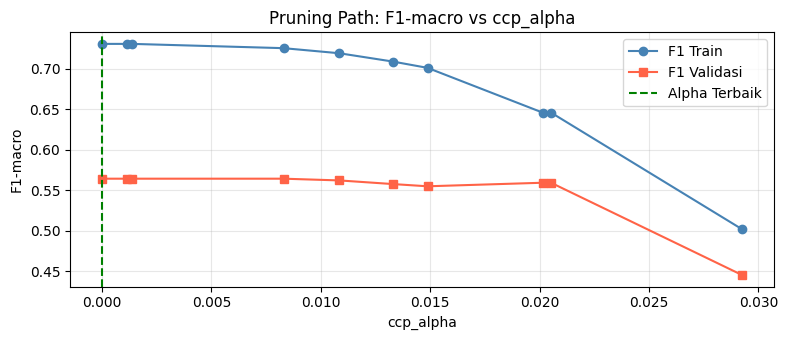

In [21]:
# ==============================================================================
# 1. PEMISAHAN INPUT (X) DAN TARGET (y)
# ==============================================================================
fitur_pakar = [
    'LILA_angka', 'ibu_Hb_encoded', 'ibu_proteinUrin_encoded', 
    'ibu_gulaDarah_encoded', 'ibu_IMT_encoded', 'ibu_statusImunisasi_encoded', 
    'jarak_kehamilan_bulan', 'ibu_Usia Ibu', 'kunjungan_anc_total', 'ibu_Kehamilan Ke-'
]

X = df[fitur_pakar]
y = df['Label_BBLR'].astype(str).str.strip()

# Normalisasi Target
y = y.replace({'Rendah': 'BBLR', 'rendah': 'BBLR', 'bblr': 'BBLR', 'normal': 'Normal'})

# Mapping: Normal=0, BBLR=1
MAPPING_TARGET = {'Normal': 0, 'BBLR': 1}
y_encoded = y.map(MAPPING_TARGET).to_numpy(dtype=int)
nama_kelas = np.array(['Normal', 'BBLR'])

print("=== DISTRIBUSI TARGET ===")
unique, counts = np.unique(y_encoded, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{nama_kelas[u]:<8} (Indeks {u}) = {c} sampel")

# ==============================================================================
# 2. MENCARI ccp_alpha OPTIMAL (COST-COMPLEXITY PRUNING)
# ==============================================================================
clf_full = DecisionTreeClassifier(criterion='gini', class_weight='balanced', min_samples_split=10, min_samples_leaf=5, random_state=42)
path = clf_full.cost_complexity_pruning_path(X, y_encoded)
ccp_alphas = path.ccp_alphas[:-1]

cv_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for alpha in ccp_alphas:
    clf_cv = DecisionTreeClassifier(criterion='gini', class_weight='balanced', min_samples_split=10, min_samples_leaf=5, ccp_alpha=alpha, random_state=42)
    scores = cross_validate(clf_cv, X, y_encoded, cv=skf, scoring=['f1_macro'], return_train_score=True)
    cv_results.append({'ccp_alpha': alpha, 'f1_val': scores['test_f1_macro'].mean(), 'f1_train': scores['train_f1_macro'].mean()})

df_cv = pd.DataFrame(cv_results)
best_idx = df_cv['f1_val'].idxmax()
best_alpha = df_cv.loc[best_idx, 'ccp_alpha']

print(f"\n[ccp_alpha Terbaik: {best_alpha:.6f} dengan Skor F1-Macro CV: {df_cv.loc[best_idx, 'f1_val']:.4f}]")

# Plot Pruning Path
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(df_cv['ccp_alpha'], df_cv['f1_train'], 'o-', label='F1 Train', color='steelblue')
ax.plot(df_cv['ccp_alpha'], df_cv['f1_val'], 's-', label='F1 Validasi', color='tomato')
ax.axvline(best_alpha, color='green', linestyle='--', label=f'Alpha Terbaik')
ax.set_xlabel('ccp_alpha'); ax.set_ylabel('F1-macro'); ax.set_title('Pruning Path: F1-macro vs ccp_alpha')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('D:\\Skirpsi\\images\\pruning_path.png', dpi=150); plt.show()

In [22]:
fold_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y_encoded), start=1):
    y_train = y_encoded[train_idx]
    y_test = y_encoded[test_idx]

    train_counts = Counter(y_train)
    test_counts = Counter(y_test)

    fold_counts.append({
        "Fold": fold_idx,
        "Train Normal": train_counts[0],
        "Train BBLR": train_counts[1],
        "Test Normal": test_counts[0],
        "Test BBLR": test_counts[1],
    })

    print(
        f"Fold {fold_idx}: "
        f"Train Normal={train_counts[0]}, BBLR={train_counts[1]} | "
        f"Test Normal={test_counts[0]}, BBLR={test_counts[1]}"
    )

df_fold = pd.DataFrame(fold_counts)
display(df_fold)

Fold 1: Train Normal=223, BBLR=15 | Test Normal=56, BBLR=4
Fold 2: Train Normal=223, BBLR=15 | Test Normal=56, BBLR=4
Fold 3: Train Normal=223, BBLR=15 | Test Normal=56, BBLR=4
Fold 4: Train Normal=223, BBLR=16 | Test Normal=56, BBLR=3
Fold 5: Train Normal=224, BBLR=15 | Test Normal=55, BBLR=4


,Fold,Train Normal,Train BBLR,Test Normal,Test BBLR
0,1,223,15,56,4
1,2,223,15,56,4
2,3,223,15,56,4
3,4,223,16,56,3
4,5,224,15,55,4


### 2.2 Pelatihan Model Final, Evaluasi CV, & Feature Importance

=== EVALUASI 5-FOLD STRATIFIED CV ===
Akurasi CV  : 0.8121
F1-Macro CV : 0.5642
ROC-AUC CV  : 0.6570

=== SKOR KEPENTINGAN FITUR ===
                      Fitur     Skor  Persentase
               ibu_Usia Ibu 0.359570       35.96
        kunjungan_anc_total 0.168522       16.85
            ibu_IMT_encoded 0.111996       11.20
          ibu_Kehamilan Ke- 0.096553        9.66
                 LILA_angka 0.074219        7.42
             ibu_Hb_encoded 0.071461        7.15
      jarak_kehamilan_bulan 0.060713        6.07
ibu_statusImunisasi_encoded 0.056967        5.70


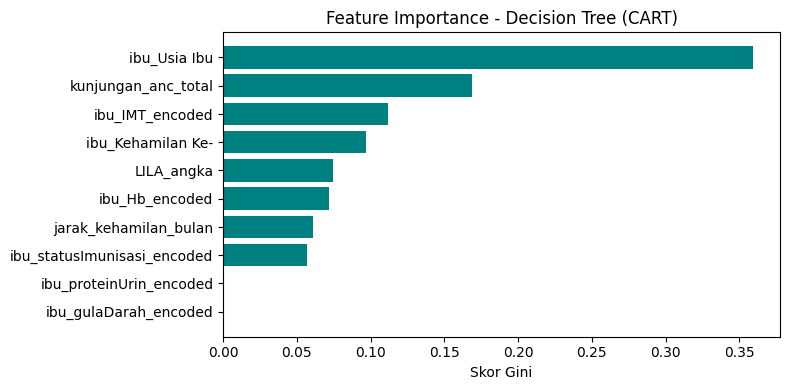

In [23]:
# ==============================================================================
# 3. MELATIH MODEL FINAL & EVALUASI
# ==============================================================================
model_cart = DecisionTreeClassifier(criterion='gini', class_weight='balanced', min_samples_split=10, min_samples_leaf=5, ccp_alpha=best_alpha, random_state=42)
model_cart.fit(X, y_encoded)

print("=== EVALUASI 5-FOLD STRATIFIED CV ===")
scoring_metrics = ['accuracy', 'f1_macro', 'roc_auc']
cv_final = cross_validate(model_cart, X, y_encoded, cv=skf, scoring=scoring_metrics)
print(f"Akurasi CV  : {cv_final['test_accuracy'].mean():.4f}")
print(f"F1-Macro CV : {cv_final['test_f1_macro'].mean():.4f}")
print(f"ROC-AUC CV  : {cv_final['test_roc_auc'].mean():.4f}\n")

# ==============================================================================
# 4. FEATURE IMPORTANCE
# ==============================================================================
df_importance = pd.DataFrame({'Fitur': X.columns, 'Skor': model_cart.feature_importances_}).sort_values(by='Skor', ascending=False).reset_index(drop=True)
df_importance['Persentase'] = (df_importance['Skor'] * 100).round(2)
print("=== SKOR KEPENTINGAN FITUR ===")
print(df_importance[df_importance['Skor'] > 0].to_string(index=False))

# Plot Feature Importance
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['teal' if s > 0 else 'lightgray' for s in df_importance['Skor'][::-1]]
ax.barh(df_importance['Fitur'][::-1], df_importance['Skor'][::-1], color=colors)
ax.set_title('Feature Importance - Decision Tree (CART)'); ax.set_xlabel('Skor Gini')
plt.tight_layout(); plt.savefig('D:\\Skirpsi\\images\\feature_importance.png', dpi=150); plt.show()

### 2.3 Visualisasi Struktur Pohon & Confusion Matrix

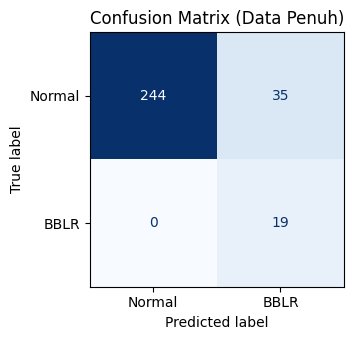

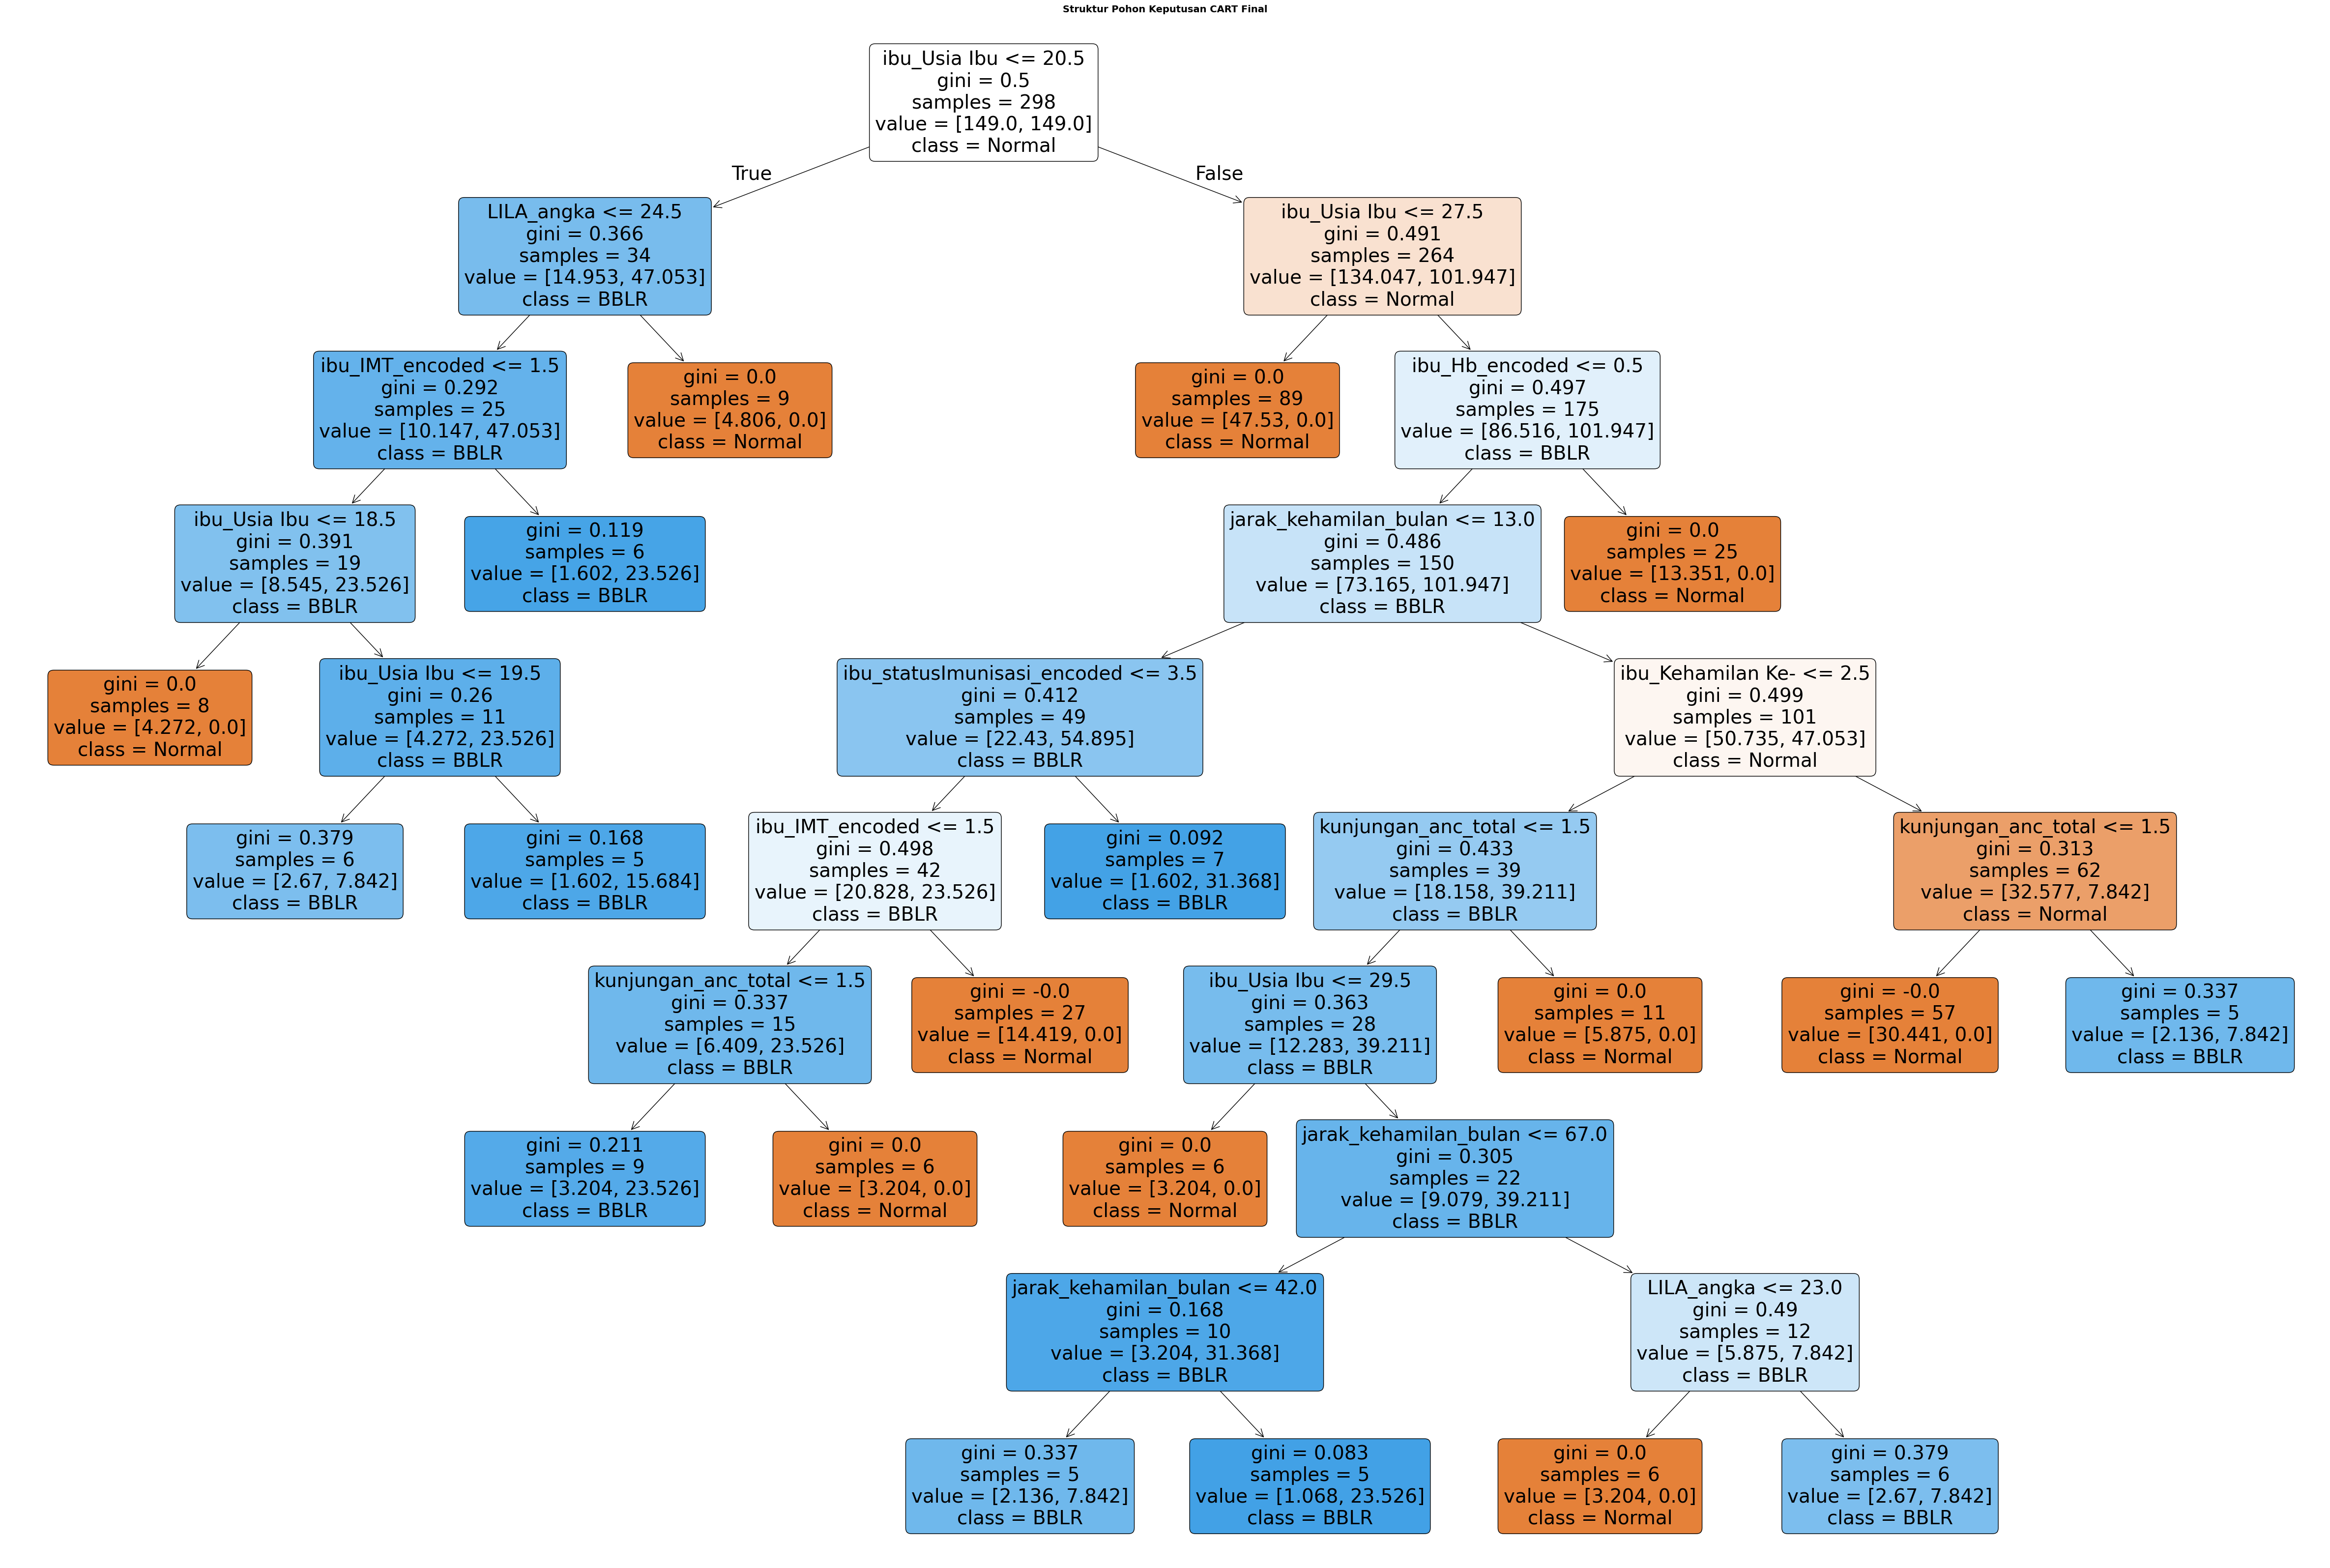

[*] Gambar pohon berhasil disimpan dalam format SVG dan PNG (High-Res)!


In [ ]:
# ==============================================================================
# 5. VISUALISASI POHON & CONFUSION MATRIX
# ==============================================================================
# 1. Confusion Matrix (Tetap sama, hanya dinaikkan DPI-nya)
y_pred = model_cart.predict(X)
cm = confusion_matrix(y_encoded, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 3.5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nama_kelas).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (Data Penuh)')
plt.tight_layout()
plt.savefig('D:\\Skirpsi\\images\\confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Gambar Pohon Keputusan (DIPERBAIKI)
# Sedikit memperbesar rasio kanvas agar kotak tidak saling berhimpitan
fig_w = max(15, model_cart.get_n_leaves() * 2.5)
fig_h = max(32, model_cart.get_depth() * 2.0)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

plot_tree(model_cart, 
          feature_names=list(X.columns), 
          class_names=nama_kelas, 
          filled=True, 
          rounded=True, 
          fontsize=28, 
          ax=ax)

plt.title('Struktur Pohon Keputusan CART Final', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# Simpan dalam format SVG (Sangat direkomendasikan untuk masuk ke MS Word)
plt.savefig('D:\\Skirpsi\\images\\decision_tree_full.svg', format='svg', bbox_inches='tight')

# Simpan juga dalam format PNG beresolusi super tinggi (600 DPI) sebagai cadangan
plt.savefig('D:\\Skirpsi\\images\\decision_tree_full_HighRes.png', dpi=600, bbox_inches='tight')

plt.show()
print("[*] Gambar pohon berhasil disimpan dalam format SVG dan PNG (High-Res)!")

### 2.4 Ekstraksi Aturan IF-THEN Otomatis (Rule Base)

In [25]:
# ==============================================================================
# 6. EKSTRAKSI RULES IF-THEN LENGKAP
# ==============================================================================
def extract_rules_lengkap(tree_model, feature_names, class_names, X_data):
    tree_ = tree_model.tree_
    feature_name = [feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!" for i in tree_.feature]
    paths = []
    
    def recurse(node, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            recurse(tree_.children_left[node], path + [f"({name} <= {np.round(threshold, 2)})"])
            recurse(tree_.children_right[node], path + [f"({name} > {np.round(threshold, 2)})"])
        else:
            val = tree_.value[node][0]
            maj_idx = int(np.argmax(val))
            paths.append({
                'conditions': path, 'prediksi': class_names[maj_idx],
                'support_asli': int(tree_.n_node_samples[node]),
                'confidence': val[maj_idx] / val.sum()
            })
    recurse(0, [])
    
    # Cetak & Simpan Rules
    print("=== DAFTAR ATURAN (RULE BASE) HASIL EKSTRAKSI ===")
    rules_list = []
    for i, p in enumerate(paths, 1):
        cond_str = " AND ".join(p['conditions'])
        cov = (p['support_asli'] / len(X_data)) * 100
        print(f"Rule {i}: IF {cond_str} THEN {p['prediksi'].upper()} "
                f"(Support: {p['support_asli']} | Conf: {p['confidence']*100:.1f}%)")
        
        rules_list.append({
            'Rule_ID': f"Rule_{i}", 'Prediksi': p['prediksi'].upper(),
            'Kondisi': cond_str, 'Support_Pasien': p['support_asli'],
            'Confidence_%': round(p['confidence']*100, 2), 'Coverage_%': round(cov, 2)
        })
        
    df_rules = pd.DataFrame(rules_list)
    df_rules.to_excel('D:\\Skirpsi\\excel\\rules_if_then_final.xlsx', index=False)
    print(f"\n[Berhasil mengekspor {len(df_rules)} aturan ke file: 'rules_if_then_final.xlsx']")
    return df_rules

df_rules_final = extract_rules_lengkap(model_cart, list(X.columns), nama_kelas, X)

=== DAFTAR ATURAN (RULE BASE) HASIL EKSTRAKSI ===
Rule 1: IF (ibu_Usia Ibu <= 20.5) AND (LILA_angka <= 24.5) AND (ibu_IMT_encoded <= 1.5) AND (ibu_Usia Ibu <= 18.5) THEN NORMAL (Support: 8 | Conf: 100.0%)
Rule 2: IF (ibu_Usia Ibu <= 20.5) AND (LILA_angka <= 24.5) AND (ibu_IMT_encoded <= 1.5) AND (ibu_Usia Ibu > 18.5) AND (ibu_Usia Ibu <= 19.5) THEN BBLR (Support: 6 | Conf: 74.6%)
Rule 3: IF (ibu_Usia Ibu <= 20.5) AND (LILA_angka <= 24.5) AND (ibu_IMT_encoded <= 1.5) AND (ibu_Usia Ibu > 18.5) AND (ibu_Usia Ibu > 19.5) THEN BBLR (Support: 5 | Conf: 90.7%)
Rule 4: IF (ibu_Usia Ibu <= 20.5) AND (LILA_angka <= 24.5) AND (ibu_IMT_encoded > 1.5) THEN BBLR (Support: 6 | Conf: 93.6%)
Rule 5: IF (ibu_Usia Ibu <= 20.5) AND (LILA_angka > 24.5) THEN NORMAL (Support: 9 | Conf: 100.0%)
Rule 6: IF (ibu_Usia Ibu > 20.5) AND (ibu_Usia Ibu <= 27.5) THEN NORMAL (Support: 89 | Conf: 100.0%)
Rule 7: IF (ibu_Usia Ibu > 20.5) AND (ibu_Usia Ibu > 27.5) AND (ibu_Hb_encoded <= 0.5) AND (jarak_kehamilan_bulan <= 

### 2.5 Perubahan Aturan ke Dalam bentuk Linguistik

In [26]:
# ==============================================================================
# 7. TRANSLASI CRISP RULES KE BAHASA LINGUISTIK PAKAR (RANGE LOGIC)
# ==============================================================================
def translasi_kondisi_crisp(kondisi_raw):
    peta = {
        # Hemoglobin (0=Normal, 1/2/3=Anemia)
        '(ibu_Hb_encoded <= 0.5)' : '(Status Hb is Normal)',
        '(ibu_Hb_encoded > 0.5)'  : '(Status Hb is Anemia)',
        '(ibu_Hb_encoded <= 1.5)' : '(Status Hb is Normal/Anemia)',
        '(ibu_Hb_encoded > 1.5)'  : '(Status Hb is Anemia)',
        '(ibu_Hb_encoded <= 2.5)' : '(Status Hb is Normal/Anemia)',
        '(ibu_Hb_encoded > 2.5)'  : '(Status Hb is Anemia)',

        # IMT Ibu
        '(ibu_IMT_encoded <= 0.5)' : '(IMT Ibu is BB Kurang)',
        '(ibu_IMT_encoded <= 1.5)' : '(IMT Ibu is BB Kurang/BB Normal)',
        '(ibu_IMT_encoded <= 2.5)' : '(IMT Ibu is BB Kurang/BB Normal/BB Lebih)',
        '(ibu_IMT_encoded > 0.5)'  : '(IMT Ibu is BB Normal/BB Lebih/Obesitas)',
        '(ibu_IMT_encoded > 1.5)'  : '(IMT Ibu is BB Lebih/Obesitas)',
        '(ibu_IMT_encoded > 2.5)'  : '(IMT Ibu is Obesitas)',

        # Protein Urin
        '(ibu_proteinUrin_encoded <= 0.5)' : '(Protein Urin is Negatif)',
        '(ibu_proteinUrin_encoded <= 1.5)' : '(Protein Urin is Negatif/Samar)',
        '(ibu_proteinUrin_encoded > 0.5)'  : '(Protein Urin is Samar/Positif)',
        '(ibu_proteinUrin_encoded > 1.5)'  : '(Protein Urin is Positif)',

        # Gula Darah
        '(ibu_gulaDarah_encoded <= 0.5)' : '(Gula Darah is Normal)',
        '(ibu_gulaDarah_encoded > 0.5)'  : '(Gula Darah is Tinggi)',
    }
    return peta.get(kondisi_raw.strip(), None)

def proses_rentang_numerik(kondisi_raw_list):
    batas_var = {}
    kondisi_crisp = []
    pola = r'\((.+?)\s*(<=|>)\s*([\d.]+)\)'

    for k in kondisi_raw_list:
        k_bersih = k.strip()
        hasil_crisp = translasi_kondisi_crisp(k_bersih)
        if hasil_crisp:
            kondisi_crisp.append(hasil_crisp)
            continue

        match = re.match(pola, k_bersih)
        if match:
            var = match.group(1).strip()
            op  = match.group(2).strip()
            val = float(match.group(3).strip())

            if var not in batas_var:
                batas_var[var] = {'min': -math.inf, 'max': math.inf}

            if op == '>':
                batas_var[var]['min'] = max(batas_var[var]['min'], val)
            elif op == '<=':
                batas_var[var]['max'] = min(batas_var[var]['max'], val)

    return batas_var, kondisi_crisp

def translasi_range_ke_linguistik(var, v_min, v_max):
    if var == 'ibu_Usia Ibu':
        if v_max < 20: return '(Usia Ibu is Berisiko Muda)'
        elif v_min >= 20 and v_max < 35: return '(Usia Ibu is Tidak Berisiko)'
        elif v_min >= 35: return '(Usia Ibu is Berisiko Tua)'
        elif v_min < 20 and v_max < 35: return '(Usia Ibu is Berisiko Muda/Tidak Berisiko)'
        elif v_min >= 20 and v_max >= 35: return '(Usia Ibu is Tidak Berisiko/Berisiko Tua)'
        else: return '(Usia Ibu is Berisiko Muda/Tidak Berisiko/Berisiko Tua)'

    elif var == 'jarak_kehamilan_bulan':
        if v_max < 24: return '(Jarak Kehamilan is Berisiko Terlalu Dekat)'
        elif v_min >= 24 and v_max <= 60: return '(Jarak Kehamilan is Tidak Berisiko)'
        elif v_min > 60: return '(Jarak Kehamilan is Berisiko Terlalu Jauh)'
        elif v_min < 24 and v_max <= 60: return '(Jarak Kehamilan is Berisiko Terlalu Dekat/Tidak Berisiko)'
        elif v_min >= 24 and v_max > 60: return '(Jarak Kehamilan is Tidak Berisiko/Berisiko Terlalu Jauh)'
        else: return '(Jarak Kehamilan is Berisiko Terlalu Dekat/Tidak Berisiko/Berisiko Terlalu Jauh)'

    elif var == 'LILA_angka':
        if v_max < 23.5: return '(LILA is KEK)'
        elif v_min >= 23.5: return '(LILA is Normal)'
        else: return '(LILA is KEK/Normal)'

    elif var == 'kunjungan_anc_total':
        if v_max < 6: return '(Kunjungan ANC is Tidak Lengkap)'
        elif v_min >= 5.5: return '(Kunjungan ANC is Lengkap)'
        else: return '(Kunjungan ANC is Tidak Lengkap/Lengkap)'

    elif var == 'ibu_Kehamilan Ke-':
        if v_max <= 1.5: return '(Status Paritas is Primigravida)'
        elif v_min >= 1.5 and v_max <= 4.5: return '(Status Paritas is Multigravida)'
        elif v_min >= 4.5: return '(Status Paritas is Grandemultipara)'
        elif v_max <= 4.5: return '(Status Paritas is Primigravida/Multigravida)'
        elif v_min >= 1.5: return '(Status Paritas is Multigravida/Grandemultipara)'
        else: return '(Status Paritas is Primigravida/Multigravida/Grandemultipara)'

    elif var == 'ibu_statusImunisasi_encoded':
        b_min = int(v_min + 0.5) if v_min != -math.inf else 0
        b_max = int(v_max + 0.5) if v_max != math.inf else 5
        if b_max <= 1: return '(Status Imunisasi is TT Tidak Lengkap)'
        elif b_min >= 2: return '(Status Imunisasi is TT Lengkap)'
        else: return '(Status Imunisasi is TT Tidak Lengkap/TT Lengkap)'

    return f"({var} is rentang {v_min} s/d {v_max})"

print("=== PENELUSURAN TRANSLASI LINGUISTIK ===")
aturan_linguistik = []
# Pastikan menggunakan df_rules_final dari eksekusi sel ekstraksi sebelumnya
for _, baris in df_rules_final.iterrows():
    kondisi_raw_list = [k.strip() for k in baris['Kondisi'].split(' AND ')]
    batas_var, kondisi_crisp = proses_rentang_numerik(kondisi_raw_list)

    kondisi_linguistik = kondisi_crisp.copy()
    for var, batas in batas_var.items():
        hasil_ling = translasi_range_ke_linguistik(var, batas['min'], batas['max'])
        kondisi_linguistik.append(hasil_ling)

    if_part = " AND ".join(kondisi_linguistik)

    aturan_linguistik.append({
        'Rule'               : baris['Rule_ID'], # Gunakan penamaan asli dari sel 4
        'Prediksi'           : baris['Prediksi'],
        'Support_Asli'       : baris['Support_Pasien'], # Kolom dari sel 4
        'Confidence_%'       : baris['Confidence_%'],
        'Coverage_%'         : baris['Coverage_%'],
        'Kondisi_Numerik'    : baris['Kondisi'],
        'Kondisi_Linguistik' : if_part,
    })

    print(f"\n{baris['Rule_ID']} │ Prediksi: {baris['Prediksi']} │ Support: {baris['Support_Pasien']} │ Confidence: {baris['Confidence_%']}%")
    print(f"        IF   {if_part.replace(' AND ', chr(10) + '        AND ')}")
    print(f"        THEN Diagnosis = {baris['Prediksi']}")
    print("        " + "-" * 72)

df_linguistik = pd.DataFrame(aturan_linguistik)

=== PENELUSURAN TRANSLASI LINGUISTIK ===

Rule_1 │ Prediksi: NORMAL │ Support: 8 │ Confidence: 100.0%
        IF   (IMT Ibu is BB Kurang/BB Normal)
        AND (Usia Ibu is Berisiko Muda)
        AND (LILA is KEK/Normal)
        THEN Diagnosis = NORMAL
        ------------------------------------------------------------------------

Rule_2 │ Prediksi: BBLR │ Support: 6 │ Confidence: 74.6%
        IF   (IMT Ibu is BB Kurang/BB Normal)
        AND (Usia Ibu is Berisiko Muda)
        AND (LILA is KEK/Normal)
        THEN Diagnosis = BBLR
        ------------------------------------------------------------------------

Rule_3 │ Prediksi: BBLR │ Support: 5 │ Confidence: 90.73%
        IF   (IMT Ibu is BB Kurang/BB Normal)
        AND (Usia Ibu is Berisiko Muda/Tidak Berisiko)
        AND (LILA is KEK/Normal)
        THEN Diagnosis = BBLR
        ------------------------------------------------------------------------

Rule_4 │ Prediksi: BBLR │ Support: 6 │ Confidence: 93.62%
        IF   (I

In [27]:
# ==============================================================================
# 8. EKSPOR LEMBAR VALIDASI PAKAR & RINGKASAN EKSEKUTIF
# ==============================================================================

# Mendefinisikan kembali konstanta indeks target (0=Normal, 1=BBLR)
IDX_NORMAL = 0
IDX_BBLR   = 1

# A. Pembuatan File Excel Lembar Validasi Pakar (3 Sheet)
with pd.ExcelWriter('D:\\Skirpsi\\excel\\lembar_validasi_pakar.xlsx', engine='openpyxl') as writer:
    # Sheet 1: Arsip lengkap numerik dan linguistik
    df_linguistik.to_excel(writer, sheet_name='Rules Linguistik', index=False)

    # Sheet 2: Form Kosong untuk Validasi Dokter / Pakar Klinis
    df_validasi = df_linguistik[['Rule', 'Prediksi', 'Kondisi_Linguistik', 'Confidence_%', 'Coverage_%']].copy()
    df_validasi['Validasi Pakar'] = ''  # Diisi: Setuju / Tidak Setuju / Revisi
    df_validasi['Catatan Pakar']  = ''  # Diisi: Komentar medis
    df_validasi['Skor Keyakinan'] = ''  # Diisi skala 1-5
    df_validasi.to_excel(writer, sheet_name='Form Validasi', index=False)

    # Sheet 3: Konteks Parameter Model untuk Lampiran Pakar
    ringkasan = pd.DataFrame({
        'Parameter' : ['Model', 'ccp_alpha', 'Kedalaman Pohon', 'Jumlah Rules',
                       'Akurasi CV', 'F1-macro CV', 'Total Sampel', 'Kasus BBLR', 'Kasus Normal'],
        'Nilai'     : [
            'Decision Tree CART (Gini)', f'{best_alpha:.6f}', str(model_cart.get_depth()),
            str(len(df_rules_final)), f'{cv_final["test_accuracy"].mean()*100:.2f}%',
            f'{cv_final["test_f1_macro"].mean():.4f}', str(len(y_encoded)),
            str((y_encoded == IDX_BBLR).sum()), str((y_encoded == IDX_NORMAL).sum())
        ]
    })
    ringkasan.to_excel(writer, sheet_name='Info Model', index=False)

# B. Pencetakan Ringkasan Eksekutif Akhir
print("=== RINGKASAN AKHIR MODEL POHON KEPUTUSAN ===")
print(f"Model Algoritma   : Decision Tree CART (ccp_alpha = {best_alpha:.5f})")
print(f"Kedalaman Pohon   : {model_cart.get_depth()} level")
print(f"Total Basis Aturan: {len(df_rules_final)} Rules "
      f"({(df_linguistik['Prediksi'] == 'BBLR').sum()} BBLR, "
      f"{(df_linguistik['Prediksi'] == 'NORMAL').sum()} Normal)")
print(f"Performa Akurasi  : {cv_final['test_accuracy'].mean()*100:.2f}%")
print(f"Performa F1-Macro : {cv_final['test_f1_macro'].mean():.4f} ± {cv_final['test_f1_macro'].std():.4f}")
print("-" * 72)

# Sistem peringatan otomatis terkait kualitas pemangkasan
if best_alpha == 0:
    print("⚠ PERINGATAN: Nilai ccp_alpha = 0. Pohon keputusan tidak terpangkas.")
    print("  Aturan yang dihasilkan berisiko terlalu spesifik pada data latih (overfitting).")
else:
    print("✓ Pohon keputusan berhasil dipangkas secara optimal.")

print("\n[Arsip ekspor berhasil disimpan secara permanen di direktori lokal:]")
print("  ➜ 'rules_if_then_final.xlsx'    (Arsip Logika Matematika Numerik)")
print("  ➜ 'lembar_validasi_pakar.xlsx'  (Form Kuisioner Siap Cetak untuk Dokter/Bidan)")

=== RINGKASAN AKHIR MODEL POHON KEPUTUSAN ===
Model Algoritma   : Decision Tree CART (ccp_alpha = 0.00000)
Kedalaman Pohon   : 9 level
Total Basis Aturan: 19 Rules (9 BBLR, 10 Normal)
Performa Akurasi  : 81.21%
Performa F1-Macro : 0.5642 ± 0.0321
------------------------------------------------------------------------
⚠ PERINGATAN: Nilai ccp_alpha = 0. Pohon keputusan tidak terpangkas.
  Aturan yang dihasilkan berisiko terlalu spesifik pada data latih (overfitting).

[Arsip ekspor berhasil disimpan secara permanen di direktori lokal:]
  ➜ 'rules_if_then_final.xlsx'    (Arsip Logika Matematika Numerik)
  ➜ 'lembar_validasi_pakar.xlsx'  (Form Kuisioner Siap Cetak untuk Dokter/Bidan)


## Tahap 3: Pembentukan Batasan UMF dan LMF

### 3.1 Definisi Domain dan Fungsi Penghitung Parameter Hibrida
Menggunakan prinsip Liu & Mendel (2008), di mana titik puncak (*plateau*) dikunci pada batas pakar medis, sementara rentang ketidakpastian (UMF/LMF) dihitung secara dinamis dari sebaran deviasi standar data ($\pm k\sigma$).

In [28]:
# ==============================================================================
# 1. DEFINISI VARIABEL PAKAR & ALGORITMA IT2 HIBRIDA
# ==============================================================================

# Kamus Konfigurasi Parameter (Sesuai Batasan Klinis Pakar)
DEFINISI_VARIABEL = {
    'LILA': {
        'kolom': 'LILA_angka', 'satuan': 'cm', 'domain_min': None, 'domain_max': None, 'std_cap': None,
        'kategori': [
            {'nama': 'KEK', 'tipe': 'bahu_kiri', 'anchor': 23.5, 'filter': lambda x: x < 23.5},
            {'nama': 'Normal', 'tipe': 'bahu_kanan', 'anchor': 23.5, 'filter': lambda x: x >= 23.5},
        ]
    },
    'Usia_Ibu': {
        'kolom': 'ibu_Usia Ibu', 'satuan': 'tahun', 'domain_min': None, 'domain_max': None, 'std_cap': None,
        'kategori': [
            {'nama': 'Berisiko Muda', 'tipe': 'bahu_kiri', 'anchor': 20, 'filter': lambda x: x < 20},
            {'nama': 'Tidak Berisiko', 'tipe': 'trapesoid_tengah', 'anchor': [20, 35], 'filter': lambda x: (x >= 20) & (x < 35)},
            {'nama': 'Berisiko Tua', 'tipe': 'bahu_kanan', 'anchor': 35, 'filter': lambda x: x >= 35},
        ]
    },
    'Jarak_Kehamilan': {
        'kolom': 'jarak_kehamilan_bulan', 'satuan': 'bulan', 'domain_min': None, 'domain_max': None, 'std_cap': 15.0,
        'kategori': [
            {'nama': 'Berisiko Dekat', 'tipe': 'bahu_kiri', 'anchor': 24, 'filter': lambda x: x < 24},
            {'nama': 'Tidak Berisiko', 'tipe': 'trapesoid_tengah', 'anchor': [24, 60], 'inklusif_kanan': True, 'filter': lambda x: (x >= 24) & (x <= 60)},
            {'nama': 'Berisiko Jauh', 'tipe': 'bahu_kanan', 'anchor': 60, 'filter': lambda x: x > 60},
        ]
    },
    'IMT': {
        'kolom': 'imt', 'satuan': 'kg/m2', 'domain_min': 10.0, 'domain_max': 45.0, 'std_cap': None,
        'kategori': [
            {'nama': 'BB Kurang', 'tipe': 'bahu_kiri', 'anchor': 18.5, 'std_manual': 0.5, 'filter': lambda x: [0]},
            {'nama': 'BB Normal', 'tipe': 'trapesoid_tengah', 'anchor': [18.5, 25.0], 'std_manual': 0.5, 'inklusif_kanan': False, 'filter': lambda x: [0]},
            {'nama': 'BB Lebih', 'tipe': 'trapesoid_tengah', 'anchor': [25.0, 30.0], 'std_manual': 0.5, 'inklusif_kanan': False, 'filter': lambda x: [0]},
            {'nama': 'Obesitas', 'tipe': 'bahu_kanan', 'anchor': 30.0, 'std_manual': 0.5, 'filter': lambda x: [0]},
        ]
    },
    'Hemoglobin': {
        'kolom': 'hb', 'satuan': 'g/dL', 'domain_min': 2.0, 'domain_max': 20.0, 'std_cap': None,
        'kategori': [
            {'nama': 'Anemia', 'tipe': 'bahu_kiri', 'anchor': 11.0, 'std_manual': 0.25, 'filter': lambda x: [0]},
            {'nama': 'Normal', 'tipe': 'bahu_kanan', 'anchor': 11.0, 'std_manual': 0.25, 'filter': lambda x: [0]},
        ]
    },
    'Gula_Darah': {
        'kolom': 'gula_darah', 'satuan': 'mg/dL', 'domain_min': 50.0, 'domain_max': 400.0, 'std_cap': None,
        'kategori': [
            {'nama': 'Normal', 'tipe': 'bahu_kiri', 'anchor': 100.0, 'std_manual': 10.0, 'filter': lambda x: [0]},
            {'nama': 'Tinggi', 'tipe': 'bahu_kanan', 'anchor': 100.0, 'std_manual': 10.0, 'filter': lambda x: [0]},
        ]
    },
    'Protein_Urin': {
        'kolom': 'protein_urin', 'satuan': 'mg/dL', 'domain_min': 0.0, 'domain_max': 60.0, 'std_cap': None, 'is_crisp': True,
        'kategori': [
            {'nama': 'Negatif', 'tipe': 'bahu_kiri', 'anchor': 10.0, 'filter': lambda x: [0]},
            {'nama': 'Samar', 'tipe': 'trapesoid_tengah', 'anchor': [10.0, 30.0], 'inklusif_kanan': False, 'filter': lambda x: [0]},
            {'nama': 'Positif', 'tipe': 'bahu_kanan', 'anchor': 30.0, 'filter': lambda x: [0]},
        ]
    },
    'Status_Imunisasi': {
        'kolom': 'imunisasi_tt', 'satuan': 'encoded (0-5)', 'domain_min': 0.0, 'domain_max': 5.0, 'std_cap': None, 'is_crisp': True,
        'kategori': [
            {'nama': 'TT Tidak Lengkap', 'tipe': 'bahu_kiri', 'anchor': 1.5, 'filter': lambda x: [0]},
            {'nama': 'TT Lengkap', 'tipe': 'bahu_kanan', 'anchor': 1.5, 'filter': lambda x: [0]},
        ]
    },
    'Kunjungan_ANC': {
        'kolom': 'kunjungan_anc_total', 'satuan': 'kali', 'domain_min': None, 'domain_max': None, 'std_cap': None, 'is_crisp': True,
        'kategori': [
            {'nama': 'Tidak Lengkap', 'tipe': 'bahu_kiri', 'anchor': 6, 'filter': lambda x: x < 6},
            {'nama': 'Lengkap', 'tipe': 'bahu_kanan', 'anchor': 6, 'filter': lambda x: x >= 6},
        ]
    },
    'Kehamilan_Ke': {
        'kolom': 'ibu_Kehamilan Ke-', 'satuan': 'paritas', 'domain_min': None, 'domain_max': None, 'std_cap': None, 'is_crisp': True,
        'kategori': [
            {'nama': 'Primigravida', 'tipe': 'bahu_kiri', 'anchor': 1.5, 'filter': lambda x: x <= 1},
            {'nama': 'Multigravida', 'tipe': 'trapesoid_tengah', 'anchor': [1.5, 4.5], 'filter': lambda x: (x >= 2) & (x <= 4)},
            {'nama': 'Grandemultipara', 'tipe': 'bahu_kanan', 'anchor': 4.5, 'filter': lambda x: x >= 5},
        ]
    },
}

# Fungsi Penghitung Batas Kurva UMF dan LMF
def hitung_it2_hybrid(data_kat, domain_min, domain_max, tipe, anchor,
                      std_cap=None, inklusif_kanan=False, std_manual=None, is_crisp=False):
    
    if is_crisp:
        std_raw, std, n = 0.0, 0.0, 0
        catatan = 'Murni Crisp/Singleton (Tanpa FOU)'
        m_umf, m_lmf, epsilon = 0.0, 0.0, 0.0
    else:
        if std_manual is not None:
            std_raw, n, catatan = std_manual, 0, f'Expert-Driven (std={std_manual})'
        else:
            n = len(data_kat)
            std_raw = float(np.std(data_kat, ddof=1)) if n > 1 else 0.0
            catatan = ''
            if std_raw == 0:
                std_raw = (domain_max - domain_min) * 0.05
                catatan = f'Std=0 → default 5% domain = {round(std_raw, 3)}'

        std = std_raw
        if std_cap is not None and std_raw > std_cap:
            std, catatan = std_cap, catatan + f'; Std dipotong ke cap={std_cap}'

        m_umf, m_lmf, epsilon = 2.0 * std, 1.0 * std, 0.001

    if tipe == 'bahu_kiri':
        umf = [domain_min, domain_min, anchor - epsilon, round(anchor + m_umf, 3)]
        lmf = [domain_min, domain_min, anchor - epsilon, round(anchor + m_lmf, 3)]
    elif tipe == 'bahu_kanan':
        umf = [round(anchor - m_umf, 3), anchor, domain_max, domain_max]
        lmf = [round(anchor - m_lmf, 3), anchor, domain_max, domain_max]
    elif tipe == 'trapesoid_tengah':
        ak1, ak2 = anchor[0], anchor[1]
        c_val = ak2 if inklusif_kanan else ak2 - epsilon
        umf = [round(ak1 - m_umf, 3), ak1, c_val, round(ak2 + m_umf, 3)]
        lmf = [round(ak1 - m_lmf, 3), ak1, c_val, round(ak2 + m_lmf, 3)]

    # Pemotongan ke Batas Domain & Kunci Keamanan
    def kunci(p): return [round(max(domain_min, p[0]), 3), round(max(domain_min, p[1]), 3),
                          round(min(domain_max, p[2]), 3), round(min(domain_max, p[3]), 3)]
    umf, lmf = kunci(umf), kunci(lmf)
    lmf = [round(max(lmf[0], umf[0]), 3), round(max(lmf[1], umf[0]), 3),
           round(min(lmf[2], umf[3]), 3), round(min(lmf[3], umf[3]), 3)]

    return {'n_sampel': n, 'Std_Data': round(std_raw, 3), 'Std_Pakai': round(std, 3),
            'UMF': umf, 'LMF': lmf, 'FOU_width': round((umf[3]-umf[0])-(lmf[3]-lmf[0]), 3), 'Catatan': catatan}

### 3.2 Eksekusi Iterasi Data dan Ekspor Tabel Parameter
Menjalankan ekstraksi titik trapesium $a, b, c, d$ untuk setiap atribut dan mengekspor hasilnya secara permanen ke file Excel lokal `parameter_it2_hybrid.xlsx`.

In [29]:
# ==============================================================================
# 2. EKSEKUSI PEMODELAN, VALIDASI GAP, & EKSPOR EXCEL LOKAL
# ==============================================================================
semua_hasil = []

print("\n" + "=" * 70)
print("MEMULAI EKSEKUSI PEMODELAN PARAMETER")
print("=" * 70)

# Iterasi Eksekusi
for nama_var, config in DEFINISI_VARIABEL.items():
    kolom = config['kolom']
    is_crisp = config.get('is_crisp', False) # <--- Deteksi variabel crisp

    if kolom in df.columns:
        data_all = df[kolom].dropna().values.astype(float)
    else:
        data_all = np.array([0.0])

    domain_min = config['domain_min'] if config['domain_min'] is not None else float(data_all.min())
    domain_max = config['domain_max'] if config['domain_max'] is not None else float(data_all.max())
    std_cap = config.get('std_cap', None)

    print(f"\n➤ VARIABEL: {nama_var} ({config['satuan']})" + (" [CRISP/SINGLETON]" if is_crisp else ""))

    for kat in config['kategori']:
        # <--- Bypass filter ekstraksi data jika std_manual atau is_crisp aktif
        if kat.get('std_manual', None) is not None or is_crisp:
            data_kat = np.array([0.0])
        else:
            data_kat = data_all[kat['filter'](data_all)]

        # <--- Mencegah loop dilewati jika data < 2 pada variabel crisp
        if len(data_kat) < 2 and kat.get('std_manual', None) is None and not is_crisp: 
            continue

        # <--- Parameter is_crisp dikirim ke fungsi penghitung
        hasil = hitung_it2_hybrid(
            data_kat, domain_min, domain_max, 
            kat['tipe'], kat['anchor'],
            std_cap=std_cap, 
            inklusif_kanan=kat.get('inklusif_kanan', False), 
            std_manual=kat.get('std_manual', None),
            is_crisp=is_crisp
        )
        
        hasil.update({'Variabel': nama_var, 'Kategori': kat['nama'], 'Satuan': config['satuan'], 'anchor': kat['anchor']})
        semua_hasil.append(hasil)

        # Print log terminal agar terlihat rapi di VS Code
        status_fou = '✓ FOU Terbentuk' if hasil['FOU_width'] > 0 else '✗ Crisp (FOU=0)'
        print(f"   - {kat['nama']:<18} | UMF: {hasil['UMF']} | {status_fou}")

# Validasi Coverage (Pengecekan Celah Kritis)
print("\n\n=== VALIDASI CELAH KURVA (COVERAGE GAP CHECK) ===")
for nama_var in DEFINISI_VARIABEL.keys():
    hasil_var = [h for h in semua_hasil if h['Variabel'] == nama_var]
    ada_gap = False
    for j in range(len(hasil_var) - 1):
        if (hasil_var[j+1]['UMF'][0] - hasil_var[j]['UMF'][3]) > 0:
            print(f"⚠ GAP Terdeteksi pada {nama_var}: {hasil_var[j]['Kategori']} ➜ {hasil_var[j+1]['Kategori']}")
            ada_gap = True
    if not ada_gap: print(f"✓ {nama_var:<16}: Terlindungi penuh (Tidak ada celah)")

# Ekspor Excel Permanen di Direktori Lokal
df_hasil = pd.DataFrame(semua_hasil)
df_hasil['UMF [a,b,c,d]'] = df_hasil['UMF'].apply(str)
df_hasil['LMF [a,b,c,d]'] = df_hasil['LMF'].apply(str)

with pd.ExcelWriter('D:\\Skirpsi\\excel\\parameter_it2_hybrid.xlsx', engine='openpyxl') as writer:
    df_hasil[['Variabel', 'Kategori', 'Satuan', 'n_sampel', 'Std_Data', 'Std_Pakai', 
              'UMF [a,b,c,d]', 'LMF [a,b,c,d]', 'FOU_width', 'Catatan']].to_excel(writer, sheet_name='Tabel Parameter', index=False)
print("\n[Arsip Parameter Lengkap Berhasil Disimpan Lokal: 'parameter_it2_hybrid.xlsx']")


MEMULAI EKSEKUSI PEMODELAN PARAMETER

➤ VARIABEL: LILA (cm)
   - KEK                | UMF: [20.5, 20.5, 23.499, 23.951] | ✓ FOU Terbentuk
   - Normal             | UMF: [20.5, 23.5, 36.0, 36.0] | ✓ FOU Terbentuk

➤ VARIABEL: Usia_Ibu (tahun)
   - Berisiko Muda      | UMF: [15.0, 15.0, 19.999, 22.311] | ✓ FOU Terbentuk
   - Tidak Berisiko     | UMF: [15.0, 20, 34.999, 43.208] | ✓ FOU Terbentuk
   - Berisiko Tua       | UMF: [29.08, 35, 45.0, 45.0] | ✓ FOU Terbentuk

➤ VARIABEL: Jarak_Kehamilan (bulan)
   - Berisiko Dekat     | UMF: [0.0, 0.0, 23.999, 29.409] | ✓ FOU Terbentuk
   - Tidak Berisiko     | UMF: [2.734, 24, 60, 81.266] | ✓ FOU Terbentuk
   - Berisiko Jauh      | UMF: [30.0, 60, 240.0, 240.0] | ✓ FOU Terbentuk

➤ VARIABEL: IMT (kg/m2)
   - BB Kurang          | UMF: [10.0, 10.0, 18.499, 19.5] | ✓ FOU Terbentuk
   - BB Normal          | UMF: [17.5, 18.5, 24.999, 26.0] | ✓ FOU Terbentuk
   - BB Lebih           | UMF: [24.0, 25.0, 29.999, 31.0] | ✓ FOU Terbentuk
   - Obesitas    

### 3.3 Visualisasi Kurva Keanggotaan IT2FLS
Menggambar representasi grafis fungsi keanggotaan trapesium dengan batas atas (UMF tebal), batas bawah (LMF putus-putus), dan jejak ketidakpastian (*Footprint of Uncertainty* / FOU berarsir).


=== GENERASI FILE GRAFIK FUZZY ===


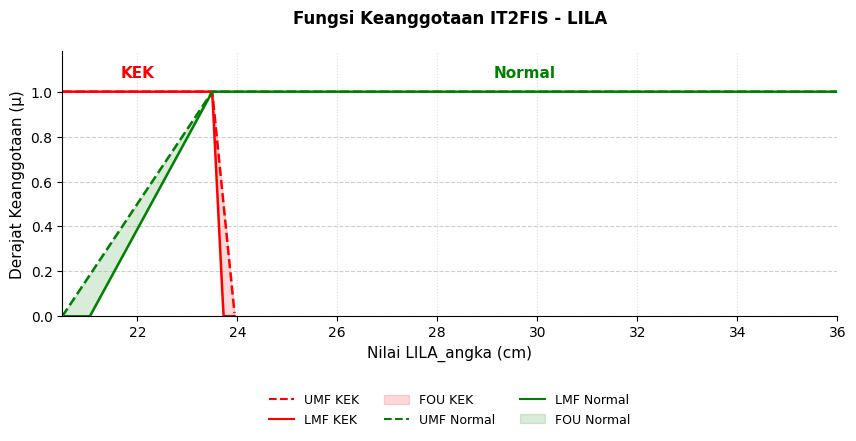

➜ Tersimpan lokal: 'D:\Skirpsi\images\keanggotaanFuzzyAwal\it2_hybrid_lila.png'



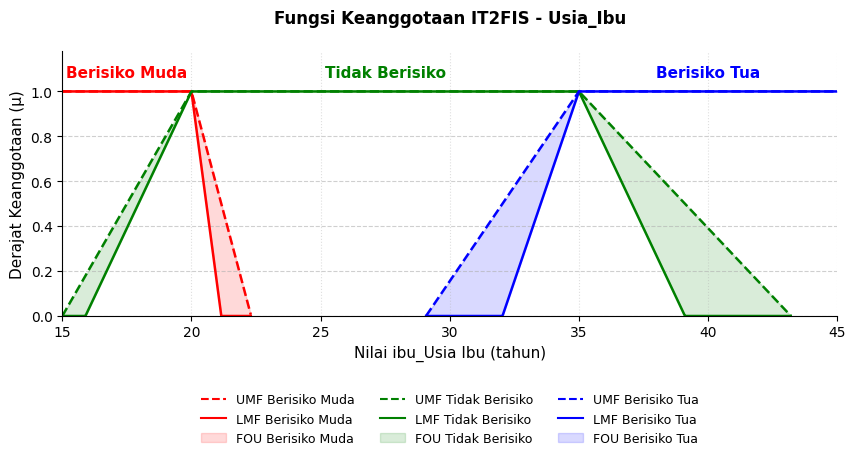

➜ Tersimpan lokal: 'D:\Skirpsi\images\keanggotaanFuzzyAwal\it2_hybrid_usia_ibu.png'



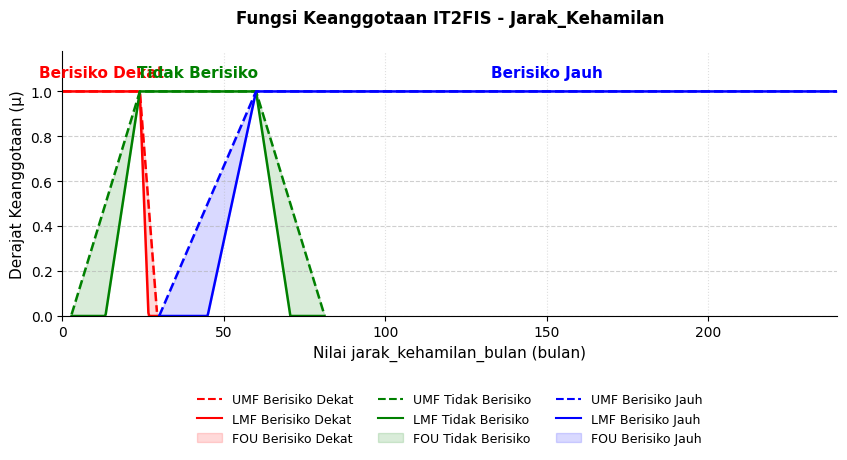

➜ Tersimpan lokal: 'D:\Skirpsi\images\keanggotaanFuzzyAwal\it2_hybrid_jarak_kehamilan.png'



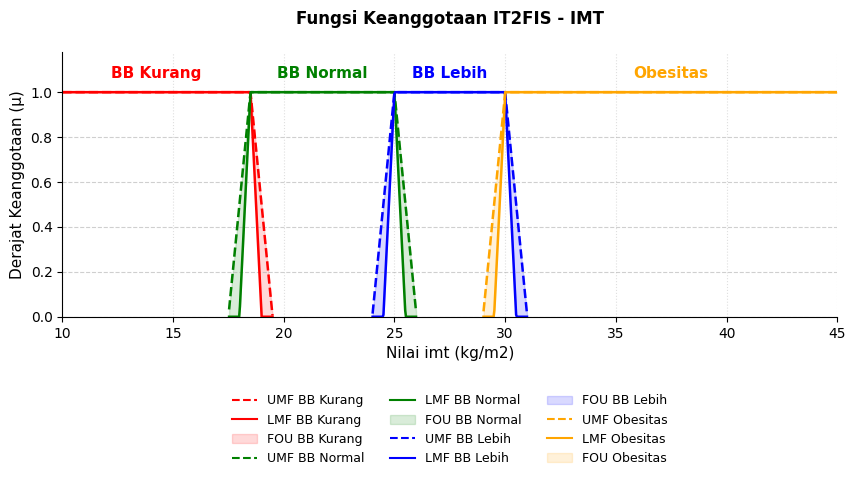

➜ Tersimpan lokal: 'D:\Skirpsi\images\keanggotaanFuzzyAwal\it2_hybrid_imt.png'



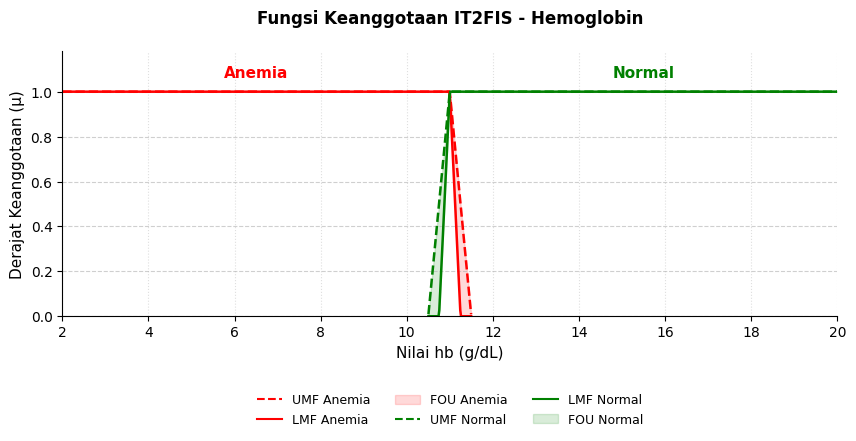

➜ Tersimpan lokal: 'D:\Skirpsi\images\keanggotaanFuzzyAwal\it2_hybrid_hemoglobin.png'



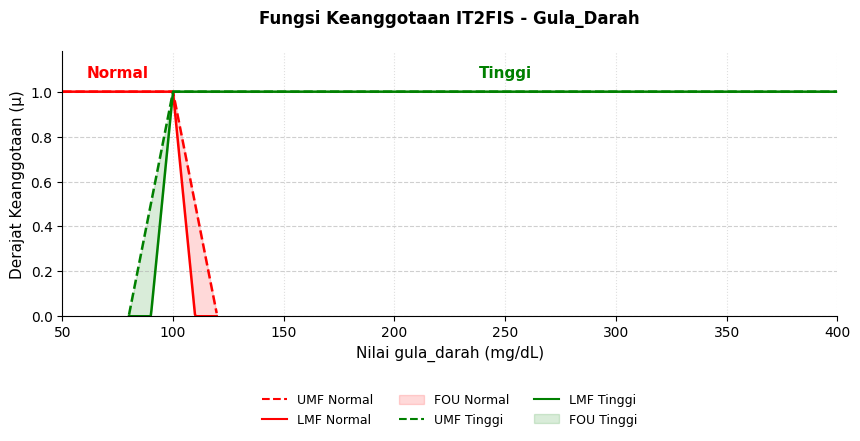

➜ Tersimpan lokal: 'D:\Skirpsi\images\keanggotaanFuzzyAwal\it2_hybrid_gula_darah.png'

➜ [Visualisasi DI-SKIP] Grafik Protein_Urin bersifat Crisp/Singleton.

➜ [Visualisasi DI-SKIP] Grafik Status_Imunisasi bersifat Crisp/Singleton.

➜ [Visualisasi DI-SKIP] Grafik Kunjungan_ANC bersifat Crisp/Singleton.

➜ [Visualisasi DI-SKIP] Grafik Kehamilan_Ke bersifat Crisp/Singleton.

----------------------------------------------------------------------
SELESAI - Seluruh parameter & grafik kurva Fuzzy berhasil diproduksi!


In [30]:
# ==============================================================================
# 3. GENERASI GRAFIK VISUALISASI KEANGGOTAAN FUZZY (LOKAL & TAMPIL DI LAYAR)
# ==============================================================================

def trapMF(x, a, b, c, d):
    y = np.zeros_like(x, dtype=float)
    with np.errstate(invalid='ignore', divide='ignore'):
        y = np.where((x > a) & (x < b) & (b > a), (x - a) / (b - a), y)
        y = np.where((x >= b) & (x <= c), 1.0, y)
        y = np.where((x > c) & (x < d) & (d > c), (d - x) / (d - c), y)
    return y

WARNA = ['#ff0000', '#008000', '#0000ff', '#ffa500', '#8e44ad']

print("\n" + "=" * 70)
print("=== GENERASI FILE GRAFIK FUZZY ===")
print("=" * 70)

for nama_var, config in DEFINISI_VARIABEL.items():
    
    if config.get('is_crisp', False):
        print(f"➜ [Visualisasi DI-SKIP] Grafik {nama_var} bersifat Crisp/Singleton.\n")
        continue 
        
    hasil_var = [h for h in semua_hasil if h['Variabel'] == nama_var]
    if not hasil_var:
        continue

    # ==========================================================================
    # [PERBAIKAN UTAMA] EKSTRAKSI BATAS GRAFIK DARI PARAMETER FUZZY
    # Mencegah grafik terpotong karena mengikuti data Excel
    # ==========================================================================
    semua_nilai_batas = []
    for h in hasil_var:
        semua_nilai_batas.extend(h['UMF'])
        semua_nilai_batas.extend(h['LMF'])
        
    # Ambil batas minimum dan maksimum absolut dari desain paramater pakar
    d_min = min(semua_nilai_batas)
    d_max = max(semua_nilai_batas)
    
    # Pengaman jika batasnya singular
    if d_min == d_max:
        d_min -= 1.0
        d_max += 1.0

    xs = np.linspace(d_min, d_max, 1000)

    fig, ax = plt.subplots(figsize=(10, 5))
    patches = []

    for i, h in enumerate(hasil_var):
        w    = WARNA[i % len(WARNA)]
        tipe = config['kategori'][i]['tipe']
        
        y_u = trapMF(xs, *h['UMF'])
        y_l = trapMF(xs, *h['LMF'])
        
        if tipe == 'bahu_kiri':
            y_u[xs < h['UMF'][1]] = 1.0
            y_l[xs < h['LMF'][1]] = 1.0
        elif tipe == 'bahu_kanan':
            y_u[xs > h['UMF'][2]] = 1.0
            y_l[xs > h['LMF'][2]] = 1.0

        start_x = h['UMF'][0]
        end_x   = h['UMF'][3]
        if tipe == 'bahu_kiri': start_x = xs[0]
        if tipe == 'bahu_kanan': end_x = xs[-1]
        
        plot_idx = (xs >= start_x) & (xs <= end_x)

        ax.plot(xs[plot_idx], y_u[plot_idx], color=w, linewidth=1.8, linestyle='--')
        ax.plot(xs[plot_idx], y_l[plot_idx], color=w, linewidth=1.8, linestyle='-')
        
        # Pengaman FOU
        y_l_safe = np.minimum(y_l, y_u)
        ax.fill_between(xs[plot_idx], y_l_safe[plot_idx], y_u[plot_idx], color=w, alpha=0.15)

        # Penempatan Teks
        b_umf = h['UMF'][1]
        c_umf = h['UMF'][2]
        if tipe == 'bahu_kiri':
            center_x = (d_min + c_umf) / 2.0
        elif tipe == 'bahu_kanan':
            center_x = (b_umf + d_max) / 2.0
        else:
            center_x = (b_umf + c_umf) / 2.0
            
        ax.text(center_x, 1.05, h['Kategori'], color=w, ha='center', va='bottom', 
                fontweight='bold', fontsize=11)

        patches.append(Line2D([0], [0], color=w, linestyle='--', lw=1.5, label=f"UMF {h['Kategori']}"))
        patches.append(Line2D([0], [0], color=w, linestyle='-', lw=1.5, label=f"LMF {h['Kategori']}"))
        patches.append(mpatches.Patch(color=w, alpha=0.15, label=f"FOU {h['Kategori']}"))

    ax.set_xlim(d_min, d_max)
    ax.set_ylim(0, 1.18) 
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.set_xlabel(f"Nilai {config['kolom']} ({config['satuan']})", fontsize=11)
    ax.set_ylabel('Derajat Keanggotaan (μ)', fontsize=11)
    
    ax.set_title(f"Fungsi Keanggotaan IT2FIS - {nama_var}", fontweight='bold', fontsize=12, pad=20)
    
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.grid(axis='x', linestyle=':', alpha=0.4)

    # Legenda di luar kotak grafik bawah
    ax.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, -0.25), 
              ncol=3, frameon=False, fontsize=9)

    plt.subplots_adjust(bottom=0.35) 
    
    # ==========================================================================
    # PENYIMPANAN GAMBAR KE FOLDER LOKAL
    # ==========================================================================
    folder_tujuan = r"D:\Skirpsi\images\keanggotaanFuzzyAwal"
    if not os.path.exists(folder_tujuan):
        os.makedirs(folder_tujuan)
        
    nama_file = f'it2_hybrid_{nama_var.lower()}.png'.replace("/", "_").replace(" ", "_")
    path_lengkap = os.path.join(folder_tujuan, nama_file)
    
    plt.savefig(path_lengkap, dpi=150, bbox_inches='tight')
    plt.show() 
    print(f"➜ Tersimpan lokal: '{path_lengkap}'\n")

print("-" * 70)
print("SELESAI - Seluruh parameter & grafik kurva Fuzzy berhasil diproduksi!")

## Tahap 4: Sistem Inti Diagnosis Risiko BBLR

### 4.1 Visualisasi Fungsi Keanggotaan Berbasis Kepakaran dan Data
Bagian ini memodelkan parameter keanggotaan *Interval Type-2 Fuzzy Logic System* (IT2FLS) untuk seluruh variabel medis. Setiap kategori direpresentasikan dengan batas atas (*Upper Membership Function* / UMF) dan batas bawah (*Lower Membership Function* / LMF) untuk menunjukkan ketidakpastian (*Footprint of Uncertainty* / FOU).

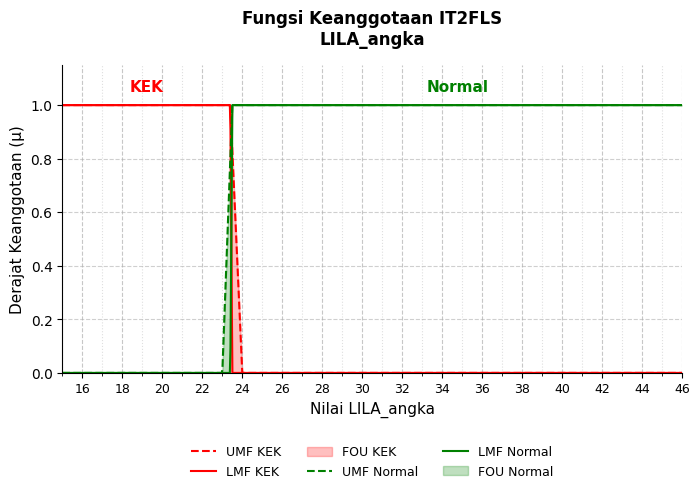

[*] Berhasil disimpan: D:\Skirpsi\images\LILA_angka_Fuzzy.png




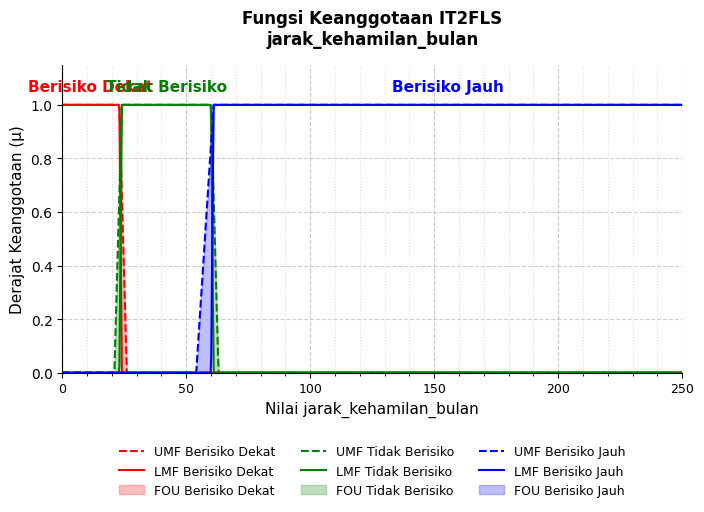

[*] Berhasil disimpan: D:\Skirpsi\images\jarak_kehamilan_bulan_Fuzzy.png




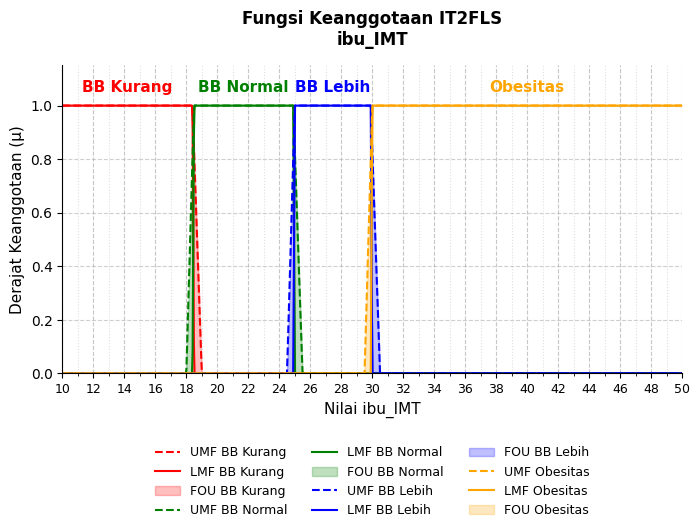

[*] Berhasil disimpan: D:\Skirpsi\images\ibu_IMT_Fuzzy.png




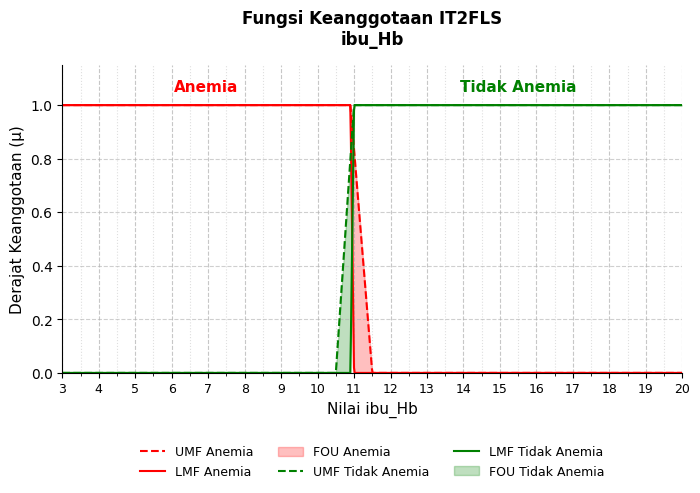

[*] Berhasil disimpan: D:\Skirpsi\images\ibu_Hb_Fuzzy.png




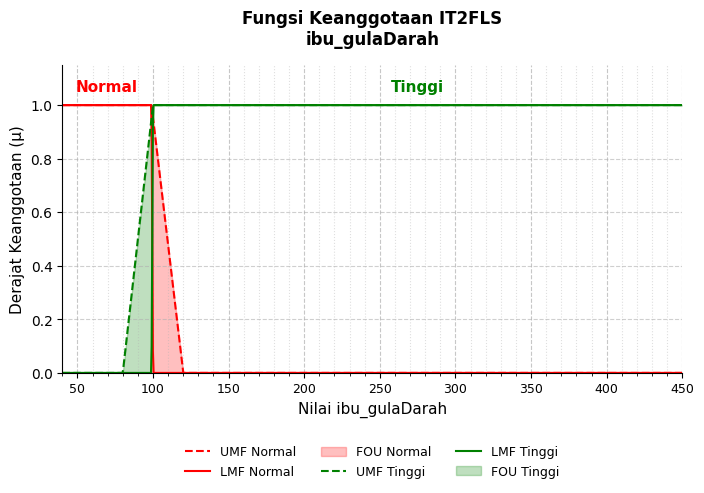

[*] Berhasil disimpan: D:\Skirpsi\images\ibu_gulaDarah_Fuzzy.png




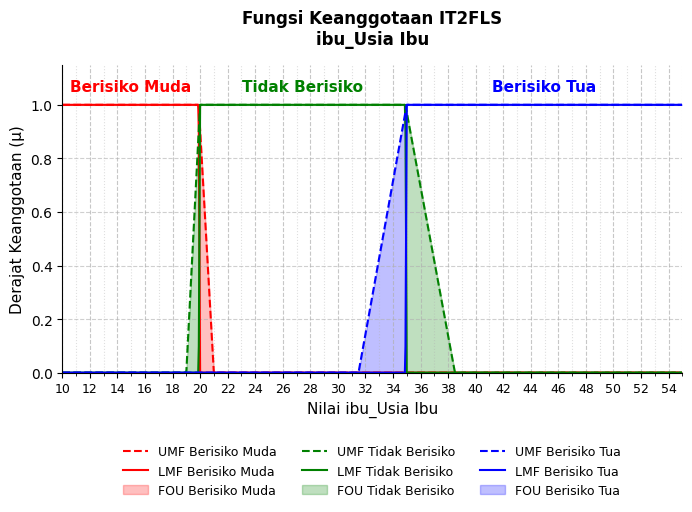

[*] Berhasil disimpan: D:\Skirpsi\images\ibu_Usia_Ibu_Fuzzy.png




In [31]:
PARAMETER_MF = {
    # A. LINGKAR LENGAN ATAS (LILA)
    'LILA_angka': {
        'KEK':    {'UMF': [15.0, 15.0, 23.4, 24.0], 'LMF': [15.0, 15.0, 23.4, 23.5]},
        'Normal': {'UMF': [23.0, 23.5, 46.0, 46.0], 'LMF': [23.4, 23.5, 46.0, 46.0]},
    },
    # B. JARAK KEHAMILAN
    'jarak_kehamilan_bulan': {
        'Berisiko Dekat': {'UMF': [0.0, 0.0, 23.0, 26.0],
                            'LMF': [0.0, 0.0,  23.0, 24.0]},
        'Tidak Berisiko': {'UMF': [21.0, 24.0,  60.0,  63.0],
                            'LMF': [23.0, 24.0,  60.0,  61.0]},
        'Berisiko Jauh':  {'UMF': [54.0, 61.0, 250.0, 250.0],
                            'LMF': [60.0, 61.0, 250.0, 250.0]},
    },

    # C. INDEKS MASSA TUBUH (IMT)
    'ibu_IMT': {
        'BB Kurang': {'UMF': [10.0, 10.0, 18.4, 19.0],
                        'LMF': [10.0, 10.0, 18.4, 18.5]},
        'BB Normal': {'UMF': [18.0, 18.5, 24.9, 25.5],
                        'LMF': [18.4, 18.5, 24.9, 25.0]},
        'BB Lebih':  {'UMF': [24.5, 25.0, 29.9, 30.5],
                        'LMF': [24.9, 25.0, 29.9, 30.0]},
        'Obesitas':  {'UMF': [29.5, 30.0, 50.0, 50.0],
                        'LMF': [29.9, 30.0, 50.0, 50.0]},
    },

    # D. HEMOGLOBIN (Hb)
    'ibu_Hb': {
        'Anemia':       {'UMF': [3.0,   3.0,  10.9, 11.5],
                        'LMF': [3.0,   3.0,  10.9, 11.0]},
        'Tidak Anemia': {'UMF': [10.5, 11.0,  20.0, 20.0],
                        'LMF': [10.9, 11.0,  20.0, 20.0]},
    },

    # E. GULA DARAH
    'ibu_gulaDarah': {
        'Normal': {'UMF': [40.0,  40.0, 99.0, 120.0],
                    'LMF': [40.0,  40.0,  99.0, 100.0]},
        'Tinggi': {'UMF': [80.0, 100.0, 450.0, 450.0],
                    'LMF': [99.0, 100.0, 450.0, 450.0]},
    },

    # F. USIA IBU
    'ibu_Usia Ibu': {
        'Berisiko Muda':  {'UMF': [10.0, 10.0, 19.9, 21.0],
                            'LMF': [10.0, 10.0, 19.9, 20.0]},
        'Tidak Berisiko': {'UMF': [19.0, 20.0, 34.9, 38.5],
                            'LMF': [19.9, 20.0, 34.9, 35.0]},
        'Berisiko Tua':   {'UMF': [31.5, 35.0, 55.0, 55.0],
                            'LMF': [34.9, 35.0, 55.0, 55.0]},
    },
}

colors = ['#FF0000', '#008000', '#0000FF', '#FFA500']

def calc_mf(x, params):
    a, b, c, d = params
    y = np.zeros_like(x)
    y[(x >= b) & (x <= c)] = 1.0

    mask_left = (x > a) & (x < b)
    if b != a: y[mask_left] = (x[mask_left] - a) / (b - a)
    else: y[x <= a] = 1.0

    mask_right = (x > c) & (x < d)
    if d != c: y[mask_right] = (d - x[mask_right]) / (d - c)
    else: y[x >= d] = 1.0

    return y

# ==============================================================================
# 2. GENERASI VISUALISASI GRAFIK IT2FLS
# ==============================================================================
for var_name, categories in PARAMETER_MF.items():
    plt.figure(figsize=(8, 4), dpi=100)

    all_vals = []
    for kat in categories.values():
        all_vals.extend(kat['UMF'])
    x_min, x_max = min(all_vals), max(all_vals)

    x = np.linspace(x_min, x_max, 1000)

    for i, (kat_name, params) in enumerate(categories.items()):
        c = colors[i % len(colors)]

        y_umf = calc_mf(x, params['UMF'])
        y_lmf = calc_mf(x, params['LMF'])
        y_lmf = np.minimum(y_lmf, y_umf)

        plt.plot(x, y_umf, color=c, linewidth=1.5, linestyle='--', label=f'UMF {kat_name}')
        plt.plot(x, y_lmf, color=c, linewidth=1.5, linestyle='-', label=f'LMF {kat_name}')
        plt.fill_between(x, y_lmf, y_umf, color=c, alpha=0.25, label=f'FOU {kat_name}')

        b_lmf, c_lmf = params['LMF'][1], params['LMF'][2]
        mid_point = (b_lmf + c_lmf) / 2
        if b_lmf == x_min: mid_point = x_min + (c_lmf - x_min)*0.5
        if c_lmf == x_max: mid_point = b_lmf + (x_max - b_lmf)*0.5
        plt.text(mid_point, 1.05, kat_name, color=c, fontweight='bold', fontsize=11, ha='center')

    plt.title(f"Fungsi Keanggotaan IT2FLS\n{var_name}", fontweight='bold', fontsize=12, pad=15)
    plt.xlabel(f"Nilai {var_name}", fontsize=11)
    plt.ylabel("Derajat Keanggotaan (μ)", fontsize=11)

    plt.ylim(0, 1.15)
    plt.xlim(x_min, x_max)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Logika penyempitan sumbu X untuk detail desimal
    x_range = x_max - x_min
    if x_range <= 20:      
        step_major, step_minor = 1.0, 0.5
    elif x_range <= 50:    
        step_major, step_minor = 2.0, 1.0
    elif x_range <= 120:   
        step_major, step_minor = 10.0, 2.0
    else:                  
        step_major, step_minor = 50.0, 10.0

    ax.xaxis.set_major_locator(ticker.MultipleLocator(step_major))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(step_minor))

    plt.grid(axis='x', which='major', linestyle='--', alpha=0.7)
    plt.grid(axis='x', which='minor', linestyle=':', alpha=0.4) 
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.xticks(fontsize=9, rotation=0)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=9)

    # Simpan file gambar secara lokal di folder kerja VS Code
    # 1. Tentukan path/folder tujuan penyimpanan (Gunakan huruf 'r' di awal)
    folder_tujuan = r"D:\Skirpsi\images"
    
    # 2. Otomatis buat folder jika belum ada di dalam drive D Anda
    if not os.path.exists(folder_tujuan):
        os.makedirs(folder_tujuan)
        
    # 3. Buat nama file (hilangkan spasi atau garis miring yang dilarang Windows)
    nama_file = var_name.replace("/", "_").replace(" ", "_") + "_Fuzzy.png"
    
    # 4. Gabungkan folder tujuan dan nama file menjadi path utuh
    path_lengkap = os.path.join(folder_tujuan, nama_file)
    
    # 5. Simpan gambar ke path lengkap tersebut
    plt.savefig(path_lengkap, bbox_inches='tight', dpi=300)
    plt.show()
    
    # 6. Cetak lokasi penyimpanan di terminal agar Anda mudah melacaknya
    print(f"[*] Berhasil disimpan: {path_lengkap}")
    print("\n" + "="*80 + "\n")

Code Untuk Grafik di Jurnal

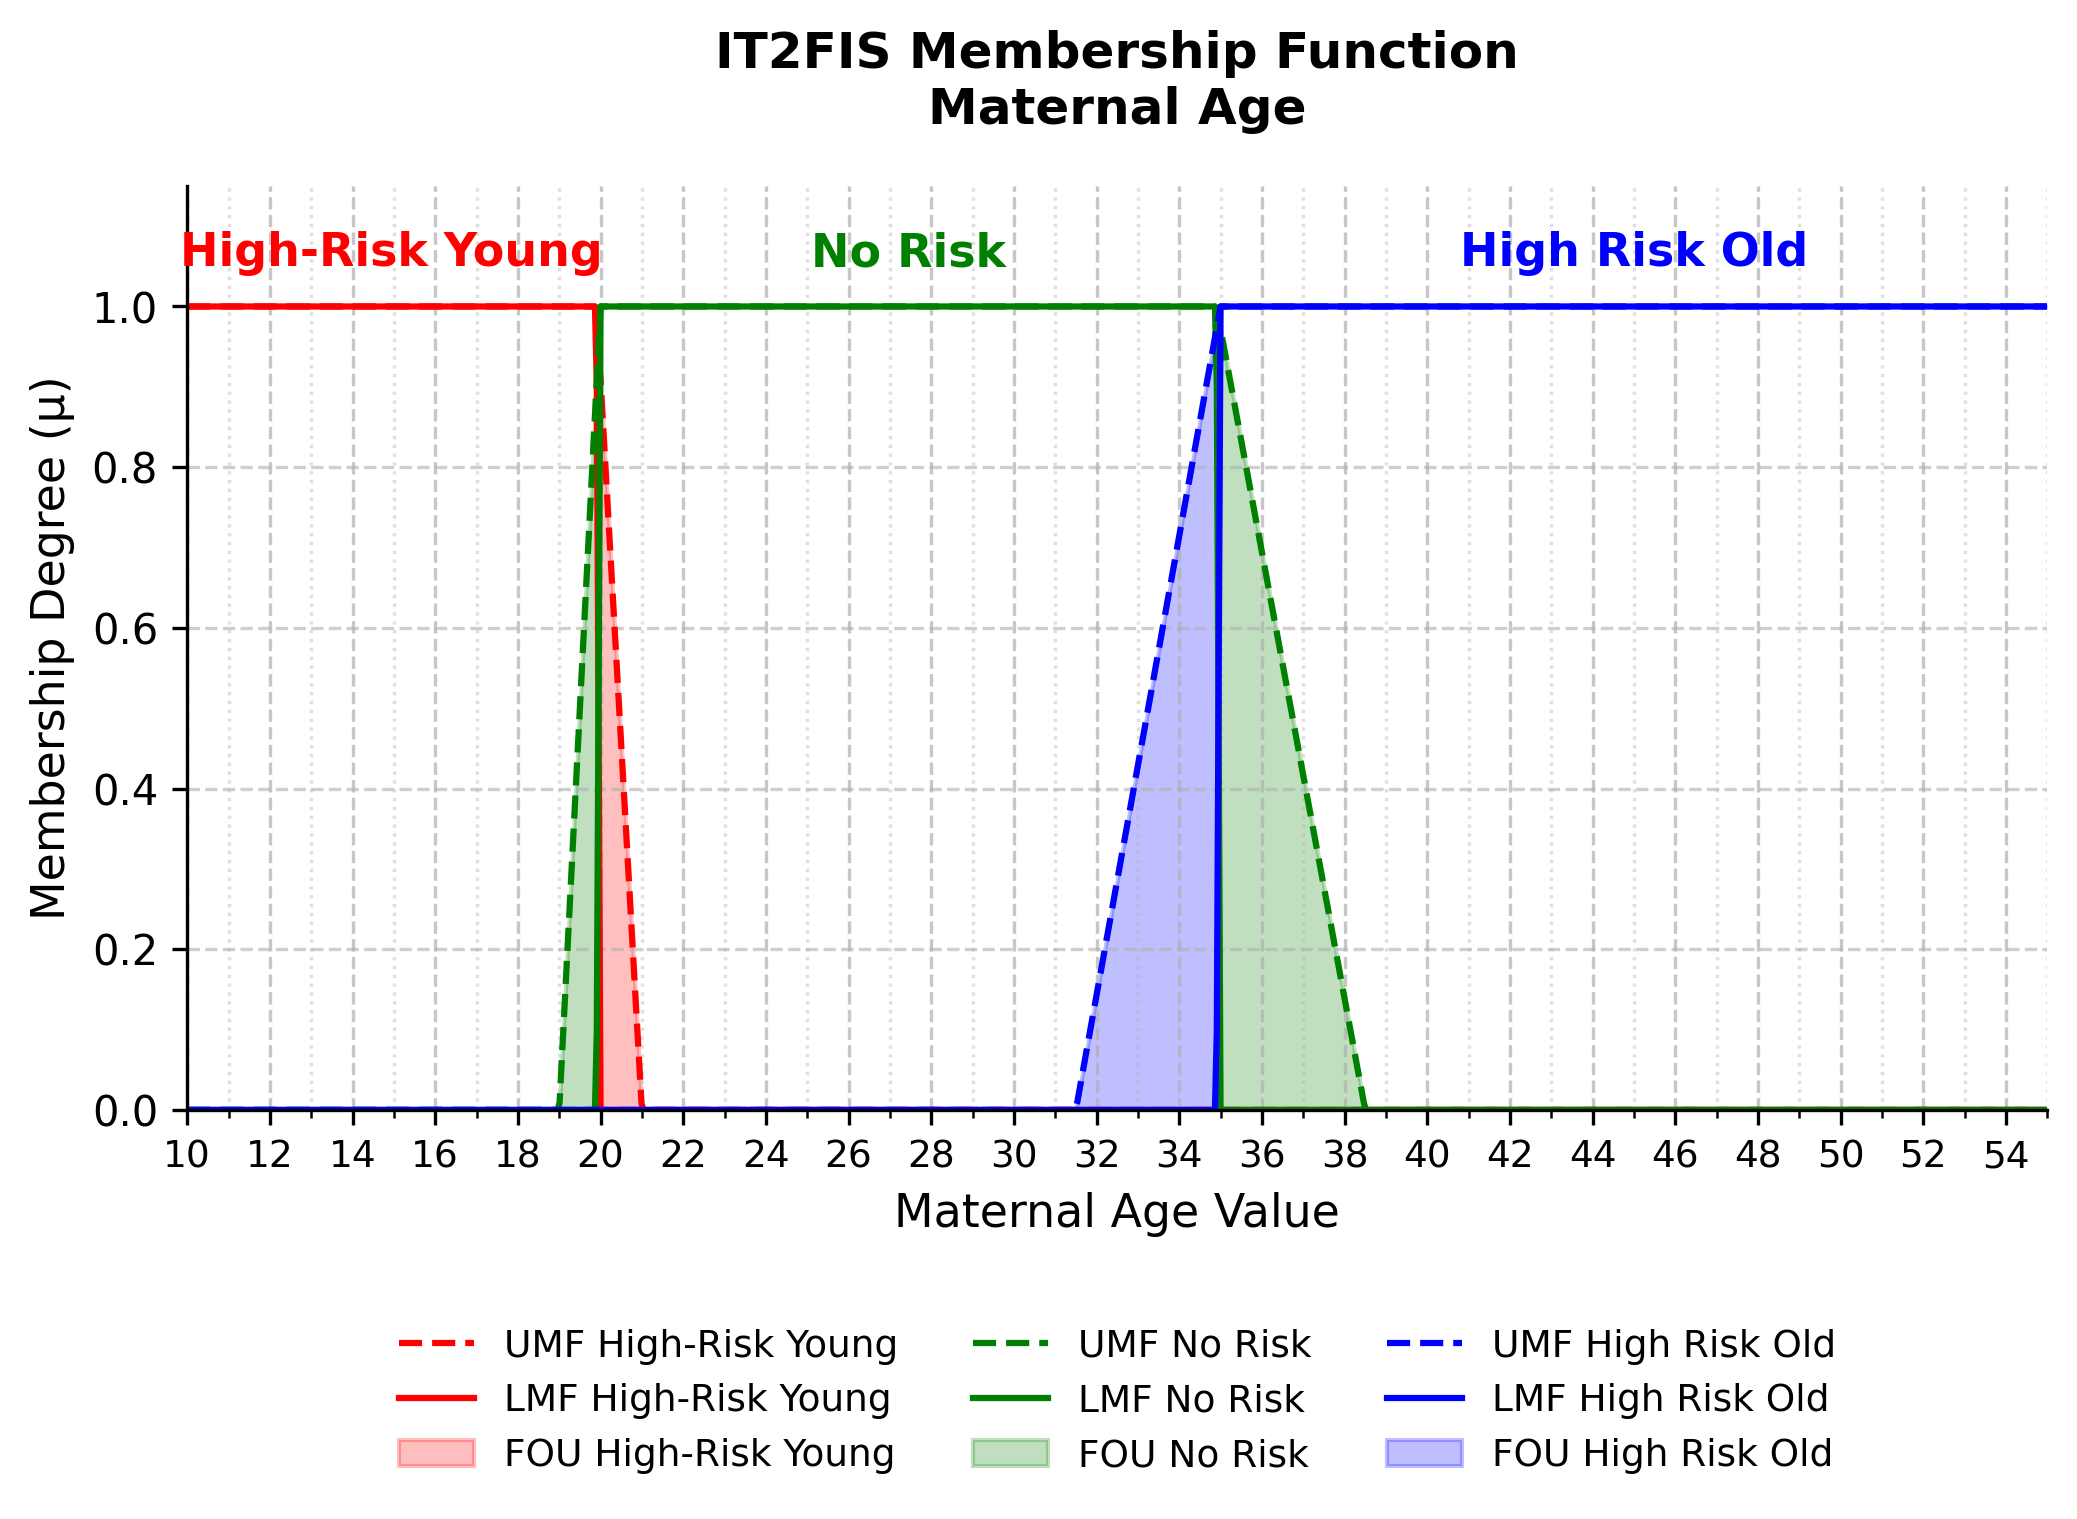

[*] Berhasil disimpan (300 DPI): D:\Skirpsi\images\Maternal_Age_Fuzzy.png




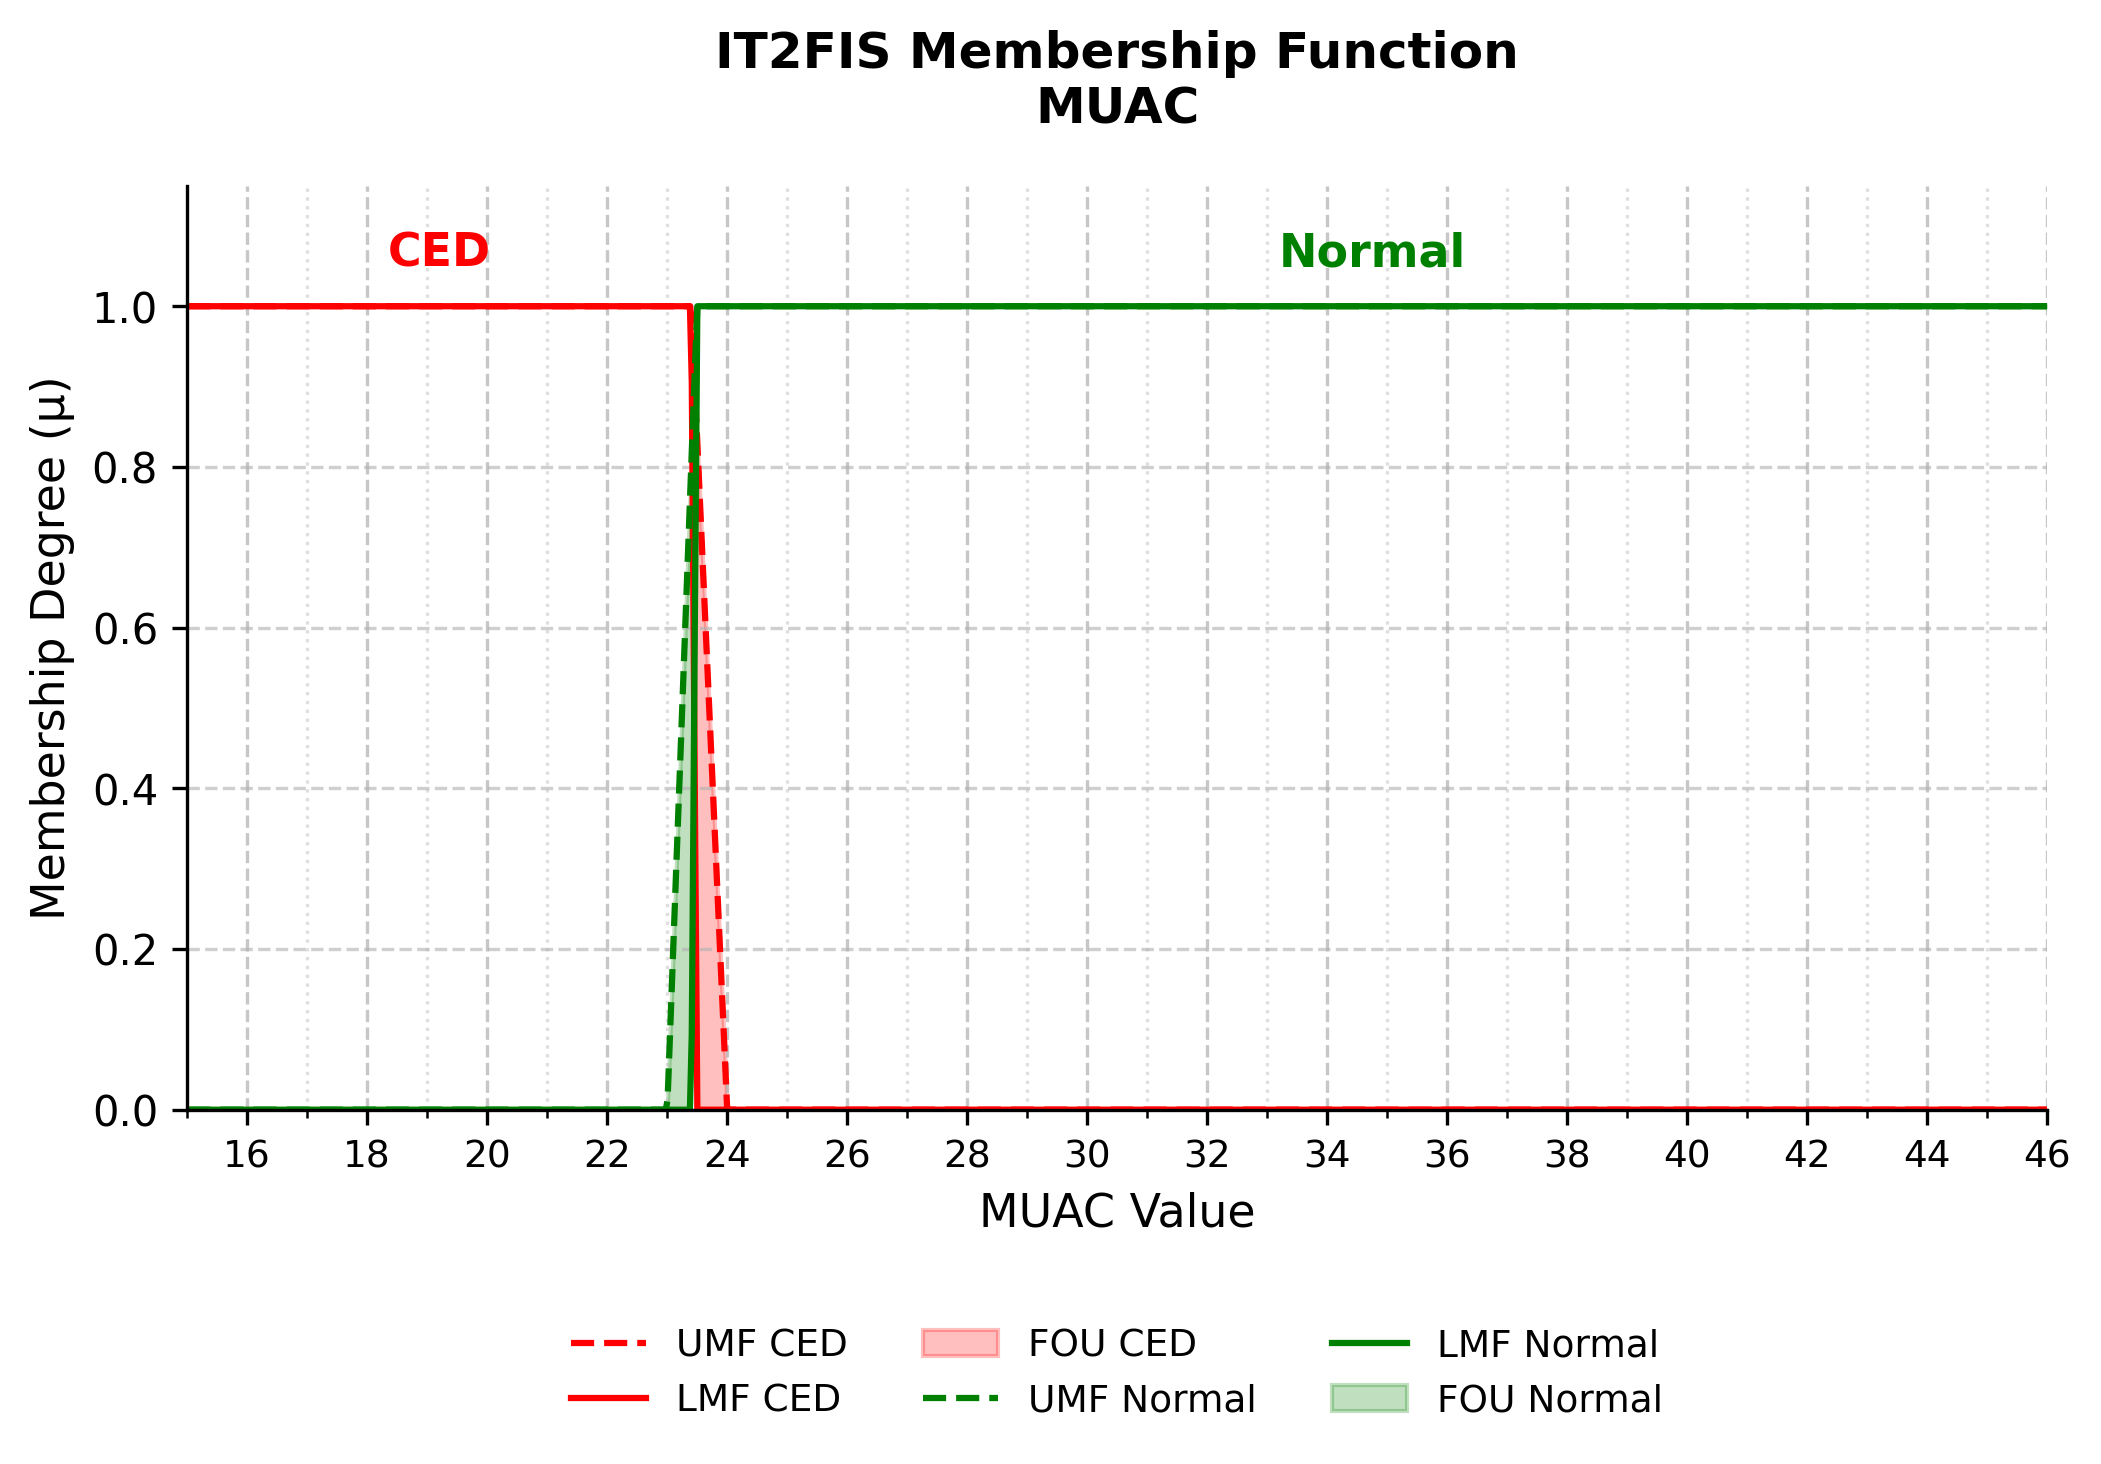

[*] Berhasil disimpan (300 DPI): D:\Skirpsi\images\MUAC_Fuzzy.png




In [32]:
PARAMETER_MF = {
    # A. MATERNAL AGE (USIA IBU)
    'Maternal Age': {
        'High-Risk Young': {'UMF': [10.0, 10.0, 19.9, 21.0],
                            'LMF': [10.0, 10.0, 19.9, 20.0]},
        'No Risk':         {'UMF': [19.0, 20.0, 34.9, 38.5],
                            'LMF': [19.9, 20.0, 34.9, 35.0]},
        'High Risk Old':   {'UMF': [31.5, 35.0, 55.0, 55.0],
                            'LMF': [34.9, 35.0, 55.0, 55.0]},
    },
    
    # B. MUAC / MID-UPPER ARM CIRCUMFERENCE (LINGKAR LENGAN ATAS)
    'MUAC': {
        'CED':    {'UMF': [15.0, 15.0, 23.4, 24.0], 
                   'LMF': [15.0, 15.0, 23.4, 23.5]},
        'Normal': {'UMF': [23.0, 23.5, 46.0, 46.0], 
                   'LMF': [23.4, 23.5, 46.0, 46.0]},
    }
}

colors = ['#FF0000', '#008000', '#0000FF', '#FFA500']

def calc_mf(x, params):
    a, b, c, d = params
    y = np.zeros_like(x)
    y[(x >= b) & (x <= c)] = 1.0

    mask_left = (x > a) & (x < b)
    if b != a: y[mask_left] = (x[mask_left] - a) / (b - a)
    else: y[x <= a] = 1.0

    mask_right = (x > c) & (x < d)
    if d != c: y[mask_right] = (d - x[mask_right]) / (d - c)
    else: y[x >= d] = 1.0

    return y

# ==============================================================================
# 2. GENERASI VISUALISASI GRAFIK IT2FIS (KUALITAS JURNAL - 300 DPI)
# ==============================================================================
for var_name, categories in PARAMETER_MF.items():
    # Set DPI awal menjadi 300 agar kanvas tajam
    plt.figure(figsize=(8, 4), dpi=300)

    all_vals = []
    for kat in categories.values():
        all_vals.extend(kat['UMF'])
    x_min, x_max = min(all_vals), max(all_vals)

    x = np.linspace(x_min, x_max, 1000)

    for i, (kat_name, params) in enumerate(categories.items()):
        c = colors[i % len(colors)]

        y_umf = calc_mf(x, params['UMF'])
        y_lmf = calc_mf(x, params['LMF'])
        y_lmf = np.minimum(y_lmf, y_umf)

        plt.plot(x, y_umf, color=c, linewidth=1.5, linestyle='--', label=f'UMF {kat_name}')
        plt.plot(x, y_lmf, color=c, linewidth=1.5, linestyle='-', label=f'LMF {kat_name}')
        plt.fill_between(x, y_lmf, y_umf, color=c, alpha=0.25, label=f'FOU {kat_name}')

        b_lmf, c_lmf = params['LMF'][1], params['LMF'][2]
        mid_point = (b_lmf + c_lmf) / 2
        if b_lmf == x_min: mid_point = x_min + (c_lmf - x_min)*0.5
        if c_lmf == x_max: mid_point = b_lmf + (x_max - b_lmf)*0.5
        plt.text(mid_point, 1.05, kat_name, color=c, fontweight='bold', fontsize=11, ha='center')

    # Transasi teks ke bahasa Inggris
    plt.title(f"IT2FIS Membership Function\n{var_name}", fontweight='bold', fontsize=12, pad=15)
    plt.xlabel(f"{var_name} Value", fontsize=11)
    plt.ylabel("Membership Degree (μ)", fontsize=11)

    plt.ylim(0, 1.15)
    plt.xlim(x_min, x_max)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    x_range = x_max - x_min
    if x_range <= 20:      
        step_major, step_minor = 1.0, 0.5
    elif x_range <= 50:    
        step_major, step_minor = 2.0, 1.0
    elif x_range <= 120:   
        step_major, step_minor = 10.0, 2.0
    else:                  
        step_major, step_minor = 50.0, 10.0

    ax.xaxis.set_major_locator(ticker.MultipleLocator(step_major))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(step_minor))

    plt.grid(axis='x', which='major', linestyle='--', alpha=0.7)
    plt.grid(axis='x', which='minor', linestyle=':', alpha=0.4) 
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.xticks(fontsize=9, rotation=0)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=9)

    folder_tujuan = r"D:\Skirpsi\images"
    
    if not os.path.exists(folder_tujuan):
        os.makedirs(folder_tujuan)
        
    nama_file = var_name.replace("/", "_").replace(" ", "_") + "_Fuzzy.png"
    
    path_lengkap = os.path.join(folder_tujuan, nama_file)
    
    # Save dengan DPI 300
    plt.savefig(path_lengkap, bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"[*] Berhasil disimpan (300 DPI): {path_lengkap}")
    print("\n" + "="*80 + "\n")

### 4.2 Fuzzifikasi IT2FLS dan Evaluasi Basis Aturan (Inferensi)
Pada tahap ini, nilai masukan pasien dipetakan ke dalam derajat keanggotaan atas ($\bar{\mu}$) dan derajat keanggotaan bawah ($\underline{\mu}$). Nilai fuzzifikasi gabungan (Hibrida Kontinu-Singleton) tersebut kemudian dievaluasi menggunakan **(MIN-MAX)** terhadap *Knowledge Base* yang terdiri dari 9 aturan kritis hasil penyaringan algoritma pohon keputusan.

In [33]:
# ==============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                  TAHAP 1 — FUZZIFIKASI HIBRIDA                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# ==============================================================================

# ASLI SEBELUM JARAK KEHAMILAN DIBENARKAN
# def trapesoid(x, a, b, c, d):
#     """Fungsi keanggotaan trapesoid [a, b, c, d]."""
#     if x <= a or x >= d:
#         return 0.0
#     elif b <= x <= c:
#         return 1.0
#     elif a < x < b:
#         return (x - a) / (b - a) if b != a else 1.0
#     else:  # c < x < d
#         return (d - x) / (d - c) if d != c else 0.0

def trapesoid(x, a, b, c, d):
    """
    Fungsi keanggotaan trapesoid [a, b, c, d].
    """
    # UBAH TANDA <= dan >= menjadi < dan > saja
    if x < a or x > d:
        return 0.0
    elif b <= x <= c:
        return 1.0
    elif a <= x < b:
        return (x - a) / (b - a) if b != a else 1.0
    else:  # c < x <= d
        return (d - x) / (d - c) if d != c else 0.0

def fuzzifikasi_it2(nilai_input, umf_params, lmf_params):
    """Fuzzifikasi untuk Variabel Kontinu IT2 (Input Angka)"""
    mu_umf = trapesoid(nilai_input, *umf_params)
    mu_lmf = trapesoid(nilai_input, *lmf_params)
    # Jaminan konsistensi IT2: UMF >= LMF
    mu_lmf = min(mu_lmf, mu_umf)  
    return round(mu_umf, 6), round(mu_lmf, 6)

def fuzzifikasi_variabel(nilai_input, definisi_kategori):
    return {
        nama_kat: fuzzifikasi_it2(nilai_input, params['UMF'], params['LMF'])
        for nama_kat, params in definisi_kategori.items()
    }

def fuzzifikasi_crisp(nilai_dropdown, daftar_kategori):
    """Fuzzifikasi Singleton untuk Variabel Crisp/Dropdown (Input Teks)"""
    hasil = {}
    for kat in daftar_kategori:
        if kat == nilai_dropdown:
            hasil[kat] = (1.0, 1.0)  # Mutlak 100% Aktif jika terpilih
        else:
            hasil[kat] = (0.0, 0.0)  # Mutlak 0% Tidak Aktif jika tidak terpilih
    return hasil

# === ASLIII SEBELUM DITAMBHAKAN ASUMSI ====
# def fuzzifikasi_semua(input_pasien):
#     """Fuzzifikasi gabungan memproses variabel IT2 dan Singleton secara dinamis."""
#     hasil_akhir = {}
#     for nama_var, nilai in input_pasien.items():
#         if nama_var in PARAMETER_MF:
#             hasil_akhir[nama_var] = fuzzifikasi_variabel(nilai, PARAMETER_MF[nama_var])
#         elif nama_var in PARAMETER_CRISP:
#             hasil_akhir[nama_var] = fuzzifikasi_crisp(nilai, PARAMETER_CRISP[nama_var])
#     return hasil_akhir

def fuzzifikasi_semua(input_pasien):
    """Fuzzifikasi gabungan: Memproses variabel IT2 dan Singleton."""

    # =========================================================================
    # ASUMSI LOGIKA PRIMIGRAVIDA (ANAK PERTAMA)
    # =========================================================================
    # Cek apakah pasien Primigravida menggunakan .get() agar terhindar dari error
    if input_pasien.get('ibu_Kehamilan Ke-') == 'Primigravida':
        # Mengasumsikan jarak kehamilan menjadi 36 bulan (Masuk kurva Tidak Berisiko)
        input_pasien['jarak_kehamilan_bulan'] = 36.0
    # =========================================================================

    hasil_akhir = {}

    for nama_var, nilai in input_pasien.items():
        # 1. Jika ini variabel Fuzzy (Input berupa Angka)
        if nama_var in PARAMETER_MF:
            hasil_akhir[nama_var] = fuzzifikasi_variabel(nilai, PARAMETER_MF[nama_var])

        # 2. Jika ini variabel Crisp (Input berupa Pilihan Dropdown)
        elif nama_var in PARAMETER_CRISP:
            hasil_akhir[nama_var] = fuzzifikasi_crisp(nilai, PARAMETER_CRISP[nama_var])

    return hasil_akhir

# ------------------------------------------------------------------------------
# KAMUS PARAMETER DISKRIT (CRISP / SINGLETON)
# ------------------------------------------------------------------------------
PARAMETER_CRISP = {
    'kunjungan_anc_total':         ['Tidak Lengkap', 'Lengkap'],
    'ibu_Kehamilan Ke-':           ['Primigravida', 'Multigravida', 'Grandemultipara'],
    'ibu_statusImunisasi_encoded': ['TT Tidak Lengkap', 'TT Lengkap'],
    'ibu_proteinUrin':             ['Positif', 'Negatif']
}

# ------------------------------------------------------------------------------
# KAMUS PARAMETER KONTINU (IT2FLS UMF & LMF)
# ------------------------------------------------------------------------------
PARAMETER_MF = {
    # A. LINGKAR LENGAN ATAS (LILA)
    'LILA_angka': {
        'KEK':    {'UMF': [15.0, 15.0, 23.4, 24.0], 'LMF': [15.0, 15.0, 23.4, 23.5]},
        'Normal': {'UMF': [23.0, 23.5, 46.0, 46.0], 'LMF': [23.4, 23.5, 46.0, 46.0]},
    },
    # B. JARAK KEHAMILAN
    'jarak_kehamilan_bulan': {
        'Berisiko Dekat': {'UMF': [0.0, 0.0, 23.0, 26.0],
                            'LMF': [0.0, 0.0, 23.0, 24.0]},
        'Tidak Berisiko': {'UMF': [21.0, 24.0, 60.0, 63.0],
                            'LMF': [23.0, 24.0, 60.0, 61.0]},
        'Berisiko Jauh':  {'UMF': [54.0, 61.0, 250.0, 250.0],
                            'LMF': [60.0, 61.0, 250.0, 250.0]},
    },

    # C. INDEKS MASSA TUBUH (IMT)
    'ibu_IMT': {
        'BB Kurang': {'UMF': [10.0, 10.0, 18.4, 19.0],
                        'LMF': [10.0, 10.0, 18.4, 18.5]},
        'BB Normal': {'UMF': [18.0, 18.5, 24.9, 25.5],
                        'LMF': [18.4, 18.5, 24.9, 25.0]},
        'BB Lebih':  {'UMF': [24.5, 25.0, 29.9, 30.5],
                        'LMF': [24.9, 25.0, 29.9, 30.0]},
        'Obesitas':  {'UMF': [29.5, 30.0, 50.0, 50.0],
                        'LMF': [29.9, 30.0, 50.0, 50.0]},
    },

    # D. HEMOGLOBIN (Hb)
    'ibu_Hb': {
        'Anemia':       {'UMF': [3.0,   3.0,  10.9, 11.5],
                        'LMF': [3.0,   3.0, 10.9, 11.0]},
        'Tidak Anemia': {'UMF': [10.5, 11.0, 20.0, 20.0],
                        'LMF': [10.9, 11.0, 20.0, 20.0]},
    },

    # E. GULA DARAH
    'ibu_gulaDarah': {
        'Normal': {'UMF': [40.0,  40.0, 99.0, 120.0],
                    'LMF': [40.0,  40.0,  99.0, 100.0]},
        'Tinggi': {'UMF': [80.0, 100.0, 450.0, 450.0],
                    'LMF': [99.0, 100.0, 450.0, 450.0]},
    },

    # F. USIA IBU
    'ibu_Usia Ibu': {
        'Berisiko Muda':  {'UMF': [10.0, 10.0, 19.9, 21.0],
                            'LMF': [10.0, 10.0, 19.9, 20.0]},
        'Tidak Berisiko': {'UMF': [19.0, 20.0, 34.9, 38.5],
                            'LMF': [19.9, 20.0, 34.9, 35.0]},
        'Berisiko Tua':   {'UMF': [31.5, 35.0, 55.0, 55.0],
                            'LMF': [34.9, 35.0, 55.0, 55.0]},
    },
}

# ==============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                  TAHAP 2 — INFERENSI KNOWLEDGE BASE                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# ==============================================================================

# Memanggil knowledge basea dari modul eksternal
from knowledge_base_rules import KNOWLEDGE_BASE

print(f"✓ Berhasil mengimpor {len(KNOWLEDGE_BASE)} aturan dari 'knowledge_base_rules.py'")

# ------------------------------------------------------------------------------
# FUNGSI EVALUASI INTERVAL FIRING STRENGTH (MAMDANI INFERENCE ENGINE)
# ------------------------------------------------------------------------------
def ambil_mu_antecedent(hasil_fuzzifikasi, variabel, kategori_list):
    if variabel not in hasil_fuzzifikasi: return 0.0, 0.0
    hasil_var = hasil_fuzzifikasi[variabel]
    mu_umf_list, mu_lmf_list = [], []

    for kat in kategori_list:
        if kat in hasil_var:
            mu_umf, mu_lmf = hasil_var[kat]
            mu_umf_list.append(mu_umf); mu_lmf_list.append(mu_lmf)

    if not mu_umf_list: return 0.0, 0.0
    return max(mu_umf_list), max(mu_lmf_list) # Operator MAX untuk relasi logika OR

def hitung_firing_interval(rule, hasil_fuzzifikasi):
    mu_umf_list, mu_lmf_list, detail = [], [], []
    for ant in rule['antecedent']:
        mu_umf, mu_lmf = ambil_mu_antecedent(hasil_fuzzifikasi, ant['variabel'], ant['kategori'])
        mu_umf_list.append(mu_umf); mu_lmf_list.append(mu_lmf)
        detail.append({
            'variabel': ant['variabel'], 'kategori': ant['kategori'],
            'mu_umf': round(mu_umf, 4), 'mu_lmf': round(mu_lmf, 4)
        })

    # Operator MIN (T-Norm) untuk relasi logika AND pada sistem Mamdani
    w_upper = round(min(mu_umf_list), 6) if mu_umf_list else 0.0
    w_lower = round(min(mu_lmf_list), 6) if mu_lmf_list else 0.0
    w_lower = min(w_lower, w_upper) # Jaminan keamanan interval
    return w_upper, w_lower, detail

def inferensi_it2(hasil_fuzzifikasi):
    hasil = []
    for rule in KNOWLEDGE_BASE:
        w_upper, w_lower, detail = hitung_firing_interval(rule, hasil_fuzzifikasi)
        hasil.append({
            'rule_id': rule['rule_id'], 'prediksi': rule['prediksi'],
            'w_upper': w_upper, 'w_lower': w_lower, 'aktif': w_upper > 0, 'detail': detail
        })
    return hasil

print("✓ Mesin Fuzzifikasi Hibrida & Basis Aturan Inferensi berhasil dimuat ke dalam memori.")

✓ Berhasil mengimpor 19 aturan dari 'knowledge_base_rules.py'
✓ Mesin Fuzzifikasi Hibrida & Basis Aturan Inferensi berhasil dimuat ke dalam memori.


### 4.3 Fusi Informasi Dempster-Shafer dan Pengambilan Keputusan Akhir
*Firing strength* interval dari aturan yang aktif dipetakan menjadi fungsi massa probabilitas dasar (*Basic Probability Assignment* / BPA). Fusi informasi dilakukan secara berulang menggunakan **Aturan Kombinasi Dempster** untuk mengeliminasi konflik bukti ($K$). Keputusan diagnosis akhir ditentukan dari perbandingan nilai *Belief* dan *Plausibility* tertinggi, divalidasi dengan batas aman selisih keyakinan (*Belief Difference Threshold*).

In [34]:
# ==============================================================================
# TAHAP 3 — DEMPSTER-SHAFER (EVIDENCE THEORY)
#
# Input  : firing interval [w_lower, w_upper] dari setiap rule aktif (Tahap 2)
# Output : Belief dan Plausibility untuk hipotesis BBLR dan Normal
#          → Keputusan akhir berdasarkan Belief tertinggi
#
# Frame of Discernment: Θ = {BBLR, Normal}
# ==============================================================================

# ==============================================================================
# LANGKAH 1 — KONVERSI FIRING INTERVAL → BPA (DENGAN SOFT CONFLICT)
# ==============================================================================
def firing_ke_bpa(rule_id, prediksi, w_upper, w_lower):
    """
    Mengubah firing interval [w_lower, w_upper] menjadi BPA (mass function).
    Dilengkapi penanganan Zadeh's Paradox (Soft Conflict / Discounting).
    """
    lawan = 'NORMAL' if prediksi == 'BBLR' else 'BBLR'

    # Membatasi keyakinan maksimal menjadi 99.99% (0.9999)
    # Memaksa sistem menyisakan minimal 0.01% untuk ketidakpastian (Ignorance)
    w_upper = min(w_upper, 0.9999)
    w_lower = min(w_lower, w_upper)

    # Menghitung massa (BPA)
    m_hipotesis = round(w_lower, 6)                    # m({θ_k})
    m_ignorance = round(w_upper - w_lower, 6)          # m({Θ})
    m_lawan     = round(1.0 - w_upper, 6)              # m({θ_k^c})

    # Pastikan total massa = 1 (toleransi floating point error)
    total = m_hipotesis + m_ignorance + m_lawan
    if abs(total - 1.0) > 1e-9:
        m_ignorance = round(1.0 - m_hipotesis - m_lawan, 6)

    bpa = {
        prediksi : m_hipotesis,
        lawan    : m_lawan,
        'THETA'  : m_ignorance,   # Θ = {BBLR, Normal} = ignorance
    }
    return bpa


# ==============================================================================
# LANGKAH 2 — KOMBINASI BPA (DEMPSTER'S RULE OF COMBINATION)
# ==============================================================================
def kombinasi_dua_bpa(m1, m2):
    """
    Menggabungkan dua BPA menggunakan Dempster's Rule of Combination.
    """
    # Hitung koefisien konflik K (BBLR ∩ NORMAL = ∅)
    K = m1['BBLR'] * m2['NORMAL'] + m1['NORMAL'] * m2['BBLR']
    K = round(K, 10)

    if K >= 1.0:
        raise ValueError(f"Konflik total (K={K}). Semua evidensi saling bertentangan secara mutlak.")

    normalisasi = 1.0 / (1.0 - K)

    # Hitung massa gabungan untuk setiap himpunan
    m12_bblr = normalisasi * (
        m1['BBLR']  * m2['BBLR']  +   # BBLR  ∩ BBLR  = BBLR
        m1['BBLR']  * m2['THETA'] +   # BBLR  ∩ THETA = BBLR
        m1['THETA'] * m2['BBLR']      # THETA ∩ BBLR  = BBLR
    )

    m12_normal = normalisasi * (
        m1['NORMAL'] * m2['NORMAL'] +  # NORMAL ∩ NORMAL = NORMAL
        m1['NORMAL'] * m2['THETA']  +  # NORMAL ∩ THETA  = NORMAL
        m1['THETA']  * m2['NORMAL']    # THETA  ∩ NORMAL = NORMAL
    )

    m12_theta = normalisasi * (
        m1['THETA'] * m2['THETA']      # THETA ∩ THETA = THETA
    )

    # PERBAIKAN: NORMALISASI ULANG ANTI-FLOATING POINT ERROR
    total_sementara = m12_bblr + m12_normal + m12_theta

    m12 = {
        'BBLR'  : round(m12_bblr / total_sementara, 8),
        'NORMAL': round(m12_normal / total_sementara, 8),
        'THETA' : round(m12_theta / total_sementara, 8),
    }

    return m12, round(K, 8)


def kombinasi_semua_bpa(list_bpa):
    """
    Menggabungkan semua BPA dari rules aktif secara bertahap (m1 ⊕ m2 ⊕ m3...).
    """
    if len(list_bpa) == 0:
        return None, []

    # PENANGKAL ERROR (JIKA HANYA ADA 1 RULE AKTIF)
    if len(list_bpa) == 1:
        return list_bpa[0], [0.0]

    bpa_saat_ini = list_bpa[0]
    list_K = []

    for i in range(1, len(list_bpa)):
        bpa_saat_ini, K = kombinasi_dua_bpa(bpa_saat_ini, list_bpa[i])
        list_K.append(K)

    return bpa_saat_ini, list_K


# ==============================================================================
# LANGKAH 3 — HITUNG BELIEF DAN PLAUSIBILITY
# ==============================================================================
def hitung_belief_plausibility(bpa_final):
    """
    Menghitung Belief dan Plausibility dari BPA final.
    """
    m_bblr   = bpa_final['BBLR']
    m_normal = bpa_final['NORMAL']
    m_theta  = bpa_final['THETA']

    return {
        'Bel_BBLR'  : round(m_bblr, 6),                     # Bel({BBLR})
        'Pls_BBLR'  : round(m_bblr + m_theta, 6),           # Pls({BBLR})
        'Bel_Normal': round(m_normal, 6),                   # Bel({Normal})
        'Pls_Normal': round(m_normal + m_theta, 6),         # Pls({Normal})
        'Ignorance' : round(m_theta, 6),
    }


# ==============================================================================
# LANGKAH 4 — KEPUTUSAN AKHIR
# ==============================================================================
def keputusan_akhir(hasil_bp):
    """
    Menentukan diagnosis akhir murni berdasarkan perhitungan Dempster-Shafer.
    Jika terjadi seri mutlak, sistem akan jujur menyatakan Tidak Dapat Ditentukan.
    """
    # 1. Cek Belief (Keyakinan Mutlak) terlebih dahulu
    if hasil_bp['Bel_BBLR'] > hasil_bp['Bel_Normal']:
        diagnosis = 'BBLR'
    elif hasil_bp['Bel_Normal'] > hasil_bp['Bel_BBLR']:
        diagnosis = 'NORMAL'

    # 2. Jika Belief SERI, gunakan Plausibility (Peluang Maksimal)
    else:
        if hasil_bp['Pls_BBLR'] > hasil_bp['Pls_Normal']:
            diagnosis = 'BBLR'
        elif hasil_bp['Pls_Normal'] > hasil_bp['Pls_BBLR']:
            diagnosis = 'NORMAL'

        # 3. HASIL MURNI MATEMATIS (SERI SEMPURNA)
        else:
            # Sistem tidak mengambil asumsi apa pun
            diagnosis = 'Tidak Dapat Ditentukan'

    return {
        'diagnosis'  : diagnosis,
        'bel_bblr'   : hasil_bp['Bel_BBLR'],
        'pls_bblr'   : hasil_bp['Pls_BBLR'],
        'bel_normal' : hasil_bp['Bel_Normal'],
        'pls_normal' : hasil_bp['Pls_Normal'],
        'ignorance'  : hasil_bp['Ignorance'],
    }


# ==============================================================================
# FUNGSI UTAMA TAHAP 3
# ==============================================================================
def dempster_shafer(hasil_inferensi):
    rules_aktif = [r for r in hasil_inferensi if r['aktif']]

    if not rules_aktif:
        return {'error' : 'Tidak ada rule yang aktif. Keputusan: TIDAK DAPAT DITENTUKAN'}

    # 1. Konversi
    list_bpa, bpa_per_rule = [], []
    for r in rules_aktif:
        bpa = firing_ke_bpa(r['rule_id'], r['prediksi'], r['w_upper'], r['w_lower'])
        list_bpa.append(bpa)
        bpa_per_rule.append({
            'rule_id' : r['rule_id'], 'prediksi': r['prediksi'],
            'w_upper' : r['w_upper'], 'w_lower' : r['w_lower'], 'bpa': bpa,
        })

    # 2. Kombinasi
    bpa_final, list_K = kombinasi_semua_bpa(list_bpa)

    # 3. Belief & Plausibility
    hasil_bp = hitung_belief_plausibility(bpa_final)

    # 4. Keputusan
    keputusan = keputusan_akhir(hasil_bp)

    return {
        'bpa_per_rule' : bpa_per_rule,
        'bpa_final'    : bpa_final,
        'koefisien_K'  : list_K,
        'belief_plaus' : hasil_bp,
        'keputusan'    : keputusan,
    }

### 4.4 Pengujian Manual

In [35]:
# ==============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║             EKSEKUSI PENGUJIAN INTEGRASI FINAL SISTEM                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# ==============================================================================
if __name__ == '__main__':

    # 1. DEKLARASI INPUT PASIEN
    # INPUT_PASIEN = {
    #     'ibu_Usia Ibu'                : 19,
    #     'ibu_Hb'                      : 8.5,
    #     'jarak_kehamilan_bulan'       : 36,
    #     'ibu_IMT'                     : 19.02,
    #     'LILA_angka'                  : 22.3,
    #     'ibu_gulaDarah'               : 85,
    #     'kunjungan_anc_total'         : 'Tidak Lengkap',
    #     'ibu_Kehamilan Ke-'           : 'Primigravida',
    #     'ibu_statusImunisasi_encoded' : 'TT Tidak Lengkap',
    #     'ibu_proteinUrin'             : 'Negatif',
    # }
    # # input yang menghasilkan tidak dapat ditentukan
    INPUT_PASIEN = {
        'ibu_Usia Ibu'                : 24,
        'ibu_Hb'                      : 12.5,
        'jarak_kehamilan_bulan'       : 36,
        'ibu_IMT'                     : 26.84,
        'LILA_angka'                  : 23,
        'ibu_gulaDarah'               : 85,
        'kunjungan_anc_total'         : 'Tidak Lengkap',
        'ibu_Kehamilan Ke-'           : 'Primigravida',
        'ibu_statusImunisasi_encoded' : 'TT Lengkap',
        'ibu_proteinUrin'             : 'Negatif',
    }

    print("=" * 70)
    print("SISTEM PAKAR BBLR — IT2FIS + DEMPSTER-SHAFER")
    print("=" * 70)

    # ------------------------------------------------------------------
    # EKSEKUSI TAHAP 1 — Fuzzifikasi
    # ------------------------------------------------------------------
    print("\nTAHAP 1 — FUZZIFIKASI IT2 & CRISP")
    print("-" * 70)

    hasil_fuzzifikasi = fuzzifikasi_semua(INPUT_PASIEN)

    for nama_var, hasil_kat in hasil_fuzzifikasi.items():
        nilai = INPUT_PASIEN[nama_var]
        print(f"\n  {nama_var} = {nilai}")
        print(f"  {'Kategori':<22} {'μ_LMF':>8}  {'μ_UMF':>8}  Aktif?")
        print(f"  {'-'*50}")
        for kat, (mu_umf, mu_lmf) in hasil_kat.items():
            aktif = '✓' if mu_umf > 0 else '-'
            print(f"  {kat:<22} {mu_lmf:>8.4f}  {mu_umf:>8.4f}  {aktif}")

    # ------------------------------------------------------------------
    # EKSEKUSI TAHAP 2 — Inferensi
    # ------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("TAHAP 2 — INFERENSI IT2")
    print("-" * 70)

    hasil_inferensi = inferensi_it2(hasil_fuzzifikasi)
    rules_aktif = [r for r in hasil_inferensi if r['aktif']]
    
    print(f"\n  Total rules aktif : {len(rules_aktif)} dari {len(hasil_inferensi)}")

    for r in rules_aktif:
        print(f"\n  Rule {r['rule_id']:>2} | {r['prediksi']:<8} "
              f"| Firing=[{r['w_lower']:.4f}, {r['w_upper']:.4f}]")
        for d in r['detail']:
            kat_str = ' / '.join(d['kategori'])
            print(f"           • {d['variabel']:<35} "
                  f"μ=[{d['mu_lmf']:.4f}, {d['mu_umf']:.4f}]  ← {kat_str}")

    # ------------------------------------------------------------------
    # EKSEKUSI TAHAP 3 — Dempster-Shafer & Keputusan Akhir
    # ------------------------------------------------------------------
    hasil_ds = dempster_shafer(hasil_inferensi)

    if 'error' in hasil_ds:
        print(f"\n⚠ {hasil_ds['error']}")
    else:
        print("\n" + "=" * 70)
        print("TAHAP 3 — DEMPSTER-SHAFER")
        print("=" * 70)

        # BPA per rule
        print("\n  [Langkah 1] BPA per rule (Persamaan 2.12):")
        print(f"  {'Rule':<8} {'Prediksi':<10} {'Firing [lo,hi]':<18} {'m({θ})':<16} {'m({Θ})':<14} {'m({θ^c})':<14}")
        print(f"  {'-'*80}")
        for item in hasil_ds['bpa_per_rule']:
            b, pred = item['bpa'], item['prediksi']
            lawan = 'NORMAL' if pred == 'BBLR' else 'BBLR'
            print(f"  Rule {item['rule_id']:<3} {pred:<10} [{item['w_lower']:.4f}, {item['w_upper']:.4f}]   "
                  f"m({pred})={b[pred]:.4f}   m(Θ)={b['THETA']:.4f}   m({lawan})={b[lawan]:.4f}")

        # Koefisien konflik
        if hasil_ds['koefisien_K']:
            print("\n  [Langkah 2] Koefisien konflik K (Persamaan 2.14):")
            for i, K in enumerate(hasil_ds['koefisien_K'], start=1):
                konflik_info = '(tidak ada konflik)' if K == 0 else f'(normalisasi: 1/(1-K) = {1/(1-K):.4f})'
                print(f"    Kombinasi ke-{i}: K = {K:.6f}  {konflik_info}")

        # BPA final
        bf = hasil_ds['bpa_final']
        print(f"\n  [Langkah 2] BPA final setelah kombinasi (Persamaan 2.13):")
        print(f"    m({{BBLR}})   = {bf['BBLR']:.6f}")
        print(f"    m({{Normal}}) = {bf['NORMAL']:.6f}")
        print(f"    m({{Θ}})      = {bf['THETA']:.6f}  (ignorance)")

        # Belief & Plausibility
        bp = hasil_ds['belief_plaus']
        print(f"\n  [Langkah 3] Belief & Plausibility (Persamaan 2.15-2.16):")
        print(f"    Bel(BBLR)   = {bp['Bel_BBLR']:.4f}   Pls(BBLR)   = {bp['Pls_BBLR']:.4f}")
        print(f"    Bel(Normal) = {bp['Bel_Normal']:.4f}   Pls(Normal) = {bp['Pls_Normal']:.4f}")

        # Keputusan akhir
        kep = hasil_ds['keputusan']
        print("\n" + "=" * 70)
        print("KEPUTUSAN AKHIR (PERBANDINGAN)")
        print("=" * 70)
        print(f"\n  Diagnosis Akhir    : {kep['diagnosis']} (Nilai Keyakinan Tertinggi)")
        print("-" * 70)
        print(f"  Keyakinan (BBLR)   : {kep['bel_bblr']*100:>6.2f}%  |  Plausibility: {kep['pls_bblr']*100:.2f}%")
        print(f"  Keyakinan (NORMAL) : {kep['bel_normal']*100:>6.2f}%  |  Plausibility: {kep['pls_normal']*100:.2f}%")
        print("-" * 70)

        # Selisih dihitung manual di sini (karena tidak ada di dalam return fungsi asli)
        selisih = abs(kep['bel_bblr'] - kep['bel_normal']) * 100
        print(f"  Selisih Keyakinan  : {selisih:.2f}%")
        print(f"  Ignorance (Θ)      : {kep['ignorance']*100:.2f}%  (Ketidakpastian/Blank Spot Sistem)")
        print("=" * 70)

SISTEM PAKAR BBLR — IT2FIS + DEMPSTER-SHAFER

TAHAP 1 — FUZZIFIKASI IT2 & CRISP
----------------------------------------------------------------------

  ibu_Usia Ibu = 24
  Kategori                  μ_LMF     μ_UMF  Aktif?
  --------------------------------------------------
  Berisiko Muda            0.0000    0.0000  -
  Tidak Berisiko           1.0000    1.0000  ✓
  Berisiko Tua             0.0000    0.0000  -

  ibu_Hb = 12.5
  Kategori                  μ_LMF     μ_UMF  Aktif?
  --------------------------------------------------
  Anemia                   0.0000    0.0000  -
  Tidak Anemia             1.0000    1.0000  ✓

  jarak_kehamilan_bulan = 36.0
  Kategori                  μ_LMF     μ_UMF  Aktif?
  --------------------------------------------------
  Berisiko Dekat           0.0000    0.0000  -
  Tidak Berisiko           1.0000    1.0000  ✓
  Berisiko Jauh            0.0000    0.0000  -

  ibu_IMT = 26.84
  Kategori                  μ_LMF     μ_UMF  Aktif?
  ---------------

In [36]:
print(f"Jumlah rule dalam knowledge base: {len(KNOWLEDGE_BASE)}")

Jumlah rule dalam knowledge base: 19


### 4.5 Pengujian Keseluruhan Data

In [37]:
# ==============================================================================
# 1. BACA FILE DATA EXCEL DARI GOOGLE COLAB
# ==============================================================================
# Mengambil file testing
file_path = 'D:\\Skirpsi\\dataset\\4NewData_Ibu_Hamil_FINAL_CLEAN.xlsx' 

# Membaca isi file
df_pasien = pd.read_excel(file_path)


# ==============================================================================
# 2. FUNGSI RUMUS IMT RIIL
# ==============================================================================
def hitung_imt_otomatis(bb_kg, tb_cm):
    """Menghitung nilai IMT mentah dari Berat dan Tinggi Badan."""
    try:
        tb_m = tb_cm / 100.0
        return round(bb_kg / (tb_m ** 2), 2)
    except ZeroDivisionError:
        return 22.0

# ==============================================================================
# 3. TRANSLATOR KATEGORIKAL (Untuk variabel masukan teks/diskrit)
# ==============================================================================
def decode_kehamilan(val):
    return 'Primigravida' if val == 1 else ('Multigravida' if 2 <= val <= 4 else 'Grandemultipara')

def decode_anc(val):
    return 'Lengkap' if val >= 6 else 'Tidak Lengkap'

def decode_imunisasi(val):
    return 'TT Tidak Lengkap' if val <= 1 else 'TT Lengkap'

def decode_protein(val):
    return 'Positif' if val == 1 else 'Negatif'

# ==============================================================================
# 4. TRANSLATOR NUMERIK FISIOLOGIS (Mengubah Kode Lab ke Angka Rujukan)
# ==============================================================================
def konversi_numerik_hb(encoded_val):
    mapping_hb = {0: 12.5, 1: 10.5, 2: 8.5, 3: 6.0}
    return mapping_hb.get(encoded_val, 12.5)

def konversi_numerik_gula(encoded_val):
    return 120.0 if encoded_val == 1 else 85.0

# ==============================================================================
# 5. EKSEKUSI BATCH TESTING PADA INTI SISTEM
# ==============================================================================
hasil_kolektif = []
total_data = len(df_pasien)
print(f"=== Memulai Pengujian Massal untuk {total_data} Data Pasien ===\n")

for index, row in df_pasien.iterrows():
    angka_imt = hitung_imt_otomatis(float(row['ibu_BB']), float(row['ibu_TB']))

    input_pasien = {
        'ibu_Usia Ibu'                : float(row['ibu_Usia Ibu']),
        'ibu_Hb'                      : konversi_numerik_hb(row['ibu_Hb_encoded']),
        'jarak_kehamilan_bulan'       : float(row['jarak_kehamilan_bulan']),
        'ibu_IMT'                     : angka_imt,
        'LILA_angka'                  : float(row['LILA_angka']),
        'ibu_gulaDarah'               : konversi_numerik_gula(row['ibu_gulaDarah_encoded']),

        'kunjungan_anc_total'         : decode_anc(row['kunjungan_anc_total']),
        'ibu_Kehamilan Ke-'           : decode_kehamilan(row['ibu_Kehamilan Ke-']),
        'ibu_statusImunisasi_encoded' : decode_imunisasi(row['ibu_statusImunisasi_encoded']),
        'ibu_proteinUrin'             : decode_protein(row['ibu_proteinUrin_encoded']),
    }

    try:
        # --- MEMANGGIL FUNGSI ASLI SISTEM PAKAR ---
        hasil_fuzz      = fuzzifikasi_semua(input_pasien)
        hasil_inferensi = inferensi_it2(hasil_fuzz)
        hasil_ds        = dempster_shafer(hasil_inferensi)

        # --- EKSTRAKSI BERSIH, AMAN, DAN PRESISI ---
        diagnosis_sistem = ""
        belief_bblr      = 0.0
        belief_normal    = 0.0

        if isinstance(hasil_ds, dict):
            if 'keputusan' in hasil_ds:
                sub_keputusan    = hasil_ds['keputusan']
                diagnosis_sistem = sub_keputusan.get('diagnosis', '')
                belief_bblr      = sub_keputusan.get('bel_bblr', 0.0)
                belief_normal    = sub_keputusan.get('bel_normal', 0.0)
            else:
                diagnosis_sistem = hasil_ds.get('diagnosis', '')
                belief_bblr      = hasil_ds.get('bel_bblr', 0.0)
                belief_normal    = hasil_ds.get('bel_normal', 0.0)

            if 'error' in hasil_ds and 'aktif' in str(hasil_ds['error']):
                diagnosis_sistem = "Tidak Ada Rule Aktif"
            elif 'Ignorance' in str(diagnosis_sistem) or 'Tidak Diketahui' in str(diagnosis_sistem):
                diagnosis_sistem = "Ambigu (Ignorance 100%)"
            elif 'bpa_per_rule' in str(hasil_ds) and belief_bblr == 0.0 and belief_normal == 0.0 and not diagnosis_sistem:
                diagnosis_sistem = "Ambigu (Ignorance 100%)"
            elif not diagnosis_sistem:
                diagnosis_sistem = f"Format Unik: {str(hasil_ds)}"
        else:
            diagnosis_sistem = str(hasil_ds)

        # ==============================================================================
        # PENGECEKAN KESESUAIAN OTOMATIS (EVALUASI)
        # ==============================================================================
        diagnosis_asli_pasien = str(row['Label_BBLR']).strip().upper()
        if diagnosis_asli_pasien == "RENDAH":
            diagnosis_asli_pasien = "BBLR"

        diagnosis_sistem_upper = diagnosis_sistem.strip().upper()

        # 3. Logika Perbandingan (Sesuai / Kontradiktif / Ambigu / Tidak Ada Rule)
        kesesuaian = ""

        # [PERBAIKAN] Pisahkan Tidak Ada Rule dan Tidak Dapat Ditentukan
        if "TIDAK ADA" in diagnosis_sistem_upper:
            kesesuaian = "Tidak Ada Rule Aktif"

        elif "AMBIGU" in diagnosis_sistem_upper or "TIDAK DAPAT DITENTUKAN" in diagnosis_sistem_upper or "FORMAT UNIK" in diagnosis_sistem_upper:
            kesesuaian = "Tidak Dapat Ditentukan"

        elif diagnosis_sistem_upper == diagnosis_asli_pasien:
            kesesuaian = "Sesuai"

        else:
            kesesuaian = "Kontradiktif"

        # --- MENYIMPAN HASIL ---
        hasil_kolektif.append({
            'ID_Pasien'          : index + 1,
            'Usia_Ibu'           : input_pasien['ibu_Usia Ibu'],
            'Kehamilan_Ke'       : input_pasien['ibu_Kehamilan Ke-'],
            'Jarak_Kehamilan_Bln': input_pasien['jarak_kehamilan_bulan'],
            'Kunjungan_ANC'      : input_pasien['kunjungan_anc_total'],
            'Status_Imunisasi'   : input_pasien['ibu_statusImunisasi_encoded'],
            'BB_kg'              : row['ibu_BB'],
            'TB_cm'              : row['ibu_TB'],
            'IMT_Riil'           : input_pasien['ibu_IMT'],
            'LiLA_cm'            : input_pasien['LILA_angka'],
            'Hb_Rujukan'         : input_pasien['ibu_Hb'],
            'GulaDarah_Rujukan'  : input_pasien['ibu_gulaDarah'],
            'Protein_Urin'       : input_pasien['ibu_proteinUrin'],
            'Diagnosis_Sistem'   : diagnosis_sistem,
            'Diagnosis_Asli'     : row['Label_BBLR'],
            'Kesesuaian'         : kesesuaian,
            'Belief_BBLR'        : belief_bblr,
            'Belief_Normal'      : belief_normal,
            'Status'             : 'Sukses'
        })

    except Exception as e:
        hasil_kolektif.append({
            'ID_Pasien'          : index + 1,
            'Usia_Ibu'           : input_pasien['ibu_Usia Ibu'],
            'Kehamilan_Ke'       : input_pasien['ibu_Kehamilan Ke-'],
            'Jarak_Kehamilan_Bln': input_pasien['jarak_kehamilan_bulan'],
            'Kunjungan_ANC'      : input_pasien['kunjungan_anc_total'],
            'Status_Imunisasi'   : input_pasien['ibu_statusImunisasi_encoded'],
            'BB_kg'              : row['ibu_BB'],
            'TB_cm'              : row['ibu_TB'],
            'IMT_Riil'           : input_pasien['ibu_IMT'],
            'LiLA_cm'            : input_pasien['LILA_angka'],
            'Hb_Rujukan'         : input_pasien['ibu_Hb'],
            'GulaDarah_Rujukan'  : input_pasien['ibu_gulaDarah'],
            'Protein_Urin'       : input_pasien['ibu_proteinUrin'],
            'Diagnosis_Sistem'   : 'ERROR',
            'Diagnosis_Asli'     : row['Label_BBLR'],
            'Kesesuaian'         : 'ERROR',
            'Belief_BBLR'        : 0.0,
            'Belief_Normal'      : 0.0,
            'Status'             : f"Gagal Eksekusi: {str(e)}"
        })

# ==============================================================================
# 6. EKSPOR HASIL LENGKAP KE EXCEL
# ==============================================================================
df_hasil = pd.DataFrame(hasil_kolektif)
output_file = "D:\\Skirpsi\\excel\\AutoTestingLaporan_Hasil_Testing_SistemPakar_FINAL_LENGKAP.xlsx"
df_hasil.to_excel(output_file, index=False, engine='openpyxl')

print(f"Pengujian massal selesai untuk {total_data} pasien!")
print(f"Laporan super lengkap telah berhasil diekspor ke: '{output_file}'")

=== Memulai Pengujian Massal untuk 298 Data Pasien ===

Pengujian massal selesai untuk 298 pasien!
Laporan super lengkap telah berhasil diekspor ke: 'D:\Skirpsi\excel\AutoTestingLaporan_Hasil_Testing_SistemPakar_FINAL_LENGKAP.xlsx'



REKAPITULASI HASIL PENGUJIAN (EVALUASI OTOMATIS)
Total Data Pasien        : 298
Sesuai (Benar)           : 120 data
Kontradiktif (Salah)     : 166 data
Tidak Dapat Ditentukan   : 12 data
Tidak Ada Rule Aktif     : 0 data
-------------------------------------------------------
1. AKURASI EFEKTIF (Hanya menghitung data yang berhasil ditebak)
   > HASIL : 41.96%

2. AKURASI KESELURUHAN (Menghitung seluruh total data)
 > HASIL : 40.27%

ANALISIS METRIK LANJUTAN (DARI CONFUSION MATRIX):
   * Accuracy     : 41.96% (Tingkat kebenaran keseluruhan)
   * Sensitivity  : 78.95% (Recall - Kemampuan mendeteksi BBLR)
   * Specificity  : 39.33% (Kemampuan mengenali ibu Normal)
   * Precision    : 8.47% (Keakuratan alarm BBLR sistem)
   * F1-Score     : 15.31% (Keseimbangan Presisi & Recall)

KESIMPULAN MEDIS:
   - Terdapat 162 Alarm Palsu (Ibu Normal divonis BBLR).
   - Terdapat 4 Kasus Kecolongan (Ibu BBLR divonis Normal - FATAL).


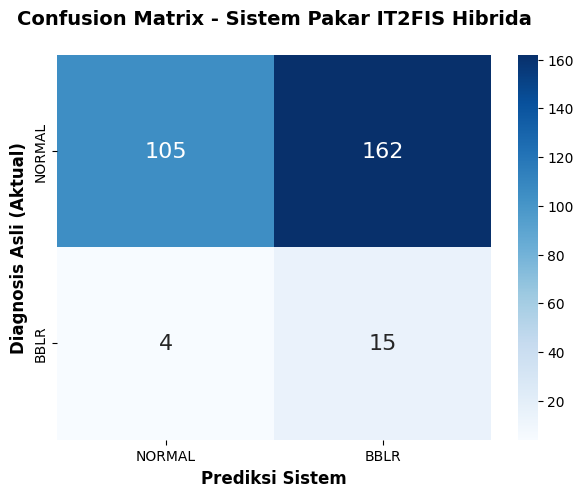

In [38]:
# ==============================================================================
# 7. HITUNG METRIK EVALUASI, CONFUSION MATRIX & VISUALISASI (OTOMATIS)
# ==============================================================================
jumlah_sesuai = len(df_hasil[df_hasil['Kesesuaian'] == 'Sesuai'])
jumlah_kontra = len(df_hasil[df_hasil['Kesesuaian'] == 'Kontradiktif'])
jumlah_ambigu = len(df_hasil[df_hasil['Kesesuaian'] == 'Tidak Dapat Ditentukan'])
jumlah_norule = len(df_hasil[df_hasil['Kesesuaian'] == 'Tidak Ada Rule Aktif'])
jumlah_error  = len(df_hasil[df_hasil['Kesesuaian'] == 'ERROR'])

total_data_valid = jumlah_sesuai + jumlah_kontra
total_data_semua = len(df_hasil)

# --- MENGHITUNG CONFUSION MATRIX (TP, TN, FP, FN) ---
TP = 0  # True Positive  : Asli BBLR, Sistem tebak BBLR (Benar)
TN = 0  # True Negative  : Asli Normal, Sistem tebak Normal (Benar)
FP = 0  # False Positive : Asli Normal, Sistem tebak BBLR (Alarm Palsu / Salah)
FN = 0  # False Negative : Asli BBLR, Sistem tebak Normal (Kecolongan / Fatal!)

for _, row in df_hasil.iterrows():
    if row['Kesesuaian'] in ['Sesuai', 'Kontradiktif']:
        # Bersihkan teks
        asli = str(row['Diagnosis_Asli']).strip().upper()
        if asli == 'RENDAH':
            asli = 'BBLR'
        sistem = str(row['Diagnosis_Sistem']).strip().upper()

        # Logika Matriks
        if asli == 'BBLR' and sistem == 'BBLR':
            TP += 1
        elif asli == 'NORMAL' and sistem == 'NORMAL':
            TN += 1
        elif asli == 'NORMAL' and sistem == 'BBLR':
            FP += 1
        elif asli == 'BBLR' and sistem == 'NORMAL':
            FN += 1

# ==============================================================================
# CETAK OUTPUT TEKS KE LAYAR
# ==============================================================================
print("\n=======================================================")
print("REKAPITULASI HASIL PENGUJIAN (EVALUASI OTOMATIS)")
print("=======================================================")
print(f"Total Data Pasien        : {total_data_semua}")
print(f"Sesuai (Benar)           : {jumlah_sesuai} data")
print(f"Kontradiktif (Salah)     : {jumlah_kontra} data")
print(f"Tidak Dapat Ditentukan   : {jumlah_ambigu} data")
print(f"Tidak Ada Rule Aktif     : {jumlah_norule} data")

if jumlah_error > 0:
    print(f"Error Eksekusi           : {jumlah_error} data")
print("-------------------------------------------------------")

# --- 1. RUMUS AKURASI EFEKTIF ---
if total_data_valid > 0:
    akurasi_efektif = (jumlah_sesuai / total_data_valid) * 100
    print("1. AKURASI EFEKTIF (Hanya menghitung data yang berhasil ditebak)")
    print(f"   > HASIL : {akurasi_efektif:.2f}%\n")
else:
    print("> AKURASI EFEKTIF : N/A\n")

# --- 2. RUMUS AKURASI KESELURUHAN (ABSOLUT) ---
if total_data_semua > 0:
    akurasi_absolut = (jumlah_sesuai / total_data_semua) * 100
    print("2. AKURASI KESELURUHAN (Menghitung seluruh total data)")
    print(f" > HASIL : {akurasi_absolut:.2f}%")
else:
    print("> AKURASI KESELURUHAN : N/A")

# ==============================================================================
# PERHITUNGAN METRIK EVALUASI LANJUTAN DARI CONFUSION MATRIX
# ==============================================================================
if total_data_valid > 0:
    # Mencegah error pembagian dengan nol (ZeroDivisionError)
    sensitivitas = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0
    spesifisitas = (TN / (TN + FP)) * 100 if (TN + FP) > 0 else 0.0
    presisi      = (TP / (TP + FP)) * 100 if (TP + FP) > 0 else 0.0

    # F1-Score menggunakan persentase
    if (presisi + sensitivitas) > 0:
        f1_score = 2 * (presisi * sensitivitas) / (presisi + sensitivitas)
    else:
        f1_score = 0.0

    print("\nANALISIS METRIK LANJUTAN (DARI CONFUSION MATRIX):")
    print(f"   * Accuracy     : {akurasi_efektif:.2f}% (Tingkat kebenaran keseluruhan)")
    print(f"   * Sensitivity  : {sensitivitas:.2f}% (Recall - Kemampuan mendeteksi BBLR)")
    print(f"   * Specificity  : {spesifisitas:.2f}% (Kemampuan mengenali ibu Normal)")
    print(f"   * Precision    : {presisi:.2f}% (Keakuratan alarm BBLR sistem)")
    print(f"   * F1-Score     : {f1_score:.2f}% (Keseimbangan Presisi & Recall)")

    print("\nKESIMPULAN MEDIS:")
    print(f"   - Terdapat {FP} Alarm Palsu (Ibu Normal divonis BBLR).")
    print(f"   - Terdapat {FN} Kasus Kecolongan (Ibu BBLR divonis Normal - FATAL).")

# ==============================================================================
# TAMPILKAN GAMBAR VISUALISASI CONFUSION MATRIX
# ==============================================================================
matrix_data = np.array([[TN, FP],
                        [FN, TP]])

plt.figure(figsize=(7, 5))
sns.heatmap(matrix_data, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'BBLR'],
            yticklabels=['NORMAL', 'BBLR'],
            annot_kws={"size": 16})

plt.title('Confusion Matrix - Sistem Pakar IT2FIS Hibrida\n', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Sistem', fontsize=12, fontweight='bold')
plt.ylabel('Diagnosis Asli (Aktual)', fontsize=12, fontweight='bold')

plt.show()

In [39]:
# Ringkas pola 18 kasus "Tidak Ada Rule Aktif"
import pandas as pd
import numpy as np

try:
    df = df_hasil.copy()
except NameError:
    df = pd.read_excel(r"d:\Skirpsi\AutoTestingLaporan_Hasil_Testing_SistemPakar_FINAL_LENGKAP.xlsx")

no_rule = df[df["Kesesuaian"] == "Tidak Ada Rule Aktif"].copy()
print("NO_RULE_COUNT:", len(no_rule))

def cat_lila(x): return "KEK" if x < 23.5 else "Normal"
def cat_hb(x): return "Anemia" if x < 11.0 else "Tidak Anemia"
def cat_imt(x):
    if x < 18.5: return "BB Kurang"
    if x < 25.0: return "BB Normal"
    if x < 30.0: return "BB Lebih"
    return "Obesitas"
def cat_usia(x):
    if x < 20: return "Berisiko Muda"
    if x < 35: return "Tidak Berisiko"
    return "Berisiko Tua"
def cat_jarak(x):
    if x < 24: return "Berisiko Dekat"
    if x <= 60: return "Tidak Berisiko"
    return "Berisiko Jauh"

no_rule["LILA_cat"] = no_rule["LiLA_cm"].apply(cat_lila)
no_rule["Hb_cat"] = no_rule["Hb_Rujukan"].apply(cat_hb)
no_rule["IMT_cat"] = no_rule["IMT_Riil"].apply(cat_imt)
no_rule["Usia_cat"] = no_rule["Usia_Ibu"].apply(cat_usia)
no_rule["Jarak_cat"] = no_rule["Jarak_Kehamilan_Bln"].apply(cat_jarak)

cols = ["Kunjungan_ANC","Kehamilan_Ke","LILA_cat","Hb_cat","IMT_cat","Usia_cat","Jarak_cat"]
print(no_rule[cols].value_counts().head(20))
print(no_rule[["LILA_cat","Hb_cat","Kunjungan_ANC"]].value_counts())
print(no_rule[["LILA_cat","Hb_cat","Kunjungan_ANC","Usia_cat"]].value_counts().head(20))

NO_RULE_COUNT: 0
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


## Tahap 5: Testing Akhir Pada 20 Data 

=== Memulai Pengujian Massal untuk 20 Data Pasien ===

Pengujian selesai! Laporan super lengkap telah diekspor ke:
'D:\Skirpsi\excel\Hasil_TestingFinal_20Data.xlsx'

REKAPITULASI HASIL PENGUJIAN (EVALUASI OTOMATIS)
Total Data Pasien        : 20
Sesuai (Benar)           : 17 data
Kontradiktif (Salah)     : 2 data
Tidak Dapat Ditentukan   : 1 data
Tidak Ada Rule Aktif     : 0 data
-------------------------------------------------------
1. AKURASI EFEKTIF (Hanya data yang berhasil ditebak)
   > HASIL : 89.47%

2. AKURASI KESELURUHAN (Seluruh total data)
   > HASIL : 85.00%

ANALISIS METRIK LANJUTAN (DARI CONFUSION MATRIX):
   * Accuracy     : 89.47%
   * Sensitivity  : 93.33% (Recall BBLR)
   * Specificity  : 75.00% (Recall Normal)
   * Precision    : 93.33%
   * F1-Score     : 93.33%
   * Mean Ign.    : 0.0000 (0.00%)   <--- [METRIK KETIDAKTAHUAN SISTEM]

KESIMPULAN MEDIS:
   - Terdapat 1 Alarm Palsu (Ibu Normal divonis BBLR).
   - Terdapat 1 Kasus Kecolongan (Ibu BBLR divonis Normal).
 

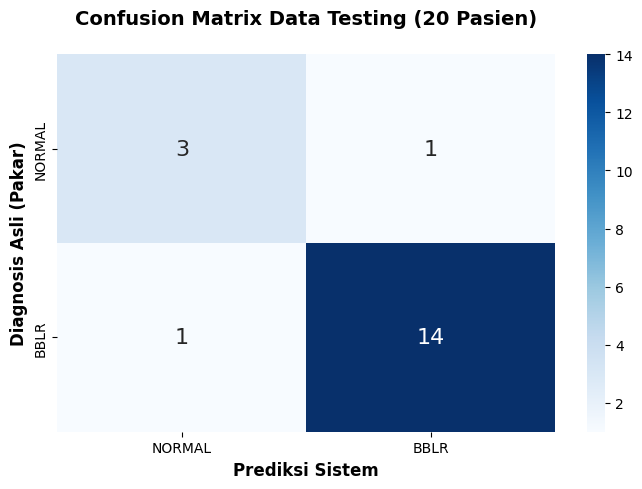

In [40]:
# ==============================================================================
# 1. BACA FILE DATA TESTING MENTAH (20 DATA PASIEN)
# ==============================================================================
file_path = 'D:\\Skirpsi\\dataset\\testingFinal\\13. Laporan_HasilAkhir_Testing_SistemPakar_20Data.xlsx' 
df_pasien = pd.read_excel(file_path) 

# ==============================================================================
# 2. INISIALISASI VARIABEL EVALUASI & PENYIMPANAN
# ==============================================================================
hasil_kolektif = []
jumlah_sesuai, jumlah_kontra, jumlah_ambigu, jumlah_norule, jumlah_error = 0, 0, 0, 0, 0
TP, TN, FP, FN = 0, 0, 0, 0

# [BARU] Variabel untuk menghitung total Ignorance
total_ignorance = 0.0 
valid_ds_count = 0 # Menghitung pasien yang berhasil diproses tanpa error sistem

total_data = len(df_pasien)

print(f"=== Memulai Pengujian Massal untuk {total_data} Data Pasien ===\n")

# ==============================================================================
# 3. PROSES TESTING (MEMANGGIL SISTEM PAKAR) & EVALUASI LANGSUNG
# ==============================================================================
for index, row in df_pasien.iterrows():
    # Menyiapkan input langsung dari kolom 20 dataset terbaru
    input_pasien = {
        'ibu_Usia Ibu'                : float(row['Usia_Ibu']),
        'ibu_Kehamilan Ke-'           : str(row['Kehamilan_Ke']).strip(),
        'jarak_kehamilan_bulan'       : float(row['Jarak_Kehamilan_Bln']),
        'kunjungan_anc_total'         : str(row['Kunjungan_ANC']).strip(),
        'ibu_statusImunisasi_encoded' : str(row['Status_Imunisasi']).strip(),
        'ibu_IMT'                     : float(row['IMT_Riil']),
        'LILA_angka'                  : float(row['LiLA_cm']),
        'ibu_Hb'                      : float(row['Hb_Rujukan']),
        'ibu_gulaDarah'               : float(row['GulaDarah_Rujukan']),
        'ibu_proteinUrin'             : str(row['Protein_Urin']).strip()
    }

    try:
        # --- MEMANGGIL FUNGSI ASLI SISTEM PAKAR ---
        hasil_fuzz      = fuzzifikasi_semua(input_pasien)
        hasil_inferensi = inferensi_it2(hasil_fuzz)
        hasil_ds        = dempster_shafer(hasil_inferensi)

        # --- EKSTRAKSI OUTPUT SISTEM ---
        diagnosis_sistem = ""
        belief_bblr, belief_normal = 0.0, 0.0

        if isinstance(hasil_ds, dict):
            if 'keputusan' in hasil_ds:
                diagnosis_sistem = hasil_ds['keputusan'].get('diagnosis', '')
                belief_bblr      = hasil_ds['keputusan'].get('bel_bblr', 0.0)
                belief_normal    = hasil_ds['keputusan'].get('bel_normal', 0.0)
            elif 'error' in hasil_ds and 'aktif' in str(hasil_ds['error']):
                diagnosis_sistem = "Tidak Ada Rule Aktif"
            
            if 'Ignorance' in str(diagnosis_sistem) or 'Tidak Dapat Ditentukan' in str(diagnosis_sistem):
                diagnosis_sistem = "Tidak Dapat Ditentukan"

        # [BARU] Menghitung Ignorance per Pasien
        # Adaptasi jika nilai belief Anda berupa persentase (0-100) atau desimal (0-1)
        if belief_bblr > 1.0 or belief_normal > 1.0:
            ignorance_pasien = max(0.0, 100.0 - (belief_bblr + belief_normal)) / 100.0
        else:
            ignorance_pasien = max(0.0, 1.0 - (belief_bblr + belief_normal))
        
        total_ignorance += ignorance_pasien
        valid_ds_count += 1

        # --- LOGIKA KESESUAIAN & CONFUSION MATRIX ---
        asli = str(row['Diagnosis_Pakar']).strip().upper()
        if asli == "RENDAH": asli = "BBLR"
        sistem = diagnosis_sistem.strip().upper()

        if "TIDAK ADA" in sistem:
            jumlah_norule += 1
            kesesuaian = "Tidak Ada Rule Aktif"
        elif "AMBIGU" in sistem or "TIDAK DAPAT DITENTUKAN" in sistem or "FORMAT UNIK" in sistem:
            jumlah_ambigu += 1
            kesesuaian = "Tidak Dapat Ditentukan"
        elif sistem == asli:
            jumlah_sesuai += 1
            kesesuaian = "Sesuai"
            if asli == 'BBLR': TP += 1
            elif asli == 'NORMAL': TN += 1
        else:
            jumlah_kontra += 1
            kesesuaian = "Kontradiktif"
            if asli == 'NORMAL' and sistem == 'BBLR': FP += 1
            elif asli == 'BBLR' and sistem == 'NORMAL': FN += 1

        # --- MENYIMPAN HASIL UNTUK EXPORT EXCEL ---
        hasil_kolektif.append({
            'ID_Pasien'          : row.get('ID_Pasien', index + 1),
            'Usia_Ibu'           : input_pasien['ibu_Usia Ibu'],
            'Kehamilan_Ke'       : input_pasien['ibu_Kehamilan Ke-'],
            'Jarak_Kehamilan_Bln': input_pasien['jarak_kehamilan_bulan'],
            'Kunjungan_ANC'      : input_pasien['kunjungan_anc_total'],
            'Status_Imunisasi'   : input_pasien['ibu_statusImunisasi_encoded'],
            'IMT_Riil'           : input_pasien['ibu_IMT'],
            'LiLA_cm'            : input_pasien['LILA_angka'],
            'Hb_Rujukan'         : input_pasien['ibu_Hb'],
            'GulaDarah_Rujukan'  : input_pasien['ibu_gulaDarah'],
            'Protein_Urin'       : input_pasien['ibu_proteinUrin'],
            'Diagnosis_Sistem'   : diagnosis_sistem,
            'Diagnosis_Pakar'    : row['Diagnosis_Pakar'],
            'Kesesuaian'         : kesesuaian,
            'Belief_BBLR'        : belief_bblr,
            'Belief_Normal'      : belief_normal,
            'Ignorance'          : ignorance_pasien, # [BARU] Simpan ke Excel
            'Status'             : 'Sukses'
        })

    except Exception as e:
        jumlah_error += 1
        hasil_kolektif.append({
            'ID_Pasien'          : row.get('ID_Pasien', index + 1),
            'Diagnosis_Sistem'   : 'ERROR',
            'Diagnosis_Pakar'    : row.get('Diagnosis_Pakar', ''),
            'Kesesuaian'         : 'ERROR',
            'Status'             : f"Gagal Eksekusi: {str(e)}"
        })

# ==============================================================================
# 4. EKSPOR HASIL LENGKAP KE EXCEL
# ==============================================================================
df_hasil = pd.DataFrame(hasil_kolektif)
output_file = 'D:\\Skirpsi\\excel\\Hasil_TestingFinal_20Data.xlsx'
df_hasil.to_excel(output_file, index=False, engine='openpyxl')

print(f"Pengujian selesai! Laporan super lengkap telah diekspor ke:\n'{output_file}'\n")

# ==============================================================================
# 5. CETAK REKAPITULASI & METRIK EVALUASI
# ==============================================================================
total_data_valid = jumlah_sesuai + jumlah_kontra

print("=======================================================")
print("REKAPITULASI HASIL PENGUJIAN (EVALUASI OTOMATIS)")
print("=======================================================")
print(f"Total Data Pasien        : {total_data}")
print(f"Sesuai (Benar)           : {jumlah_sesuai} data")
print(f"Kontradiktif (Salah)     : {jumlah_kontra} data")
print(f"Tidak Dapat Ditentukan   : {jumlah_ambigu} data")
print(f"Tidak Ada Rule Aktif     : {jumlah_norule} data")
if jumlah_error > 0: print(f"Error Eksekusi           : {jumlah_error} data")
print("-------------------------------------------------------")

if total_data_valid > 0:
    akurasi_efektif = (jumlah_sesuai / total_data_valid) * 100
    akurasi_absolut = (jumlah_sesuai / total_data) * 100
    sensitivitas    = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0
    spesifisitas    = (TN / (TN + FP)) * 100 if (TN + FP) > 0 else 0.0
    presisi         = (TP / (TP + FP)) * 100 if (TP + FP) > 0 else 0.0
    f1_score        = 2 * (presisi * sensitivitas) / (presisi + sensitivitas) if (presisi + sensitivitas) > 0 else 0.0
    
    # Hitung Mean Ignorance
    mean_ign = (total_ignorance / valid_ds_count) if valid_ds_count > 0 else 0.0

    print("1. AKURASI EFEKTIF (Hanya data yang berhasil ditebak)")
    print(f"   > HASIL : {akurasi_efektif:.2f}%\n")
    print("2. AKURASI KESELURUHAN (Seluruh total data)")
    print(f"   > HASIL : {akurasi_absolut:.2f}%\n")
    
    print("ANALISIS METRIK LANJUTAN (DARI CONFUSION MATRIX):")
    print(f"   * Accuracy     : {akurasi_efektif:.2f}%")
    print(f"   * Sensitivity  : {sensitivitas:.2f}% (Recall BBLR)")
    print(f"   * Specificity  : {spesifisitas:.2f}% (Recall Normal)")
    print(f"   * Precision    : {presisi:.2f}%")
    print(f"   * F1-Score     : {f1_score:.2f}%")
    print(f"   * Mean Ign.    : {mean_ign:.4f} ({mean_ign*100:.2f}%)   <--- [METRIK KETIDAKTAHUAN SISTEM]") # [BARU]
    
    print("\nKESIMPULAN MEDIS:")
    print(f"   - Terdapat {FP} Alarm Palsu (Ibu Normal divonis BBLR).")
    print(f"   - Terdapat {FN} Kasus Kecolongan (Ibu BBLR divonis Normal).")
    print(f"   - Sistem menekan rata-rata ketidaktahuan (Mean Ignorance) pada angka {mean_ign*100:.2f}%.") # [BARU]
else:
    print("Sistem gagal menebak data valid.")

# ==============================================================================
# 6. TAMPILKAN GAMBAR VISUALISASI CONFUSION MATRIX
# ==============================================================================
matrix_data = np.array([[TN, FP],
                        [FN, TP]])

plt.figure(figsize=(7, 5))
sns.heatmap(matrix_data, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'BBLR'],
            yticklabels=['NORMAL', 'BBLR'],
            annot_kws={"size": 16})

plt.title('Confusion Matrix Data Testing (20 Pasien)\n', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Sistem', fontsize=12, fontweight='bold')
plt.ylabel('Diagnosis Asli (Pakar)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()